<a href="https://colab.research.google.com/github/lia-lubit/DESIxSO/blob/main/forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print('Comment notation:')
print('#: description of what is being done')
print('##: question')
print('###: problem')
print('####: task')

print("colab link: https://colab.research.google.com/github/lia-lubit/DESIxSO/blob/main/forecasting.ipynb")

Comment notation:
#: description of what is being done
##: question
###: problem
####: task
colab link: https://colab.research.google.com/github/lia-lubit/DESIxSO/blob/main/forecasting.ipynb


In [2]:
# import tools

# standard library
import os
import types
import sys
import inspect
import yaml
import time
import ipyparallel as ipp

# scientific stack
import numpy as np
import jax.numpy as jnp
import scipy
from scipy.interpolate import interp1d
from scipy.stats import linregress
from scipy.integrate import simpson
from scipy.ndimage import gaussian_filter1d

# cosmology
import astropy
import astropy.units as units
from astropy.cosmology import LambdaCDM, w0waCDM
import pyccl as ccl
import camb
from camb import model, initialpower
import classy
from cosmopower_jax.cosmopower_jax import CosmoPowerJAX as CPJ

# plotting
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LogNorm
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# inference / sampling
import cobaya
from cobaya.run import run as cobaya_run
from cobaya.likelihood import Likelihood
from cobaya.model import get_model
#from cobaya_utilities import tools -- this wont import, but I don't use it at the momment anyway
import getdist
import getdist.plots as plots
from getdist import plots, MCSamples
from getdist.mcsamples import MCSamples
from getdist.mcsamples import loadMCSamples

# notebook only (remove if this becomes a .py module)
%matplotlib inline

In [3]:
# import custom helper functions and classes

# functions
from functions_and_classes import calculate_and_plot_Cls
from functions_and_classes import build_tracers_from_data
from functions_and_classes import build_tracer_dict
from functions_and_classes import build_noise_dict
from functions_and_classes import build_spectra_dict
from functions_and_classes import create_simplified_desired_pairs
from functions_and_classes import build_covariance_from_data
from functions_and_classes import plot_covariance_matrix
from functions_and_classes import plot_correlation_matrix
from functions_and_classes import plot_spectra_from_dict
from functions_and_classes import make_Pk2D
from functions_and_classes import predict_linear_Pk
from functions_and_classes import predict_boost_Pk
from functions_and_classes import instrument_Pk2D

# classes
from functions_and_classes import ForecastMap
from functions_and_classes import CovarianceMatrix
from functions_and_classes import SO_x_DESI_Likelihood_A_s_version
from functions_and_classes import SO_x_DESI_Likelihood_w_emulator
from functions_and_classes import SO_x_DESI_Likelihood_sigma8_version
from functions_and_classes import SO_x_DESI_Likelihood_w_emulator_and_JAX
from functions_and_classes import Pk2DTimer

LOADING FILE: /global/u2/l/lialubit/DESIxSO/functions_and_classes.py


In [4]:
#import pre-trained P(k) emulators stored in emulator file

lin_emu = CPJ(probe='mpk_lin')
boost_emu = CPJ(probe='mpk_boost')

print('linear P(k) emulator parameters: ', lin_emu.parameters)
print('boost P(k) emulator parameters: ', boost_emu.parameters)

linear P(k) emulator parameters:  ['omega_b', 'omega_cdm', 'h', 'n_s', 'ln10^{10}A_s', 'z']
boost P(k) emulator parameters:  ['omega_b', 'omega_cdm', 'h', 'n_s', 'ln10^{10}A_s', 'cmin', 'eta_0', 'z']


In [5]:
# data

# DESI-HSC
HSC_dist_0_3 = np.load("data/distributions_0.3_3_vF.npz")
print(f"Keys in distributions_0.3_3_vF.npz: {HSC_dist_0_3.files}")

HSC_dist_1_5 = np.load("data/distributions_1_5_vF.npz")
print(f"Keys in distributions_1_5_vF.npz: {HSC_dist_1_5.files}")

HSC_dist_0_3_a = np.load("data/distributions_0.3_3_vF.npz")['1/nz_mean']
HSC_dist_0_3_b = np.load("data/distributions_0.3_3_vF.npz")['2/nz_mean']
HSC_dist_0_3_c = np.load("data/distributions_0.3_3_vF.npz")['3/nz_mean']
HSC_dist_0_3_d = np.load("data/distributions_0.3_3_vF.npz")['4/nz_mean']
HSC_dist_0_3_z = np.load("data/distributions_0.3_3_vF.npz")['z']
HSC_dist_0_3 = np.column_stack((HSC_dist_0_3_z, HSC_dist_0_3_a, HSC_dist_0_3_b, HSC_dist_0_3_c, HSC_dist_0_3_d)) # make into 2D array for easy processing

HSC_dist_1_5_a = np.load("data/distributions_1_5_vF.npz")['1/nz_mean']
HSC_dist_1_5_b = np.load("data/distributions_1_5_vF.npz")['2/nz_mean']
HSC_dist_1_5_c = np.load("data/distributions_1_5_vF.npz")['3/nz_mean']
HSC_dist_1_5_d = np.load("data/distributions_1_5_vF.npz")['4/nz_mean']
HSC_dist_1_5_z = np.load("data/distributions_1_5_vF.npz")['z']
HSC_dist_1_5 = np.column_stack((HSC_dist_1_5_z, HSC_dist_1_5_a, HSC_dist_1_5_b, HSC_dist_1_5_c, HSC_dist_1_5_d)) # make into 2D array for easy processing

# DESI Lens Data

DESI_lens_data = np.loadtxt("data/des_nz_gamma.txt")

DESI_lens_data = DESI_lens_data[7:]  # removes the first 7 values (headers)
DESI_lens_data = DESI_lens_data.reshape(-1, 6) #shape into array with columns z, nz0 -- nz4

# Split into separate arrays
DESI_lens_z    = DESI_lens_data[:, 0]
DESI_lens_nz_a = DESI_lens_data[:, 1]
DESI_lens_nz_b = DESI_lens_data[:, 2]
DESI_lens_nz_c = DESI_lens_data[:, 3]
DESI_lens_nz_d = DESI_lens_data[:, 4]
DESI_lens_nz_e = DESI_lens_data[:, 5]

DESI_lens_data = np.column_stack((DESI_lens_z, DESI_lens_nz_a, DESI_lens_nz_b, DESI_lens_nz_c, DESI_lens_nz_d))

Keys in distributions_0.3_3_vF.npz: ['z', '1/nz_median', '1/nz_mean', '1/nz_lower', '1/nz_upper', '1/nz_median_mu', '1/nz_mean_mu', '1/nz_lower_mu', '1/nz_upper_mu', '2/nz_median', '2/nz_mean', '2/nz_lower', '2/nz_upper', '2/nz_median_mu', '2/nz_mean_mu', '2/nz_lower_mu', '2/nz_upper_mu', '3/nz_median', '3/nz_mean', '3/nz_lower', '3/nz_upper', '3/nz_median_mu', '3/nz_mean_mu', '3/nz_lower_mu', '3/nz_upper_mu', '4/nz_median', '4/nz_mean', '4/nz_lower', '4/nz_upper', '4/nz_median_mu', '4/nz_mean_mu', '4/nz_lower_mu', '4/nz_upper_mu']
Keys in distributions_1_5_vF.npz: ['z', '1/nz_median', '1/nz_mean', '1/nz_lower', '1/nz_upper', '1/nz_median_mu', '1/nz_mean_mu', '1/nz_lower_mu', '1/nz_upper_mu', '2/nz_median', '2/nz_mean', '2/nz_lower', '2/nz_upper', '2/nz_median_mu', '2/nz_mean_mu', '2/nz_lower_mu', '2/nz_upper_mu', '3/nz_median', '3/nz_mean', '3/nz_lower', '3/nz_upper', '3/nz_median_mu', '3/nz_mean_mu', '3/nz_lower_mu', '3/nz_upper_mu', '4/nz_median', '4/nz_mean', '4/nz_lower', '4/nz_up

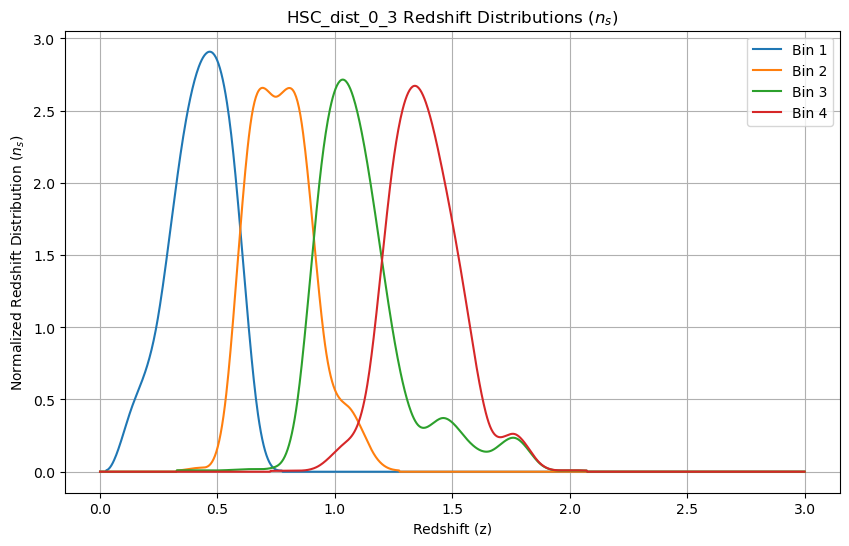

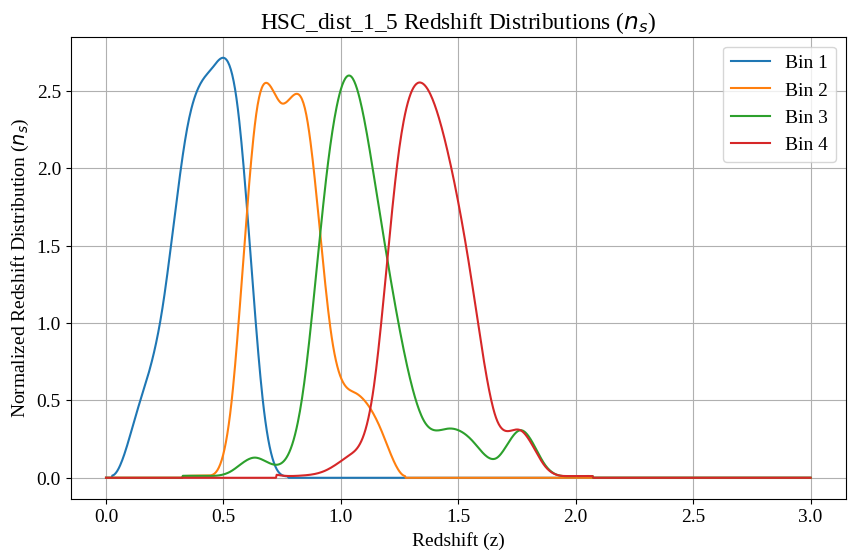

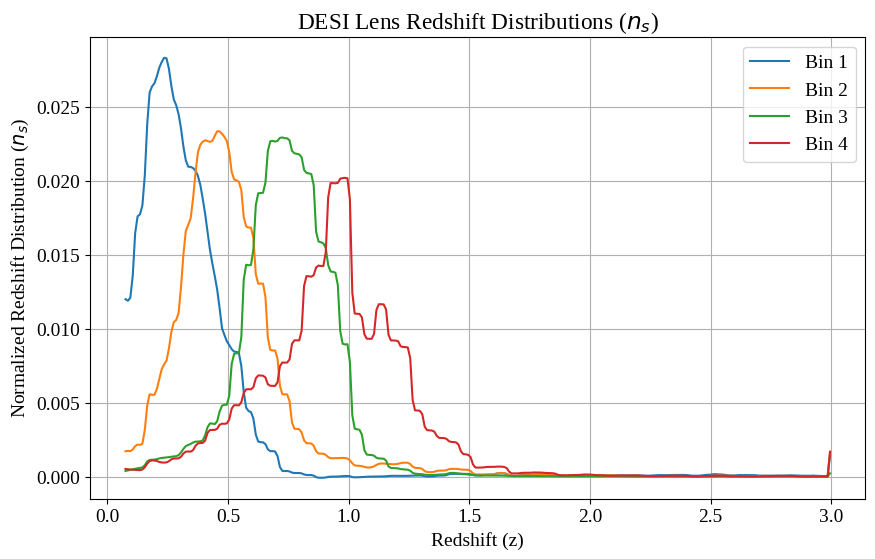

In [6]:
# graph HSC source distributions

plt.figure(figsize=(10, 6))
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_a, label='Bin 1')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_b, label='Bin 2')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_c, label='Bin 3')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_d, label='Bin 4')
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('HSC_dist_0_3 Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_a, label='Bin 1')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_b, label='Bin 2')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_c, label='Bin 3')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_d, label='Bin 4')
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('HSC_dist_1_5 Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(DESI_lens_z, DESI_lens_nz_a, label='Bin 1')
plt.plot(DESI_lens_z, DESI_lens_nz_b, label='Bin 2')
plt.plot(DESI_lens_z, DESI_lens_nz_c, label='Bin 3')
plt.plot(DESI_lens_z, DESI_lens_nz_d, label='Bin 4')
#plt.plot(DESI_lens_z, DESI_lens_nz_e, label='Bin 5')
#### nz_5 has values all of order e7 or above,
#### while the others have values of order e-5 or below
#### what's going on here?
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('DESI Lens Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14
plt.show()

Mean redshifts for DESI lens bins:
  Lens Bin 1: 0.343
  Lens Bin 2: 0.522
  Lens Bin 3: 0.742
  Lens Bin 4: 0.936


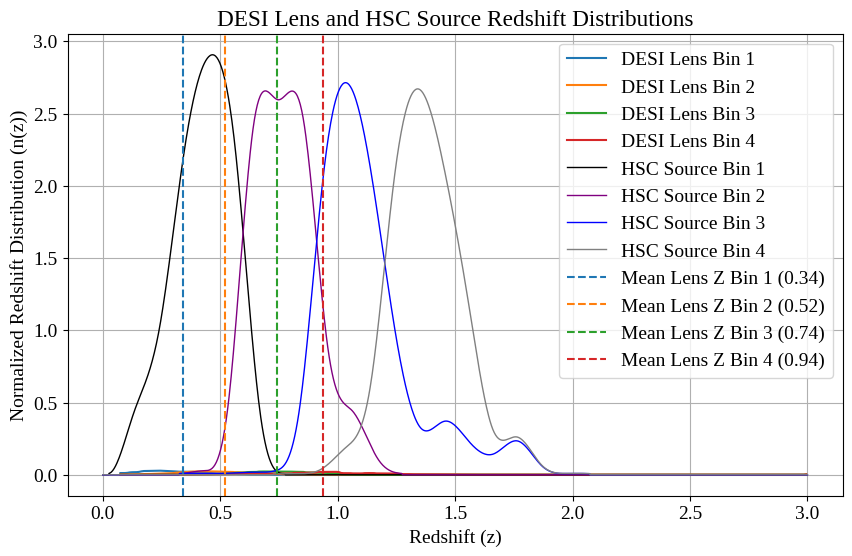

In [7]:
# calculate mean lens redshifts for each DESI lens bin
mean_desi_lens_redshifts = []

# DESI_lens_data contains z in col 0, then nz_a, nz_b, nz_c, nz_d in cols 1-4
nz_arrays_desi = [DESI_lens_nz_a, DESI_lens_nz_b, DESI_lens_nz_c, DESI_lens_nz_d]
z_lens_grid = DESI_lens_data[:, 0]

for i, n_lens_i in enumerate(nz_arrays_desi):
    if np.sum(n_lens_i) == 0:
        mean_desi_lens_redshifts.append(np.nan)
    else:
        z_l_i = scipy.integrate.trapezoid(z_lens_grid * n_lens_i, z_lens_grid) / scipy.integrate.trapezoid(n_lens_i, z_lens_grid)
        mean_desi_lens_redshifts.append(z_l_i)

print("Mean redshifts for DESI lens bins:")
for i, z_l_i in enumerate(mean_desi_lens_redshifts):
    print(f"  Lens Bin {i+1}: {z_l_i:.3f}")

# plot DESI lens distributions and the first HSC_dist_0_3 source distribution
plt.figure(figsize=(10, 6))
plt.plot(DESI_lens_z, DESI_lens_nz_a, label='DESI Lens Bin 1')
plt.plot(DESI_lens_z, DESI_lens_nz_b, label='DESI Lens Bin 2')
plt.plot(DESI_lens_z, DESI_lens_nz_c, label='DESI Lens Bin 3')
plt.plot(DESI_lens_z, DESI_lens_nz_d, label='DESI Lens Bin 4')

plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_a, label='HSC Source Bin 1', linestyle='-', linewidth=1, color='black')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_b, label='HSC Source Bin 2', linestyle='-', linewidth=1, color='purple')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_c, label='HSC Source Bin 3', linestyle='-', linewidth=1, color='blue')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_d, label='HSC Source Bin 4', linestyle='-', linewidth=1, color='gray')

# Add vertical lines for mean lens redshifts
for i, z_l_i in enumerate(mean_desi_lens_redshifts):
    plt.axvline(x=z_l_i, color=f'C{i}', linestyle='--', label=f'Mean Lens Z Bin {i+1} ({z_l_i:.2f})')

plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution (n(z))')
plt.title('DESI Lens and HSC Source Redshift Distributions')
plt.legend()
plt.grid(True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14
plt.show()

In [8]:
# CCL
print('CCL cosmology parameters:')
print('Omega_c: the density fraction at z=0 of CDM.')
print('Omega_b: the density fraction at z=0 of baryons.')
print('h: the Hubble constant in units of 100 k⁢m/s/M⁢p⁢c.')
print('Omega_k: the curvature density fraction at 𝑧 =0.')
print('Omega_g: the density of radiation (not including massless neutrinos.')
print('w0: first order term of the dark energy equation of state.')
print('wa: second order term of the dark energy equation of state.')

CCL cosmology parameters:
Omega_c: the density fraction at z=0 of CDM.
Omega_b: the density fraction at z=0 of baryons.
h: the Hubble constant in units of 100 k⁢m/s/M⁢p⁢c.
Omega_k: the curvature density fraction at 𝑧 =0.
Omega_g: the density of radiation (not including massless neutrinos.
w0: first order term of the dark energy equation of state.
wa: second order term of the dark energy equation of state.


In [9]:
# CCL cosmolgoies

# сosmology -- standard CCL + DESI waw0
h = 0.6674
w0 = -0.752
wa = -0.86
Om0 = 0.3191
Omega_c = 0.27
Omega_b = 0.045
sigma8 = 0.8
A_s = 2.105e-9
n_s = 0.96
w0wa_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s=A_s,
                               n_s=n_s, w0=w0, wa=wa, transfer_function='boltzmann_camb')

# сosmology -- standard CCL + DESI curved h and Omega_k
h = 0.6850
Om0 = 0.3191
Omega_c = 0.27
Omega_b = 0.045
sigma8 = 0.8
A_s = 2.105e-9
n_s = 0.96
Omega_k = 2.3e-3
curved_LCDM_cosmology = ccl.Cosmology(Omega_k = Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s=A_s,
                               n_s=n_s, transfer_function='boltzmann_camb')

# cosmology -- standard CCL + flat LCDM
z_star = 1100.0
Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
Omega_k = 0
Omega_b = 0.045
n_s=0.96
A_s = 2.105e-9
Omega_c = 0.27
flat_LCDM_cosmology = ccl.Cosmology(Omega_k = Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s = A_s,
                               n_s=n_s, transfer_function='boltzmann_camb')

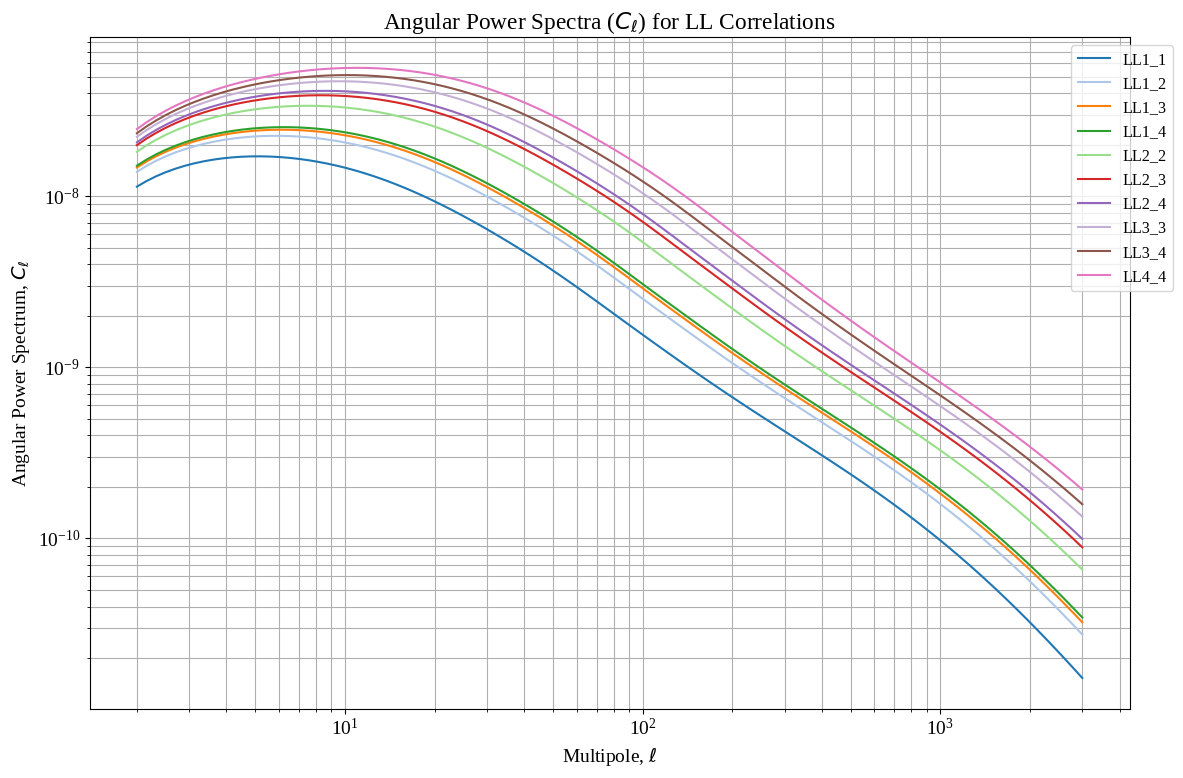

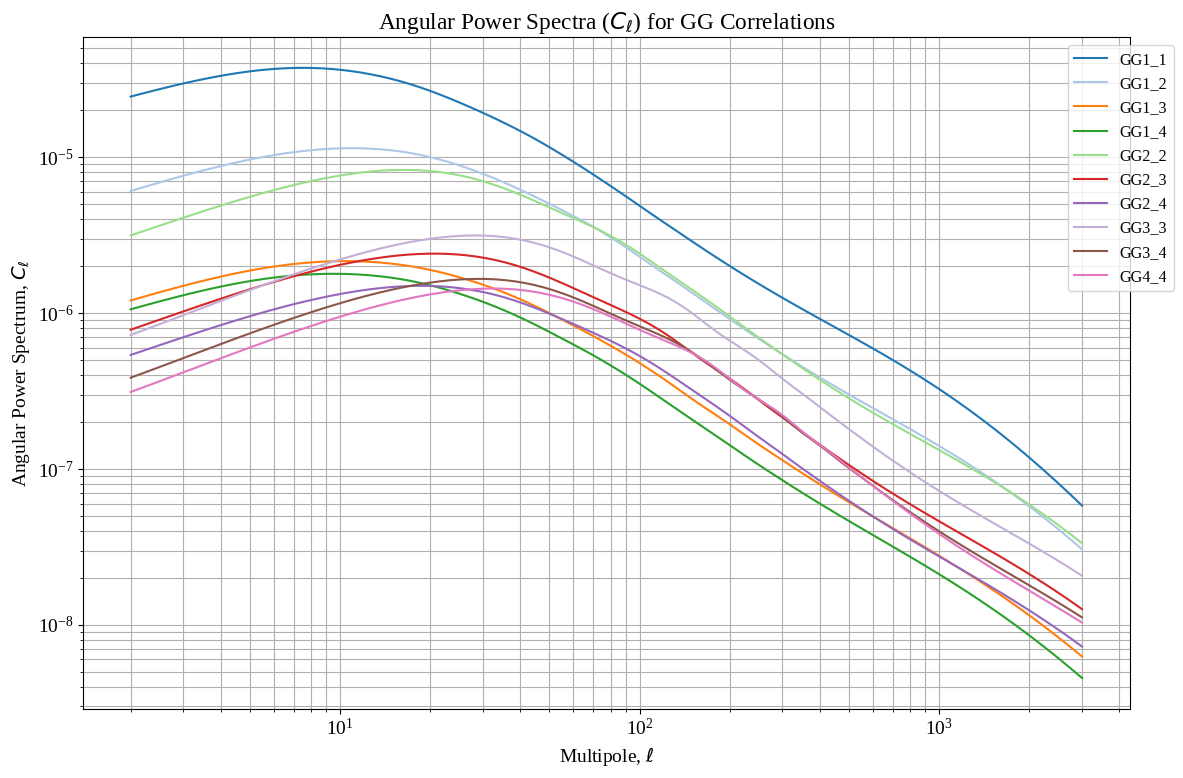

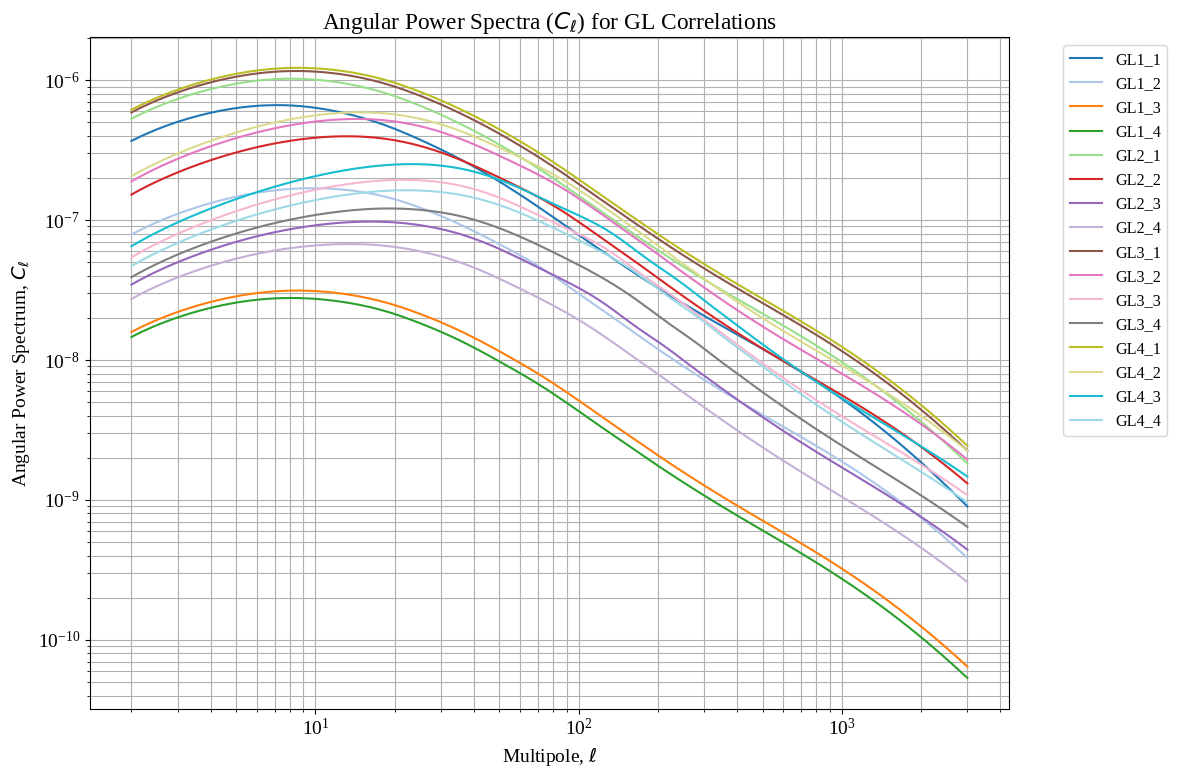

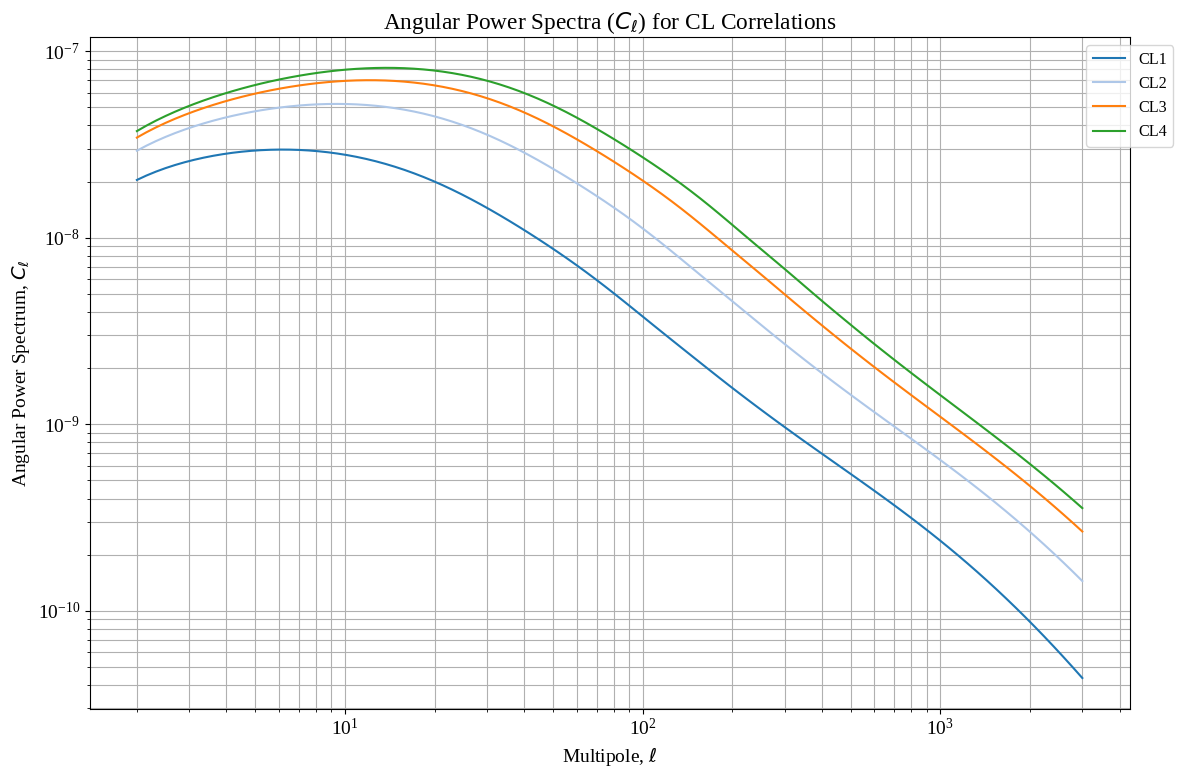

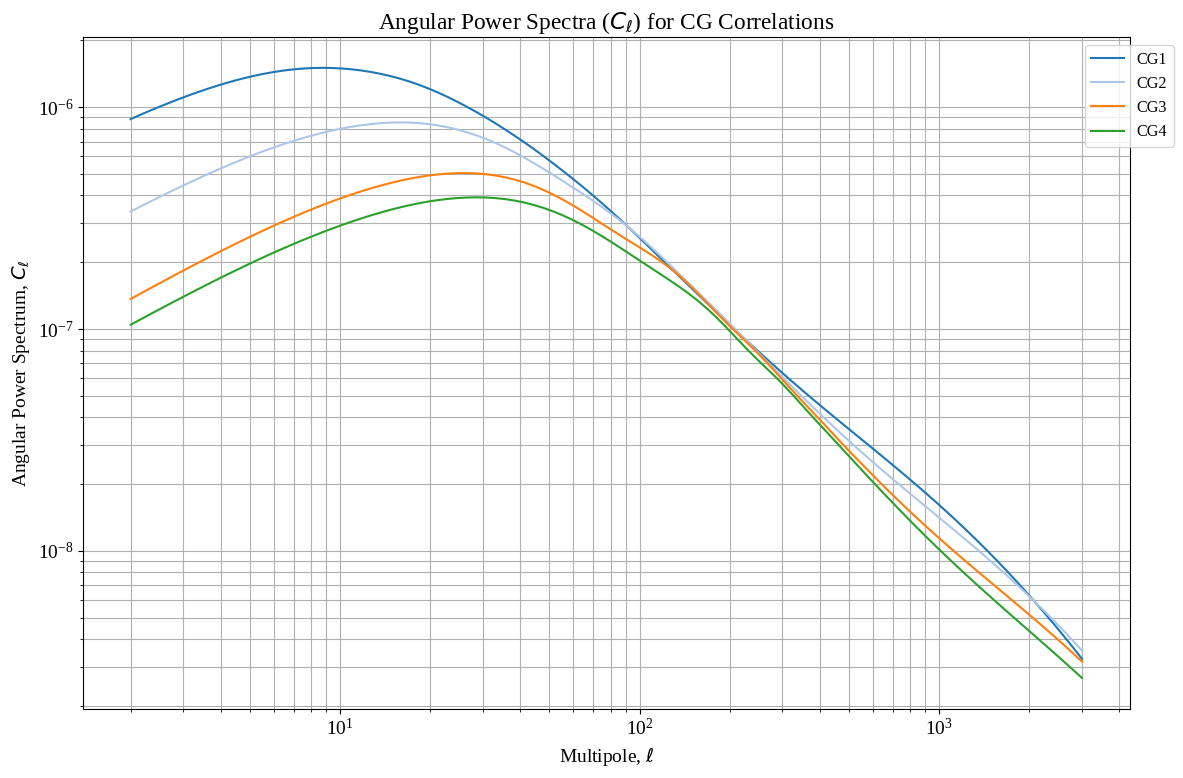

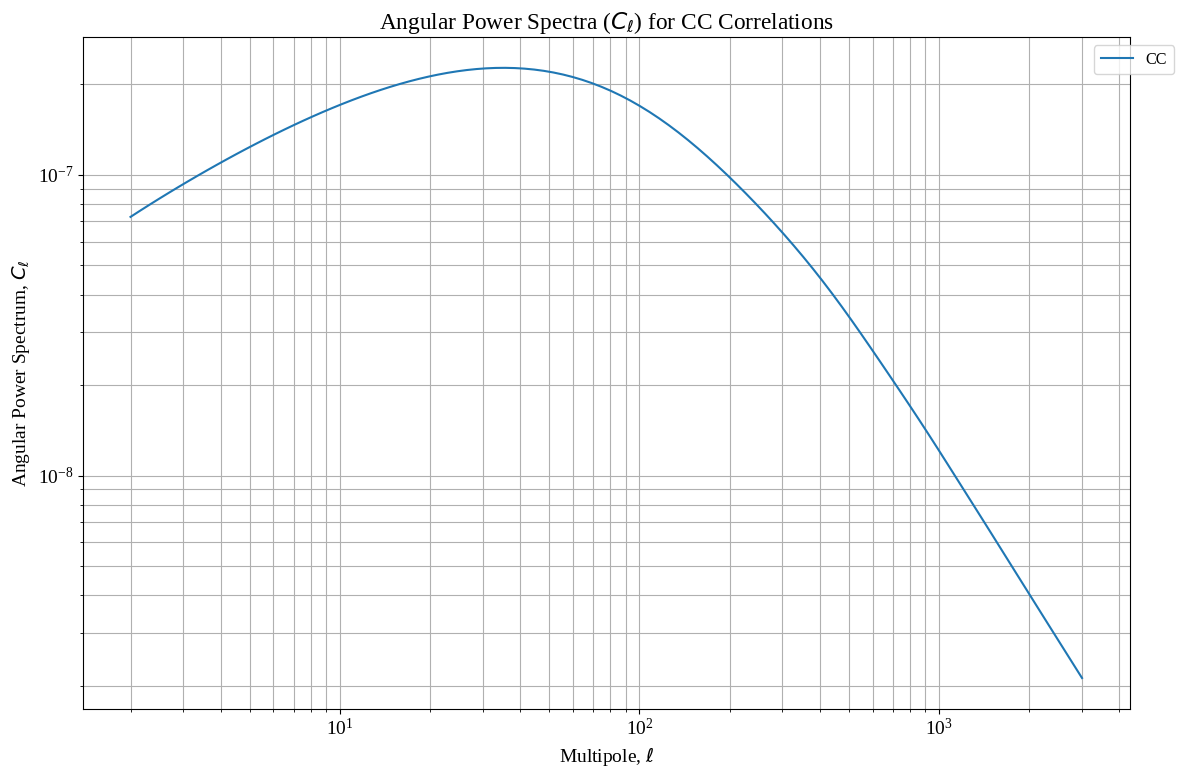

In [17]:
# plot angular power spectra

calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['LL'])

calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['GG'])

calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['GL'])

calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CL'])

calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CG'])

calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CC'])

### CosmoPower Emulator

**CosmoPower** is a suite of neural network emulators that can predict power spectra and other parameters. In MCMC, a lot of the computation time is spent calculating power spectra for each proposed set of cosmological parameters. Cosmopower can speed this up.

We'll do some experimenting with CosmoPower and then integrate it with the MCMC.

What we need to do is:
1. Before running the MCMC, train the network on a dataset of power spectra computed using a full Boltzmann solver across a wide range of cosmological parameters, or find a pre-trained model and extrapolate from it to get the spectra we want.
2. Integrate the CosmoPower network into the Cobaya likelihood. That way, during the sampling, instead of recalculating the power spectru at each step, the pre-trained CosmoPower network will rapidly predict the power spectra. This will allow the sampler to explore much more quickly.

We'll need:
1.  **`cosmopower`**: The core library containing the trained emulators.
2.  **`cobaya-cosmopower`**: A Cobaya-specific wrapper that integrates the `cosmopower_cl` likelihood into your Cobaya runs. We'll specify a path to a pre-trained CosmoPower model (`.npz` file) for the desired power spectra (e.g., `cl_TT`, `cl_EE`, `cl_TE`, `cl_phi_phi`). This will repalce our current call to pyccl.

Notes:
1. The emulator has a k-grid but NOT a z-grid. You can dynaically set the z values and run the emulator. Our C_l's are all integrals over the line of sight (over lots of different z's) so we'll need to consider the P(k) at all the z's from here to the start of time. We'll need to figure out if that z range is suitable for all the calculations -- I need to get more into the details of the integrals of C_l's again for the different types of C_l. 
2. The standard CosmoPower uses TensorFlow which is incompatible with other packages we need. Use CosmoPower-Jax instead. (Trust me on this, don't try to make the normal CosmoPower work...)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


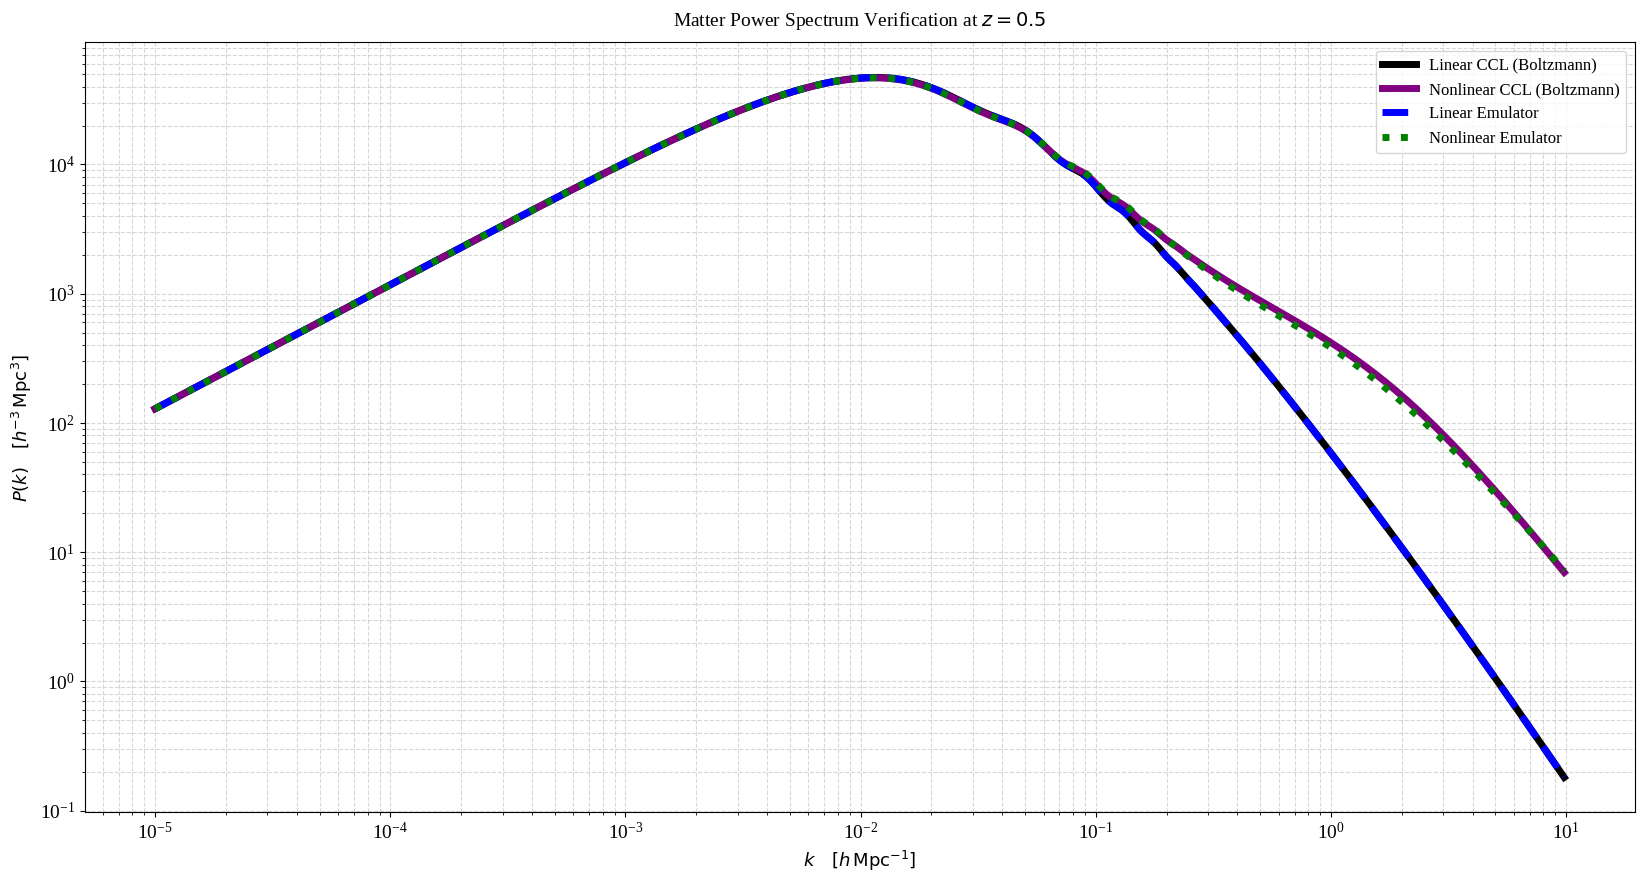

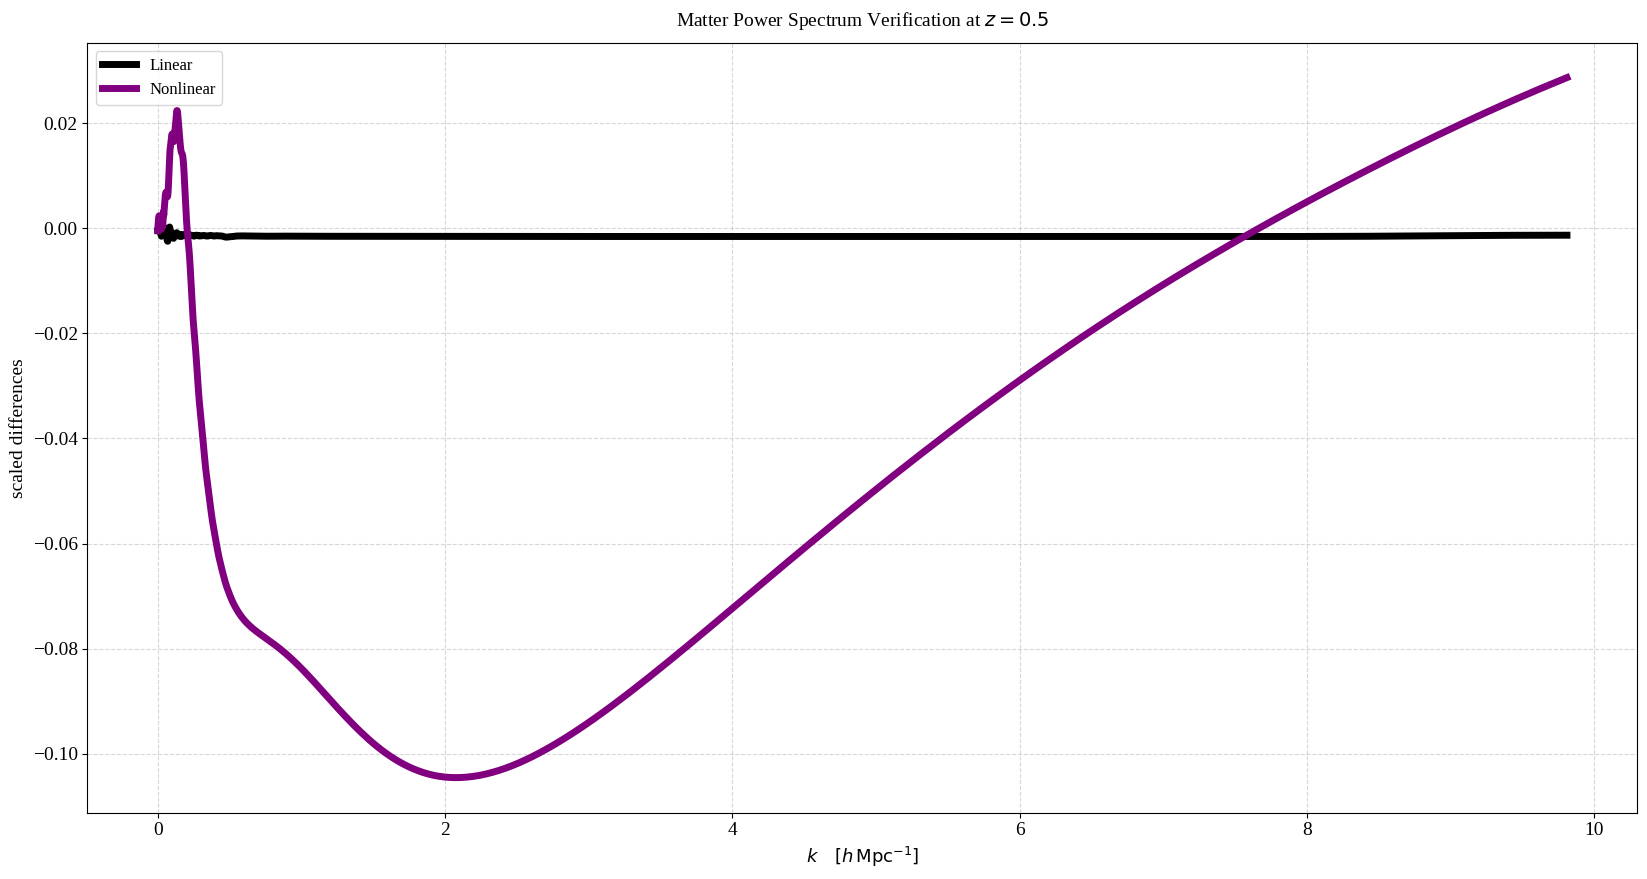

In [8]:
# test new emulator functions for a simple linear power spectrum

# cosmology -- standard CCL + flat LCDM w/A_s
z_star = 1100.0
Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
Omega_k = 0
Omega_b = 0.045
Omega_c = 0.27
A_s = 2.1 * 1e-9
n_s=0.96
flat_LCDM_cosmology2 = ccl.Cosmology(Omega_k = Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s=A_s,
                               n_s=n_s, transfer_function='boltzmann_camb')

k_modes = lin_emu.modes

# PyCCL
a = 1.0 / (1.0 + 0.5)
linear_spectrum_ccl = ccl.linear_matter_power(flat_LCDM_cosmology2, k_modes, a)
non_linear_spectrum_ccl = ccl.nonlin_matter_power(flat_LCDM_cosmology2, k_modes, a)

# emulator
linear_Pk = predict_linear_Pk(flat_LCDM_cosmology2, lin_emu, 0.5)
z_grid = np.linspace(0, 10, 50)
Pk2D_full = make_Pk2D(flat_LCDM_cosmology2, linear_emulator = lin_emu, boost_emulator = boost_emu, z_arr = z_grid, cmin=3.13, eta_0=0.68)
non_linear_Pk = Pk2D_full(k=k_modes, a=a)

# plot
fig = plt.figure(figsize=(20, 10))
plt.loglog(k_modes, linear_spectrum_ccl, color='black', linewidth=5, label='Linear CCL (Boltzmann)')
plt.loglog(k_modes, non_linear_spectrum_ccl, color='purple', linewidth=5, label='Nonlinear CCL (Boltzmann)')
plt.loglog(k_modes, linear_Pk, color='blue', linewidth=5, linestyle='--', label='Linear Emulator')
plt.loglog(k_modes, non_linear_Pk, color='green', linewidth=5, linestyle=':', label=r'Nonlinear Emulator')
plt.xlabel(r'$k \quad [h \, \mathrm{Mpc}^{-1}]$', fontsize=13)
plt.ylabel(r'$P(k) \quad [h^{-3} \, \mathrm{Mpc}^3]$', fontsize=13)
plt.title(f'Matter Power Spectrum Verification at $z = {0.5}$', fontsize=14, pad=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.show()

# scaled differences
fig = plt.figure(figsize=(20, 10))
linear_diff = (linear_Pk - linear_spectrum_ccl) / (linear_spectrum_ccl)
non_linear_diff = (non_linear_Pk - non_linear_spectrum_ccl) / (non_linear_spectrum_ccl)
plt.plot(k_modes, linear_diff, color='black', linewidth=5, label='Linear')
plt.plot(k_modes, non_linear_diff, color='purple', linewidth=5, label='Nonlinear')
plt.xlabel(r'$k \quad [h \, \mathrm{Mpc}^{-1}]$', fontsize=13)
plt.ylabel('scaled differences')
plt.title(f'Matter Power Spectrum Verification at $z = {0.5}$', fontsize=14, pad=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.show()

BBKS/sigma8 PyCCL Cosmology Instantiation: 0.0007 seconds


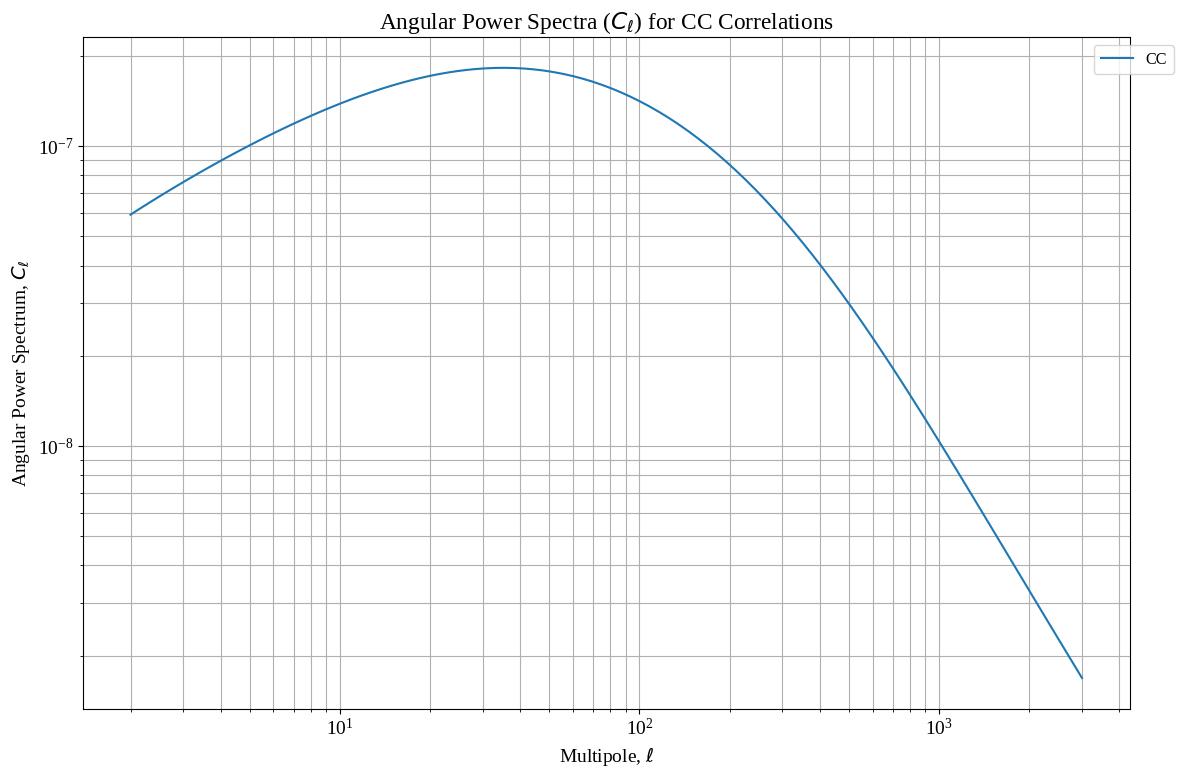

BBKS/sigma8 PyCCL angular_cl Calculation: 0.4956 seconds
CAMB/A_s PyCCL Cosmology Instantiation: 0.0007 seconds


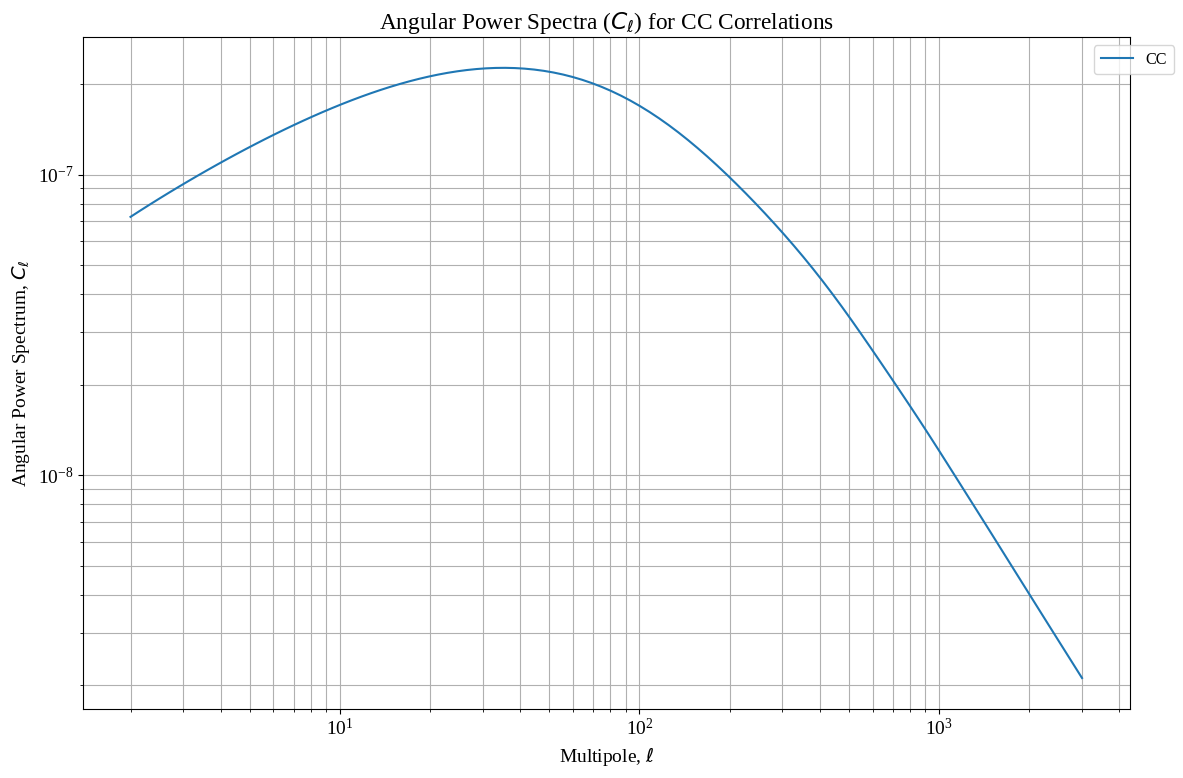

CAMB/A_s PyCCL angular_cl Calculation: 1.3597 seconds
Emulated Pk2D Object Creation: 0.0821 seconds


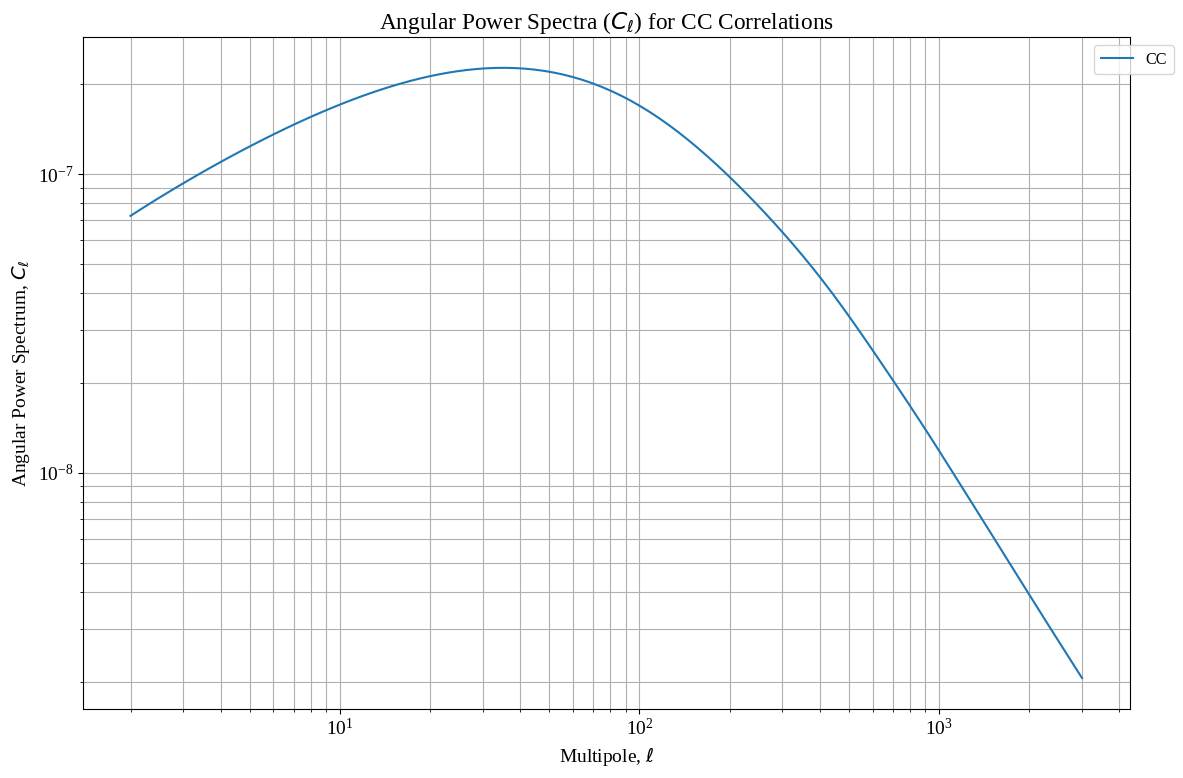

Emulated P(k) angular_cl Calculation: 0.3155 seconds

General Summary
These times all include plotting. In my MCMC I do not actually plot the Cls, so these efficiency comparisons are a little incomplete.
In a later cell I will compare just the creation.
The times and differences vary each run. The final two results (see 'bottom line') generally stay between .65-1.0 and .35-.5, respectively.
The emulator cosmologies use the CAMB solver by necessity, so they are generally more accurate than the BBKs ones.
This is not lsot time, as I think I'd use CAMB/CLASS for my analyses anyway, since they are more accurate.
Total BBKS (sigma8) PyCCL time: 0.4964 seconds (Cosmology Init + angular_cl)
Total CAMB (A_s) PyCCL time: 1.3604 seconds (Cosmology Init + angular_cl)
Total Emulated PyCCL time: 0.3984 seconds (Cosmology Init + Pk2D Creation + angular_cl)
Total Emulated P(k) angular_cl time was 0.64 times that of the than (less accurate) BBKS (sigma8) PyCCL angular_cl.
Total Emulated P(k) angular_c

In [9]:
# test timing and accuracy w/plots

# standard PyCCL w/sigma8
start_time_ccl1_init = time.time()

z_star = 1100.0
Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
Omega_k = 0
Omega_b = 0.045
n_s=0.96
Omega_c = 0.27
sigma8 = 0.8

flat_LCDM_cosmology1_timed = ccl.Cosmology(
    Omega_k=Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, sigma8=sigma8, # Use A_s here
    n_s=n_s, transfer_function='bbks'
)
end_time_ccl1_init = time.time()
time_ccl1_init = end_time_ccl1_init - start_time_ccl1_init
print(f"BBKS/sigma8 PyCCL Cosmology Instantiation: {time_ccl1_init:.4f} seconds")

start_time_ccl1_cl = time.time()
calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology1_timed, # Use the newly created cosmology object
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CC'])
end_time_ccl1_cl = time.time()
time_ccl1_cl = end_time_ccl1_cl - start_time_ccl1_cl
print(f"BBKS/sigma8 PyCCL angular_cl Calculation: {time_ccl1_cl:.4f} seconds")

# standard PyCCL w/A_s
start_time_ccl2_init = time.time()

Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
A_s = 2.1e-9 # Using A_s, consistent with emulator input
Omega_k = 0
Omega_b = 0.045
n_s=0.96
Omega_c = 0.27

flat_LCDM_cosmology2_timed = ccl.Cosmology(
    Omega_k=Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s=A_s, # Use A_s here
    n_s=n_s, transfer_function='boltzmann_camb'
)
end_time_ccl2_init = time.time()
time_ccl2_init = end_time_ccl2_init - start_time_ccl2_init
print(f"CAMB/A_s PyCCL Cosmology Instantiation: {time_ccl2_init:.4f} seconds")

start_time_ccl2_cl = time.time()
calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology2_timed, # Use the newly created cosmology object
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CC'])
end_time_ccl2_cl = time.time()
time_ccl2_cl = end_time_ccl2_cl - start_time_ccl2_cl
print(f"CAMB/A_s PyCCL angular_cl Calculation: {time_ccl2_cl:.4f} seconds")

# emulator
# 20 points spaced evenly in scale factor from z=0 (a=1) to z=5 (a=1/6)
start_time_emu_pk2d = time.time()
a_grid = np.linspace(1/(1+5), 1.0, 20)
z_grid = (1.0 / a_grid) - 1.0

Pk2D_full_timed = make_Pk2D(
    flat_LCDM_cosmology2_timed, # Use the same cosmology to ensure parameter consistency
    linear_emulator=lin_emu,
    boost_emulator=boost_emu,
    z_arr=z_grid,
    cmin=3.13,
    eta_0=0.60
)
end_time_emu_pk2d = time.time()
time_emu_pk2d = end_time_emu_pk2d - start_time_emu_pk2d
print(f"Emulated Pk2D Object Creation: {time_emu_pk2d:.4f} seconds")

start_time_emu_cl = time.time()
calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology2_timed,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CC'],
    Pk2D_object = Pk2D_full_timed
)
end_time_emu_cl = time.time()
time_emu_cl = end_time_emu_cl - start_time_emu_cl
print(f"Emulated P(k) angular_cl Calculation: {time_emu_cl:.4f} seconds")

# results
print("")
print("General Summary")
print("These times all include plotting. In my MCMC I do not actually plot the Cls, so these efficiency comparisons are a little incomplete.")
print("In a later cell I will compare just the creation.")
print("The times and differences vary each run. The final two results (see 'bottom line') generally stay between .65-1.0 and .35-.5, respectively.")
print("The emulator cosmologies use the CAMB solver by necessity, so they are generally more accurate than the BBKs ones.")
print("This is not lsot time, as I think I'd use CAMB/CLASS for my analyses anyway, since they are more accurate.")
print(f"Total BBKS (sigma8) PyCCL time: {time_ccl1_init + time_ccl1_cl:.4f} seconds (Cosmology Init + angular_cl)")
print(f"Total CAMB (A_s) PyCCL time: {time_ccl2_init + time_ccl2_cl:.4f} seconds (Cosmology Init + angular_cl)")
print(f"Total Emulated PyCCL time: {time_ccl2_init + time_emu_pk2d + time_emu_cl:.4f} seconds (Cosmology Init + Pk2D Creation + angular_cl)")
print(f"Total Emulated P(k) angular_cl time was {time_emu_cl / time_ccl1_cl:.2f} times that of the than (less accurate) BBKS (sigma8) PyCCL angular_cl.")
print(f"Total Emulated P(k) angular_cl time was {time_emu_cl / time_ccl2_cl:.2f} times that of the than (more accurate) CAMB (A_s) PyCCL angular_cl.")

print("")
print("Bottom Line")
print(f"Total Emulated PyCCL time was {(time_ccl2_init + time_emu_pk2d + time_emu_cl) / (time_ccl1_init + time_ccl1_cl):.2f} times the that of the (less accurate) BBKS (sigma8) PyCCL Cosmology Init.")
print(f"Total Emulated PyCCL time was {(time_ccl2_init + time_emu_pk2d + time_emu_cl) / (time_ccl2_init + time_ccl2_cl):.2f} times the that of the (more accurate) CAMB (A_s) PyCCL Cosmology Init.")

In [21]:
# test timing and accuracy w/o plots

# standard PyCCL w/sigma8
start_time_ccl1_init = time.time()

z_star = 1100.0
Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
Omega_k = 0
Omega_b = 0.045
n_s=0.96
Omega_c = 0.27
sigma8 = 0.8

flat_LCDM_cosmology1_timed = ccl.Cosmology(
    Omega_k=Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, sigma8=sigma8, n_s=n_s, transfer_function='bbks')
end_time_ccl1_init = time.time()
time_ccl1_init = end_time_ccl1_init - start_time_ccl1_init
print(f"BBKS/sigma8 PyCCL Cosmology Instantiation: {time_ccl1_init:.4f} seconds")

start_time_ccl1_cl = time.time()
calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology1_timed, # Use the newly created cosmology object
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CL'],
    plot = 'no')
end_time_ccl1_cl = time.time()
time_ccl1_cl = end_time_ccl1_cl - start_time_ccl1_cl
print(f"BBKS/sigma8 PyCCL angular_cl Calculation: {time_ccl1_cl:.4f} seconds")

# standard PyCCL w/A_s
start_time_ccl2_init = time.time()

Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
A_s = 2.1e-9 # Using A_s, consistent with emulator input
Omega_k = 0
Omega_b = 0.045
n_s=0.96
Omega_c = 0.27

flat_LCDM_cosmology2_timed = ccl.Cosmology(
    Omega_k=Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s=A_s, # Use A_s here
    n_s=n_s, transfer_function='boltzmann_camb')
end_time_ccl2_init = time.time()
time_ccl2_init = end_time_ccl2_init - start_time_ccl2_init
print(f"CAMB/A_s PyCCL Cosmology Instantiation: {time_ccl2_init:.4f} seconds")

start_time_ccl2_cl = time.time()
standard_Cl_CL = calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology2_timed, # Use the newly created cosmology object
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CL'],
    plot = 'no')
end_time_ccl2_cl = time.time()
time_ccl2_cl = end_time_ccl2_cl - start_time_ccl2_cl
print(f"CAMB/A_s PyCCL angular_cl Calculation: {time_ccl2_cl:.4f} seconds")

# emulator
# 20 points spaced evenly in scale factor from z=0 (a=1) to z=5 (a=1/6)
start_time_emu_pk2d = time.time()
a_grid = np.linspace(1/(1+5), 1.0, 20)
z_grid = (1.0 / a_grid) - 1.0

Pk2D_full_timed = make_Pk2D(
    flat_LCDM_cosmology2_timed, # Use the same cosmology to ensure parameter consistency
    linear_emulator=lin_emu,
    boost_emulator=boost_emu,
    z_arr=z_grid,
    cmin=3.13,
    eta_0=0.60
)
end_time_emu_pk2d = time.time()
time_emu_pk2d = end_time_emu_pk2d - start_time_emu_pk2d
print(f"Emulated Pk2D Object Creation: {time_emu_pk2d:.4f} seconds")

#timed_Pk2D_object = instrument_Pk2D(Pk2D_full_timed)

start_time_emu_cl = time.time()
emulator_Cl_CL = calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology2_timed,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CL'],
    plot = 'no',
    Pk2D_object = Pk2D_full_timed
)
end_time_emu_cl = time.time()
time_emu_cl = end_time_emu_cl - start_time_emu_cl
print(f"Emulated P(k) angular_cl Calculation: {time_emu_cl:.4f} seconds")

# find percent of PyCCL runtime spent calling Pk2D
#timing_info = timed_Pk2D_object.get_timing_info()
#total_Pk2D_call_time_s = timing_info['total_time_ns']
#Pk2D_call_count = timing_info['call_count']
#print(f"Number of Pk2D.__call__ invocations: {Pk2D_call_count}")
#print(f"Total time spent in Pk2D.__call__ method: {total_Pk2D_call_time_s:.6f} seconds")

# separate Pk2D call
#start_time_call_Pk2D = time.time()
#temp_Pk2D = Pk2D_full_timed
#end_time_call_Pk2D = time.time()
#time_call_Pk2D = end_time_call_Pk2D - start_time_call_Pk2D
#print(f"Time to call Pk2D outside of PyCCL: {time_call_Pk2D:.4f} seconds")

# results
print("")
print("General Summary")
print("The times and differences vary slightly each run. The final two results (see 'bottom line') generally stay between .51-.61 and .12-.16, respectively.")
print("The emulator cosmologies use the CAMB solver by necessity, so they are generally more accurate than the BBKs ones.")
print("This is not lost time, as I think I'd use CAMB/CLASS for my analyses anyway, since they are more accurate.")
print(f"Total BBKS (sigma8) PyCCL time: {time_ccl1_init + time_ccl1_cl:.4f} seconds (Cosmology Init + angular_cl)")
print(f"Total CAMB (A_s) PyCCL time: {time_ccl2_init + time_ccl2_cl:.4f} seconds (Cosmology Init + angular_cl)")
print(f"Total Emulated PyCCL time: {time_ccl2_init + time_emu_pk2d + time_emu_cl:.4f} seconds (Cosmology Init + Pk2D Creation + angular_cl)")
print(f"Total Emulated P(k) angular_cl calculation time was {time_emu_cl / time_ccl1_cl:.2f} times that of the than (less accurate) BBKS (sigma8) PyCCL angular_cl.")
print(f"Total Emulated P(k) angular_cl calculation time was {time_emu_cl / time_ccl2_cl:.2f} times that of the than (more accurate) CAMB (A_s) PyCCL angular_cl.")
#print(f"The time to call the Pk2D object ONCE was {time_call_Pk2D / time_emu_cl} times that of the total PyCCL emulator Cl calculation (excluding emulator building).")

print("")
print("Bottom Line")
print(f"Total Emulated PyCCL time was {(time_ccl2_init + time_emu_pk2d + time_emu_cl) / (time_ccl1_init + time_ccl1_cl):.2f} times the that of the (less accurate) BBKS (sigma8) PyCCL Cosmology Init.")
print(f"Total Emulated PyCCL time was {(time_ccl2_init + time_emu_pk2d + time_emu_cl) / (time_ccl2_init + time_ccl2_cl):.2f} times the that of the (more accurate) CAMB (A_s) PyCCL Cosmology Init.")

BBKS/sigma8 PyCCL Cosmology Instantiation: 0.0007 seconds
BBKS/sigma8 PyCCL angular_cl Calculation: 0.1822 seconds
CAMB/A_s PyCCL Cosmology Instantiation: 0.0007 seconds
CAMB/A_s PyCCL angular_cl Calculation: 1.0381 seconds
Emulated Pk2D Object Creation: 0.0709 seconds
Emulated P(k) angular_cl Calculation: 0.0239 seconds

General Summary
The times and differences vary slightly each run. The final two results (see 'bottom line') generally stay between .51-.61 and .12-.16, respectively.
The emulator cosmologies use the CAMB solver by necessity, so they are generally more accurate than the BBKs ones.
This is not lost time, as I think I'd use CAMB/CLASS for my analyses anyway, since they are more accurate.
Total BBKS (sigma8) PyCCL time: 0.1829 seconds (Cosmology Init + angular_cl)
Total CAMB (A_s) PyCCL time: 1.0388 seconds (Cosmology Init + angular_cl)
Total Emulated PyCCL time: 0.0955 seconds (Cosmology Init + Pk2D Creation + angular_cl)
Total Emulated P(k) angular_cl calculation time w

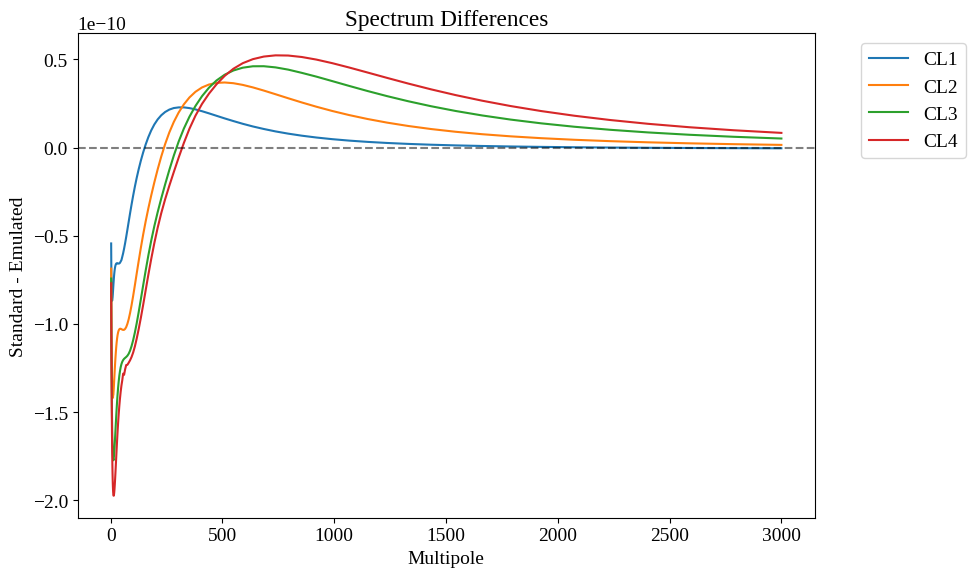

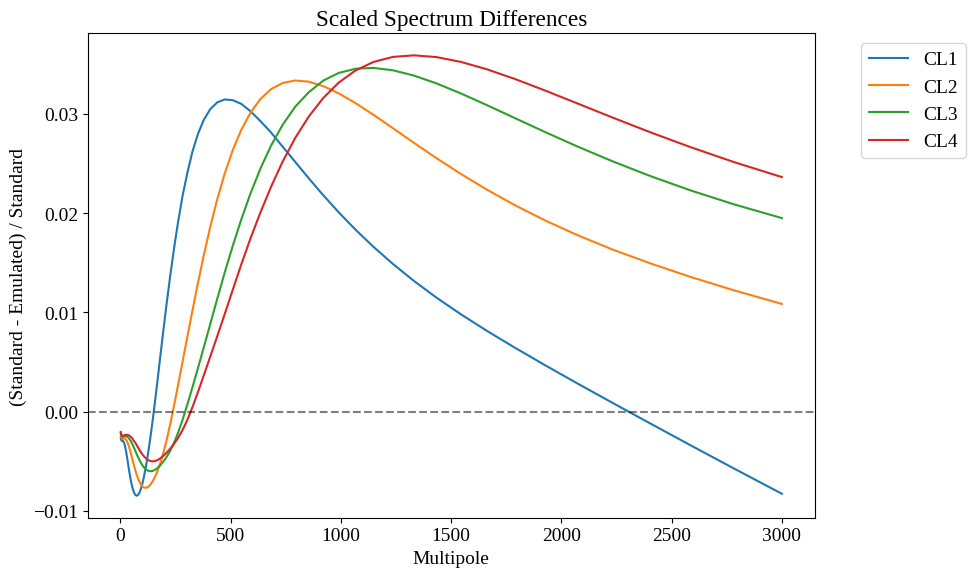

In [23]:
# compare the Cl's

ell_values = np.logspace(np.log10(2), np.log10(3000), 100)

# straight diff
plt.figure(figsize=(10, 6))

for key in sorted(standard_Cl_CL.keys()):
    diff = standard_Cl_CL[key] - emulator_Cl_CL[key]
    plt.plot(ell_values, diff, label=key)

plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.xlabel("Multipole")
plt.ylabel("Standard - Emulated")
plt.title("Spectrum Differences")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# scaled diff
plt.figure(figsize=(10, 6))

for key in sorted(standard_Cl_CL.keys()):
    diff = standard_Cl_CL[key] - emulator_Cl_CL[key]
    scaled_diff = diff / standard_Cl_CL[key]
    plt.plot(ell_values, scaled_diff, label=key)

plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.xlabel("Multipole")
plt.ylabel("(Standard - Emulated) / Standard")
plt.title("Scaled Spectrum Differences")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
# test timing and accuracy w/o plots -- LL

# standard PyCCL w/sigma8
start_time_ccl1_init = time.time()

z_star = 1100.0
Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
Omega_k = 0
Omega_b = 0.045
n_s=0.96
Omega_c = 0.27
sigma8 = 0.8

flat_LCDM_cosmology1_timed = ccl.Cosmology(
    Omega_k=Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, sigma8=sigma8, n_s=n_s, transfer_function='bbks')
end_time_ccl1_init = time.time()
time_ccl1_init = end_time_ccl1_init - start_time_ccl1_init
print(f"BBKS/sigma8 PyCCL Cosmology Instantiation: {time_ccl1_init:.4f} seconds")

start_time_ccl1_cl = time.time()
calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology1_timed, # Use the newly created cosmology object
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['LL'],
    plot = 'no')
end_time_ccl1_cl = time.time()
time_ccl1_cl = end_time_ccl1_cl - start_time_ccl1_cl
print(f"BBKS/sigma8 PyCCL angular_cl Calculation: {time_ccl1_cl:.4f} seconds")

# standard PyCCL w/A_s
start_time_ccl2_init = time.time()

Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
A_s = 2.1e-9 # Using A_s, consistent with emulator input
Omega_k = 0
Omega_b = 0.045
n_s=0.96
Omega_c = 0.27

flat_LCDM_cosmology2_timed = ccl.Cosmology(
    Omega_k=Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s=A_s, # Use A_s here
    n_s=n_s, transfer_function='boltzmann_camb')
end_time_ccl2_init = time.time()
time_ccl2_init = end_time_ccl2_init - start_time_ccl2_init
print(f"CAMB/A_s PyCCL Cosmology Instantiation: {time_ccl2_init:.4f} seconds")

start_time_ccl2_cl = time.time()
standard_Cl_LL = calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology2_timed, # Use the newly created cosmology object
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['LL'],
    plot = 'no')
end_time_ccl2_cl = time.time()
time_ccl2_cl = end_time_ccl2_cl - start_time_ccl2_cl
print(f"CAMB/A_s PyCCL angular_cl Calculation: {time_ccl2_cl:.4f} seconds")

# emulator
# 20 points spaced evenly in scale factor from z=0 (a=1) to z=5 (a=1/6)
start_time_emu_pk2d = time.time()
a_grid = np.linspace(1/(1+5), 1.0, 20)
z_grid = (1.0 / a_grid) - 1.0

Pk2D_full_timed = make_Pk2D(
    flat_LCDM_cosmology2_timed, # Use the same cosmology to ensure parameter consistency
    linear_emulator=lin_emu,
    boost_emulator=boost_emu,
    z_arr=z_grid,
    cmin=3.13,
    eta_0=0.60
)
end_time_emu_pk2d = time.time()
time_emu_pk2d = end_time_emu_pk2d - start_time_emu_pk2d
print(f"Emulated Pk2D Object Creation: {time_emu_pk2d:.4f} seconds")

#timed_Pk2D_object = instrument_Pk2D(Pk2D_full_timed)

start_time_emu_cl = time.time()
emulator_Cl_LL = calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology2_timed,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['LL'],
    plot = 'no',
    Pk2D_object = Pk2D_full_timed
)
end_time_emu_cl = time.time()
time_emu_cl = end_time_emu_cl - start_time_emu_cl
print(f"Emulated P(k) angular_cl Calculation: {time_emu_cl:.4f} seconds")

# find percent of PyCCL runtime spent calling Pk2D
#timing_info = timed_Pk2D_object.get_timing_info()
#total_Pk2D_call_time_s = timing_info['total_time_ns']
#Pk2D_call_count = timing_info['call_count']
#print(f"Number of Pk2D.__call__ invocations: {Pk2D_call_count}")
#print(f"Total time spent in Pk2D.__call__ method: {total_Pk2D_call_time_s:.6f} seconds")

# separate Pk2D call
#start_time_call_Pk2D = time.time()
#temp_Pk2D = Pk2D_full_timed
#end_time_call_Pk2D = time.time()
#time_call_Pk2D = end_time_call_Pk2D - start_time_call_Pk2D
#print(f"Time to call Pk2D outside of PyCCL: {time_call_Pk2D:.4f} seconds")

# results
print("")
print("General Summary")
print("The times and differences vary slightly each run. The final two results (see 'bottom line') generally stay between .51-.61 and .12-.16, respectively.")
print("The emulator cosmologies use the CAMB solver by necessity, so they are generally more accurate than the BBKs ones.")
print("This is not lost time, as I think I'd use CAMB/CLASS for my analyses anyway, since they are more accurate.")
print(f"Total BBKS (sigma8) PyCCL time: {time_ccl1_init + time_ccl1_cl:.4f} seconds (Cosmology Init + angular_cl)")
print(f"Total CAMB (A_s) PyCCL time: {time_ccl2_init + time_ccl2_cl:.4f} seconds (Cosmology Init + angular_cl)")
print(f"Total Emulated PyCCL time: {time_ccl2_init + time_emu_pk2d + time_emu_cl:.4f} seconds (Cosmology Init + Pk2D Creation + angular_cl)")
print(f"Total Emulated P(k) angular_cl calculation time was {time_emu_cl / time_ccl1_cl:.2f} times that of the than (less accurate) BBKS (sigma8) PyCCL angular_cl.")
print(f"Total Emulated P(k) angular_cl calculation time was {time_emu_cl / time_ccl2_cl:.2f} times that of the than (more accurate) CAMB (A_s) PyCCL angular_cl.")
#print(f"The time to call the Pk2D object ONCE was {time_call_Pk2D / time_emu_cl} times that of the total PyCCL emulator Cl calculation (excluding emulator building).")

print("")
print("Bottom Line")
print(f"Total Emulated PyCCL time was {(time_ccl2_init + time_emu_pk2d + time_emu_cl) / (time_ccl1_init + time_ccl1_cl):.2f} times the that of the (less accurate) BBKS (sigma8) PyCCL Cosmology Init.")
print(f"Total Emulated PyCCL time was {(time_ccl2_init + time_emu_pk2d + time_emu_cl) / (time_ccl2_init + time_ccl2_cl):.2f} times the that of the (more accurate) CAMB (A_s) PyCCL Cosmology Init.")

In [ ]:
# compare the Cl LL's

ell_values = np.logspace(np.log10(2), np.log10(3000), 100)

# straight diff
plt.figure(figsize=(10, 6))

for key in sorted(standard_Cl_LL.keys()):
    diff = standard_Cl_LL[key] - emulator_Cl_LL[key]
    plt.plot(ell_values, diff, label=key)

plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.xlabel("Multipole")
plt.ylabel("Standard - Emulated")
plt.title("Spectrum Differences")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# scaled diff
plt.figure(figsize=(10, 6))

for key in sorted(standard_Cl_LL.keys()):
    diff = standard_Cl_LL[key] - emulator_Cl_LL[key]
    scaled_diff = diff / standard_Cl_LL[key]
    plt.plot(ell_values, scaled_diff, label=key)

plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.xlabel("Multipole")
plt.ylabel("(Standard - Emulated) / Standard")
plt.title("Scaled Spectrum Differences")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Convariance Matrices

The covariance matrix is rather complicated because we have many different types of data for which we need to consider the covariances. We'll set up the data vector:

$$\mathbf{D} = [C_\ell^{\phi\phi}, C_\ell^{gg}, C_\ell^{\gamma\gamma}, C_\ell^{g\gamma}, C_\ell^{g\phi}, C_\ell^{\gamma\phi}]$$

Note: $\phi$ should really read $\kappa$ but this was built with $\phi$ and changing it has spawned a bunch of errors and mismatches so I'm sticking with $\phi$

This vector consists of:
* **CMB lensing convergence power spectrum:** $C_\ell^{\phi\phi}$
* **Lens galaxies auto/cross-spectrum:** $C_\ell^{gg}$ (galaxy clustering)
* **Galaxy lensing auto/cross-spectrum:** $C_\ell^{\gamma\gamma}$ (cosmic shear)
* **Lens galaxy-galaxy lensing cross-spectrum:** $C_\ell^{g\gamma}$ (galaxy-galaxy lensing)
* **Lens galaxies–CMB lensing cross-spectrum:** $C_\ell^{g\phi}$
* **Galaxy lensing–CMB lensing cross-spectrum:** $C_\ell^{\gamma\phi}$

If we have **a** lens bins and **b** source bins we have 1 CMB, $\frac{a(a+1)}{2}$ lens-lens, $\frac{b(b+1)}{2}$ source-source, ab lens-source, a lens-CMB, and b source-CMB spectra. Each component is a list with $N_l$ entries.

The covariance matrix includes the covariances of all spectra with all other spectra. This means that it is a massive block matrix, with each block being an $N_\ell \times N_\ell$ matrix.

$$\text{Cov}_{\text{master }}[i,j] = \text{Cov}(D_i, D_j)$$
$$\mathrm{Cov}(C^{ab}_{\ell}, C^{cd}_{\ell'}) = \frac{\delta_{\ell \ell'}}{(2\ell + 1)\, f_{\mathrm{sky}}} \left( C^{ac}_\ell C^{bd}_\ell + C^{ad}_\ell C^{bc}_\ell \right)$$

In order to do a proper MCMC, we will need to calculate the entries in the master covariance matrix and input it into Cobaya.

Note that calculating covariances will be a little tricky because we'll need the computer to figure out what spectra are being considered, separate out their variables, swap them around, and then locate the correct spectra for the product terms.

In [8]:
# build DESI, SO noise, and magnification
# shot noise ref: https://arxiv.org/pdf/2407.04607
# shape noise ref: slack from Simone, can't find the Github itself
# SO noise ref:
# magnification ref: https://arxiv.org/pdf/2503.24385

sigma = 0.26
DESI_n_bar_deg2 = np.array([81.9, 148.1, 162.4, 148.3]) # Galaxies per square degree

# Convert n_bar from per deg^2 to per steradian
# 1 steradian = (180/pi)^2 square degrees
DESI_n_bar_steradian = DESI_n_bar_deg2 * (180.0 / np.pi)**2

DESI_shot_noise = np.zeros_like(DESI_n_bar_steradian)
DESI_shape_noise = np.zeros_like(DESI_n_bar_steradian)
for i in range(len(DESI_shot_noise)):
    DESI_shot_noise[i] = 1 / DESI_n_bar_steradian[i]
    DESI_shape_noise[i] = sigma ** 2 / DESI_n_bar_steradian[i]

# CMB noise arises from idk a bunch of stuff
# we have an SO noise curve, but it does not have precisely the same ells as our C_l
# we must interpolate the N_kk to produce a useful noise curve
SO_noise_data = np.genfromtxt("data/nlkk_v3_1_0deproj0_SENS2_fsky0p4_it_lT30-3000_lP30-5000.dat")
S_noise_ells = SO_noise_data[:, 0]
N_kk = SO_noise_data[:, 7]
ells_for_noise_interp = np.arange(2, 5000 + 2) # Assuming n_ell = 5000 for new analysis
low_ells_for_noise_interp = np.arange(2, 1500 + 2)

# Use fill_value=(N_kk[0], N_kk[-1]) to cap the noise at the boundaries
interpolated_N_kk_func = interp1d(S_noise_ells, N_kk, bounds_error=False, fill_value=(N_kk[0], N_kk[-1]))
SO_CMB_noise = interpolated_N_kk_func(ells_for_noise_interp)
low_l_SO_CMB_noise = interpolated_N_kk_func(low_ells_for_noise_interp)
# Handle potential negative noise if for some reason the source data contains them, set to a small positive number
SO_CMB_noise[SO_CMB_noise < 0] = 1e-30 # Or whatever appropriate small value
low_l_SO_CMB_noise[low_l_SO_CMB_noise < 0] = 1e-30

# save
# make sure folder exists
os.makedirs("data", exist_ok=True)
np.save("data/SO_CMB_noise.npy", SO_CMB_noise)
print("Saved SO_CMB_noise to data/SO_CMB_noise.npy")
np.save("data/low_l_SO_CMB_noise.npy", low_l_SO_CMB_noise)
print("Saved shortened SO_CMB_noise to data/SO_CMB_noise.npy")

Saved SO_CMB_noise to data/SO_CMB_noise.npy
Saved shortened SO_CMB_noise to data/SO_CMB_noise.npy


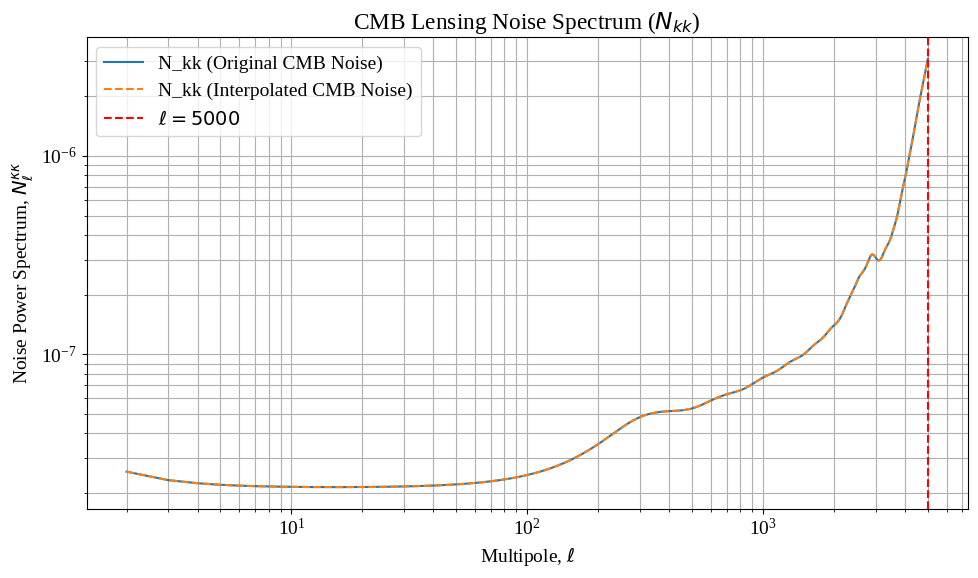

In [9]:
# plot N_kk to see what it looks like

plt.figure(figsize=(10, 6))
plt.loglog(S_noise_ells, N_kk, label='N_kk (Original CMB Noise)')
plt.loglog(ells_for_noise_interp, SO_CMB_noise, label='N_kk (Interpolated CMB Noise)', linestyle='--')
plt.xlabel('Multipole, $\ell$')
plt.ylabel('Noise Power Spectrum, $N_{\ell}^{\kappa\kappa}$')
plt.title('CMB Lensing Noise Spectrum ($N_{kk}$)')
plt.axvline(x=5000, color='red', linestyle='--', label='$\ell = 5000$') # Added vertical line
plt.legend()
plt.grid(True, which="both", ls="-")
plt.tight_layout()
plt.show()

In [10]:
# make and save noise and data files for just the first bin

# make sure folder exists
os.makedirs("data", exist_ok=True)

# data
DESI_lens_data_bin1 = DESI_lens_data[:, :2]  # z + first lens bin
HSC_dist_0_3_bin1 = HSC_dist_0_3[:, :2]       # z + first source bin

# noise
DESI_shot_noise_bin1 = np.array([DESI_shot_noise[0]])
DESI_shape_noise_bin1 = np.array([DESI_shape_noise[0]])
#SO_CMB_noise was already saved

# save
np.save("data/DESI_lens_data_bin1.npy", DESI_lens_data_bin1)
np.save("data/HSC_dist_0_3_bin1.npy", HSC_dist_0_3_bin1)
np.save("data/DESI_shot_noise_bin1.npy", DESI_shot_noise_bin1)
np.save("data/DESI_shape_noise_bin1.npy", DESI_shape_noise_bin1)
#SO_CMB_noise was already saved
    
# check
print("DESI_lens_data_bin1 shape:", DESI_lens_data_bin1.shape)
print("HSC_dist_0_3_bin1 shape:", HSC_dist_0_3_bin1.shape)
print("DESI_shot_noise_bin1:", DESI_shot_noise_bin1)
print("DESI_shape_noise_bin1:", DESI_shape_noise_bin1)
print("SO_CMB_noise:", SO_CMB_noise)

DESI_lens_data_bin1 shape: (293, 2)
HSC_dist_0_3_bin1 shape: (1000, 2)
DESI_shot_noise_bin1: [3.71938241e-06]
DESI_shape_noise_bin1: [2.51430251e-07]
SO_CMB_noise: [2.566829e-08 2.327497e-08 2.244052e-08 ... 3.084815e-06 3.088479e-06
 3.088479e-06]


In [11]:
# 1. Save Full DESI Lens Data (all 4 bins: columns z, nz_a, nz_b, nz_c, nz_d)
# Note: DESI_lens_data was already column-stacked in Cell 4
np.save("data/DESI_lens_data.npy", DESI_lens_data)

# 2. Save Full HSC Source Data (all 4 bins for both redshift ranges)
np.save("data/HSC_dist_0_3.npy", HSC_dist_0_3)
np.save("data/HSC_dist_1_5.npy", HSC_dist_1_5)

# 3. Save Full DESI Shot Noise and Shape Noise (Arrays for all 4 bins)
# These were calculated for all bins using DESI_n_bar_steradian in Cell 8
np.save("data/DESI_shot_noise.npy", DESI_shot_noise)
np.save("data/DESI_shape_noise.npy", DESI_shape_noise)

# Verification Printouts
print("Full datasets saved successfully!")
print("DESI Lens Data shape: ", DESI_lens_data.shape)
print("HSC 0.3-3 Dist shape: ", HSC_dist_0_3.shape)
print("DESI Shot Noise array:", DESI_shot_noise)
print("DESI Shape Noise array:", DESI_shape_noise)

Full datasets saved successfully!
DESI Lens Data shape:  (293, 5)
HSC 0.3-3 Dist shape:  (1000, 5)
DESI Shot Noise array: [3.71938241e-06 2.05683606e-06 1.87572303e-06 2.05406217e-06]
DESI Shape Noise array: [2.51430251e-07 1.39042117e-07 1.26798877e-07 1.38854603e-07]


In [ ]:
# calculate and save flat LCDM fiducial data vector and covariance matrix for single bin (A_s) w/o emulator

# ensure output directory exists
os.makedirs('cobaya_data', exist_ok=True)

print("Calculating fiducial data vector and covariance matrix for single bin...")

# Use explicit parameters for fiducial cosmology, avoiding dependency on info_single_bin
# These values are taken from the 'fiducial_cosmology_params' in the original 'info' dict (cell 93e8009f)
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.27,
    Omega_b=0.045,
    h=0.674,
    A_s=2.105e-9,
    n_s=0.96,
    w0=-1.0,
    wa=0.0,
    Omega_k=0.0,
    transfer_function='boltzmann_camb'
)

# extract other parameters directly, or hardcode them if they are constant for this generation step
f_sky = 0.4
n_ell = 5000
binsize = 50
magnification_bias_lenses = 0.8
desired_spectra = ['GG', 'LL', 'GL', 'CC', 'CL', 'CG']

# build covariance and spectra dictionary w/o emulator, so they'll be maximally accurate
cov_obj, fiducial_spectra_dict, f_map = \
    build_covariance_from_data(
        fiducial_cosmology,
        DESI_lens_data_bin1,
        HSC_dist_0_3_bin1,
        f_sky=f_sky,
        n_ell=n_ell,
        binsize=binsize,
        shot_noise_lens=DESI_shot_noise_bin1,
        shape_noise_source=DESI_shape_noise_bin1,
        cmb_noise_phi=SO_CMB_noise, 
        magnification_bias_lenses=magnification_bias_lenses,
        desired_spectra=desired_spectra,
        linear_emulator=None,
        boost_emulator=None
    )

# extract and flatten the fiducial data vector
observed_data_vector = np.array([])
num_binned_ells = int(np.ceil(n_ell / binsize))

for pair in f_map.pairs:
    unbinned_cls = fiducial_spectra_dict[pair]
    binned_cls_for_pair = []
    for i in range(0, n_ell, binsize):
        end_idx = min(i + binsize, len(unbinned_cls))
        if i < end_idx:
            binned_cls_for_pair.append(np.mean(unbinned_cls[i:end_idx]))
        else:
            binned_cls_for_pair.append(0.0)
    while len(binned_cls_for_pair) < num_binned_ells:
        binned_cls_for_pair.append(0.0)
    observed_data_vector = np.concatenate((observed_data_vector, binned_cls_for_pair))

# get the covariance matrix
covariance_matrix = cov_obj.matrix

# Save to files
data_vector_filename = 'cobaya_data/flat_LCDM_bin1_data_vector.npy'
covariance_filename = 'cobaya_data/flat_LCDM_bin1_covariance_matrix.npy'

np.save(data_vector_filename, observed_data_vector)
np.save(covariance_filename, covariance_matrix)

print(f"Fiducial data vector saved to: {data_vector_filename}")
print(f"Covariance matrix saved to: {covariance_filename}")

#plot_covariance_matrix(cov_obj, fiducial_spectra_dict, f_map, binsize=50, desired_spectra=['CG', 'GL'])
#plot_correlation_matrix(cov_obj, fiducial_spectra_dict, f_map, binsize=50, desired_spectra=['CG', 'GL'])

In [ ]:
# calculate and save flat LCDM fiducial data vector and covariance matrix for single bin (A_s) w/emulator

# ensure output directory exists
os.makedirs('cobaya_data', exist_ok=True)

print("Calculating fiducial data vector and covariance matrix for single bin...")

# Use explicit parameters for fiducial cosmology, avoiding dependency on info_single_bin
# These values are taken from the 'fiducial_cosmology_params' in the original 'info' dict (cell 93e8009f)
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.27,
    Omega_b=0.045,
    h=0.674,
    A_s=2.105e-9,
    n_s=0.96,
    w0=-1.0,
    wa=0.0,
    Omega_k=0.0,
    transfer_function='boltzmann_camb'
)

# extract other parameters directly, or hardcode them if they are constant for this generation step
f_sky = 0.4
n_ell = 5000
binsize = 50
magnification_bias_lenses = 0.8
desired_spectra = ['GG', 'LL', 'GL', 'CC', 'CL', 'CG']

# build covariance and spectra dictionary w/o emulator, so they'll be maximally accurate
cov_obj, fiducial_spectra_dict, f_map = \
    build_covariance_from_data(
        fiducial_cosmology,
        DESI_lens_data_bin1,
        HSC_dist_0_3_bin1,
        f_sky=f_sky,
        n_ell=n_ell,
        binsize=binsize,
        shot_noise_lens=DESI_shot_noise_bin1,
        shape_noise_source=DESI_shape_noise_bin1,
        cmb_noise_phi=SO_CMB_noise, 
        magnification_bias_lenses=magnification_bias_lenses,
        desired_spectra=desired_spectra,
        linear_emulator=lin_emu,
        boost_emulator=boost_emu
    )

# extract and flatten the fiducial data vector
observed_data_vector = np.array([])
num_binned_ells = int(np.ceil(n_ell / binsize))

for pair in f_map.pairs:
    unbinned_cls = fiducial_spectra_dict[pair]
    binned_cls_for_pair = []
    for i in range(0, n_ell, binsize):
        end_idx = min(i + binsize, len(unbinned_cls))
        if i < end_idx:
            binned_cls_for_pair.append(np.mean(unbinned_cls[i:end_idx]))
        else:
            binned_cls_for_pair.append(0.0)
    while len(binned_cls_for_pair) < num_binned_ells:
        binned_cls_for_pair.append(0.0)
    observed_data_vector = np.concatenate((observed_data_vector, binned_cls_for_pair))

# get the covariance matrix
covariance_matrix = cov_obj.matrix

# Save to files
data_vector_filename = 'cobaya_data/emulated_flat_LCDM_bin1_data_vector.npy'
covariance_filename = 'cobaya_data/emulated_flat_LCDM_bin1_covariance_matrix.npy'

np.save(data_vector_filename, observed_data_vector)
np.save(covariance_filename, covariance_matrix)

In [ ]:
# calculate lensing ratios flat LCDM fiducial data vector and covariance matrix for single bin (A_s) w/emulator
# get sliced matrix and vector -- I care only about CG and GL

# ensure output directory exists
os.makedirs('cobaya_data', exist_ok=True)

print("Calculating fiducial data vector and covariance matrix for single bin...")

# Use explicit parameters for fiducial cosmology, avoiding dependency on info_single_bin
# These values are taken from the 'fiducial_cosmology_params' in the original 'info' dict (cell 93e8009f)
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.27,
    Omega_b=0.045,
    h=0.674,
    A_s=2.105e-9,
    n_s=0.96,
    w0=-1.0,
    wa=0.0,
    Omega_k=0.0,
    transfer_function='boltzmann_camb'
)

# extract other parameters directly, or hardcode them if they are constant for this generation step
f_sky = 0.4
n_ell = 5000
binsize = 50
magnification_bias_lenses = 0.8
desired_spectra = ['GL', 'CG']

# build covariance and spectra dictionary w/o emulator, so they'll be maximally accurate
cov_obj_sliced, fiducial_spectra_dict_sliced, f_map_sliced = \
    build_covariance_from_data(
        fiducial_cosmology,
        DESI_lens_data_bin1,
        HSC_dist_0_3_bin1,
        f_sky=f_sky,
        n_ell=n_ell,
        binsize=binsize,
        shot_noise_lens=DESI_shot_noise_bin1,
        shape_noise_source=DESI_shape_noise_bin1,
        cmb_noise_phi=SO_CMB_noise, 
        magnification_bias_lenses=magnification_bias_lenses,
        desired_spectra=desired_spectra,
        linear_emulator=lin_emu,
        boost_emulator=boost_emu
    )

# extract and flatten the fiducial data vector
observed_data_vector = np.array([])
num_binned_ells = int(np.ceil(n_ell / binsize))

for pair in f_map_sliced.pairs:
    unbinned_cls = fiducial_spectra_dict_sliced[pair]
    binned_cls_for_pair = []
    for i in range(0, n_ell, binsize):
        end_idx = min(i + binsize, len(unbinned_cls))
        if i < end_idx:
            binned_cls_for_pair.append(np.mean(unbinned_cls[i:end_idx]))
        else:
            binned_cls_for_pair.append(0.0)
    while len(binned_cls_for_pair) < num_binned_ells:
        binned_cls_for_pair.append(0.0)
    observed_data_vector = np.concatenate((observed_data_vector, binned_cls_for_pair))

# get the covariance matrix
covariance_matrix = cov_obj_sliced.matrix

# Save to files
data_vector_filename = 'cobaya_data/emulated_lensing_ratios_flat_LCDM_bin1_data_vector.npy'
covariance_filename = 'cobaya_data/emulated_lensing_ratios_flat_LCDM_bin1_covariance_matrix.npy'

np.save(data_vector_filename, observed_data_vector)
np.save(covariance_filename, covariance_matrix)

# --- Quick Sanity Check ---
print(f"Vector Shape:      {observed_data_vector.shape}")
print(f"Covariance Shape:  {covariance_matrix.shape}")

print(f"Fiducial data vector saved to: {data_vector_filename}")
print(f"Covariance matrix saved to: {covariance_filename}")

In [16]:
# calculate lensing ratios flat LCDM fiducial data vector and covariance matrix for single bin (A_s) w/emulator
# get sliced matrix and vector -- I care only about CG and GL
# use only low l

# ensure output directory exists
os.makedirs('cobaya_data', exist_ok=True)

print("Calculating fiducial data vector and covariance matrix for single bin...")

# Use explicit parameters for fiducial cosmology, avoiding dependency on info_single_bin
# These values are taken from the 'fiducial_cosmology_params' in the original 'info' dict (cell 93e8009f)
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.27,
    Omega_b=0.045,
    h=0.674,
    A_s=2.105e-9,
    n_s=0.96,
    w0=-1.0,
    wa=0.0,
    Omega_k=0.0,
    transfer_function='boltzmann_camb'
)

# extract other parameters directly, or hardcode them if they are constant for this generation step
f_sky = 0.4
n_ell = 1500
binsize = 50
magnification_bias_lenses = 0.8
desired_spectra = ['GL', 'CG']

# build covariance and spectra dictionary w/o emulator, so they'll be maximally accurate
cov_obj_sliced, fiducial_spectra_dict_sliced, f_map_sliced = \
    build_covariance_from_data(
        fiducial_cosmology,
        DESI_lens_data_bin1,
        HSC_dist_0_3_bin1,
        f_sky=f_sky,
        n_ell=n_ell,
        binsize=binsize,
        shot_noise_lens=DESI_shot_noise_bin1,
        shape_noise_source=DESI_shape_noise_bin1,
        cmb_noise_phi=low_l_SO_CMB_noise, 
        magnification_bias_lenses=magnification_bias_lenses,
        desired_spectra=desired_spectra,
        linear_emulator=lin_emu,
        boost_emulator=boost_emu
    )

# extract and flatten the fiducial data vector
observed_data_vector = np.array([])
num_binned_ells = int(np.ceil(n_ell / binsize))

for pair in f_map_sliced.pairs:
    unbinned_cls = fiducial_spectra_dict_sliced[pair]
    binned_cls_for_pair = []
    for i in range(0, n_ell, binsize):
        end_idx = min(i + binsize, len(unbinned_cls))
        if i < end_idx:
            binned_cls_for_pair.append(np.mean(unbinned_cls[i:end_idx]))
        else:
            binned_cls_for_pair.append(0.0)
    while len(binned_cls_for_pair) < num_binned_ells:
        binned_cls_for_pair.append(0.0)
    observed_data_vector = np.concatenate((observed_data_vector, binned_cls_for_pair))

# get the covariance matrix
covariance_matrix = cov_obj_sliced.matrix

# Save to files
data_vector_filename = 'cobaya_data/emulated_low_l_lensing_ratios_flat_LCDM_bin1_data_vector.npy'
covariance_filename = 'cobaya_data/emulated_low_l_lensing_ratios_flat_LCDM_bin1_covariance_matrix.npy'

np.save(data_vector_filename, observed_data_vector)
np.save(covariance_filename, covariance_matrix)

# --- Quick Sanity Check ---
print(f"Vector Shape:      {observed_data_vector.shape}")
print(f"Covariance Shape:  {covariance_matrix.shape}")

print(f"Fiducial data vector saved to: {data_vector_filename}")
print(f"Covariance matrix saved to: {covariance_filename}")

Calculating fiducial data vector and covariance matrix for single bin...
ells : [   2    3    4 ... 1499 1500 1501]
Slicing...
Pairs to slice:  []
Pairs to slice:  []
Pairs to slice:  []
Pairs to slice:  [('g1', 'l1')]
Pairs to slice:  [('g1', 'l1'), ('g1', 'phi')]
Pairs to slice:  [('g1', 'l1'), ('g1', 'phi')]
start:  90
end:  120
start:  120
end:  150
Vector Shape:      (60,)
Covariance Shape:  (60, 60)
Fiducial data vector saved to: cobaya_data/emulated_low_l_lensing_ratios_flat_LCDM_bin1_data_vector.npy
Covariance matrix saved to: cobaya_data/emulated_low_l_lensing_ratios_flat_LCDM_bin1_covariance_matrix.npy


In [ ]:
# calculate full flat LCDM fiducial data vector and covariance matrix for full bin (A_s) w/emulator

# ensure output directory exists
os.makedirs('cobaya_data', exist_ok=True)

print("Calculating fiducial data vector and covariance matrix for single bin...")

# Use explicit parameters for fiducial cosmology, avoiding dependency on info_single_bin
# These values are taken from the 'fiducial_cosmology_params' in the original 'info' dict (cell 93e8009f)
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.27,
    Omega_b=0.045,
    h=0.674,
    A_s=2.105e-9,
    n_s=0.96,
    w0=-1.0,
    wa=0.0,
    Omega_k=0.0,
    transfer_function='boltzmann_camb'
)

# extract other parameters directly, or hardcode them if they are constant for this generation step
f_sky = 0.4
n_ell = 5000
binsize = 50
magnification_bias_lenses = 0.8
desired_spectra = ['GL', 'CG']

# build covariance and spectra dictionary w/o emulator, so they'll be maximally accurate
cov_obj_sliced, fiducial_spectra_dict_sliced, f_map_sliced = \
    build_covariance_from_data(
        fiducial_cosmology,
        DESI_lens_data,
        HSC_dist_0_3,
        f_sky=f_sky,
        n_ell=n_ell,
        binsize=binsize,
        shot_noise_lens=DESI_shot_noise,
        shape_noise_source=DESI_shape_noise,
        cmb_noise_phi=SO_CMB_noise, 
        magnification_bias_lenses=magnification_bias_lenses,
        desired_spectra=desired_spectra,
        linear_emulator=lin_emu,
        boost_emulator=boost_emu
    )

# extract and flatten the fiducial data vector
observed_data_vector = np.array([])
num_binned_ells = int(np.ceil(n_ell / binsize))

for pair in f_map_sliced.pairs:
    unbinned_cls = fiducial_spectra_dict_sliced[pair]
    binned_cls_for_pair = []
    for i in range(0, n_ell, binsize):
        end_idx = min(i + binsize, len(unbinned_cls))
        if i < end_idx:
            binned_cls_for_pair.append(np.mean(unbinned_cls[i:end_idx]))
        else:
            binned_cls_for_pair.append(0.0)
    while len(binned_cls_for_pair) < num_binned_ells:
        binned_cls_for_pair.append(0.0)
    observed_data_vector = np.concatenate((observed_data_vector, binned_cls_for_pair))

# get the covariance matrix
covariance_matrix = cov_obj_sliced.matrix

# Save to files
data_vector_filename = 'cobaya_data/emulated_lensing_ratios_flat_LCDM_data_vector.npy'
covariance_filename = 'cobaya_data/emulated_lensing_ratios_flat_LCDM_covariance_matrix.npy'

np.save(data_vector_filename, observed_data_vector)
np.save(covariance_filename, covariance_matrix)

# --- Quick Sanity Check ---
print(f"Vector Shape:      {observed_data_vector.shape}")
print(f"Covariance Shape:  {covariance_matrix.shape}")

print(f"Fiducial data vector saved to: {data_vector_filename}")
print(f"Covariance matrix saved to: {covariance_filename}")

In [ ]:
# calculate and save fiducial data vector and covariance matrix for all bins w/emulator
# lensing ratios only
# use DESI w0wa priors

# ensure output directory exists
os.makedirs('cobaya_data', exist_ok=True)

print("Calculating fiducial data vector and covariance matrix for all bins...")

# w0, wa, and h are taken from DESI DRII
# all other values are taken from Planck 2018 best fit (https://arxiv.org/pdf/1807.06209, table 2)
# Omega_c is taken from directly from Planck 2018, and Omega_b is taken to be Omega_m - Omega_c (we don't have neutrinos separate)
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.265,
    Omega_b=0.0508,
    h=0.6674,
    A_s=2.1006e-9,
    n_s=0.966,
    w0=-0.752,
    wa=-0.86,
    Omega_k=0.0,
    transfer_function='boltzmann_camb'
)

# extract other parameters directly, or hardcode them if they are constant for this generation step
f_sky = 0.4
n_ell = 5000
binsize = 50
magnification_bias_lenses = 0.8
desired_spectra = ['GL', 'CG']

# build covariance and spectra dictionary w/o emulator, so they'll be maximally accurate
cov_obj, fiducial_spectra_dict, f_map = \
    build_covariance_from_data(
        fiducial_cosmology,
        DESI_lens_data,
        HSC_dist_0_3,
        f_sky=f_sky,
        n_ell=n_ell,
        binsize=binsize,
        shot_noise_lens=DESI_shot_noise,
        shape_noise_source=DESI_shape_noise,
        cmb_noise_phi=SO_CMB_noise, 
        magnification_bias_lenses=magnification_bias_lenses,
        desired_spectra=desired_spectra,
        linear_emulator=lin_emu,
        boost_emulator=boost_emu
    )

# extract and flatten the fiducial data vector
observed_data_vector = np.array([])
num_binned_ells = int(np.ceil(n_ell / binsize))

for pair in f_map.pairs:
    unbinned_cls = fiducial_spectra_dict[pair]
    binned_cls_for_pair = []
    for i in range(0, n_ell, binsize):
        end_idx = min(i + binsize, len(unbinned_cls))
        if i < end_idx:
            binned_cls_for_pair.append(np.mean(unbinned_cls[i:end_idx]))
        else:
            binned_cls_for_pair.append(0.0)
    while len(binned_cls_for_pair) < num_binned_ells:
        binned_cls_for_pair.append(0.0)
    observed_data_vector = np.concatenate((observed_data_vector, binned_cls_for_pair))

# get the covariance matrix
covariance_matrix = cov_obj.matrix

# Save to files
data_vector_filename = 'cobaya_data/emulated_lensing_ratios_waw0_data_vector.npy'
covariance_filename = 'cobaya_data/emulated_lensing_ratios_waw0_covariance_matrix.npy'

np.save(data_vector_filename, observed_data_vector)
np.save(covariance_filename, covariance_matrix)

print(f"Fiducial data vector saved to: {data_vector_filename}")
print(f"Covariance matrix saved to: {covariance_filename}")

In [12]:
# calculate and save fiducial data vector and covariance matrix for source bin 1 and all lens bins w/emulator
# photometric lens bins -- we'll compare this with the spectroscopic lens bins
# we use just one source bin, because those won't change type, and using one bin will mean 16 insetad of 24 spectra
# lensing ratios only
# use DESI w0wa priors

# ensure output directory exists
os.makedirs('cobaya_data', exist_ok=True)

print("Calculating fiducial data vector and covariance matrix for all bins...")

# w0, wa, and h are taken from DESI DRII
# all other values are taken from Planck 2018 best fit (https://arxiv.org/pdf/1807.06209, table 2)
# Omega_c is taken from directly from Planck 2018, and Omega_b is taken to be Omega_m - Omega_c (we don't have neutrinos separate)
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.265,
    Omega_b=0.0508,
    h=0.6674,
    A_s=2.1006e-9,
    n_s=0.966,
    w0=-0.752,
    wa=-0.86,
    Omega_k=0.0,
    transfer_function='boltzmann_camb'
)

# extract other parameters directly, or hardcode them if they are constant for this generation step
f_sky = 0.4
n_ell = 5000
binsize = 50
magnification_bias_lenses = 0.8
desired_spectra = ['GL', 'CG']

# build covariance and spectra dictionary w/o emulator, so they'll be maximally accurate
cov_obj, fiducial_spectra_dict, f_map = \
    build_covariance_from_data(
        fiducial_cosmology,
        DESI_lens_data,
        HSC_dist_0_3_bin1,
        f_sky=f_sky,
        n_ell=n_ell,
        binsize=binsize,
        shot_noise_lens=DESI_shot_noise,
        shape_noise_source=DESI_shape_noise_bin1,
        cmb_noise_phi=SO_CMB_noise, 
        magnification_bias_lenses=magnification_bias_lenses,
        desired_spectra=desired_spectra,
        linear_emulator=lin_emu,
        boost_emulator=boost_emu
    )

# extract and flatten the fiducial data vector
observed_data_vector = np.array([])
num_binned_ells = int(np.ceil(n_ell / binsize))

for pair in f_map.pairs:
    unbinned_cls = fiducial_spectra_dict[pair]
    binned_cls_for_pair = []
    for i in range(0, n_ell, binsize):
        end_idx = min(i + binsize, len(unbinned_cls))
        if i < end_idx:
            binned_cls_for_pair.append(np.mean(unbinned_cls[i:end_idx]))
        else:
            binned_cls_for_pair.append(0.0)
    while len(binned_cls_for_pair) < num_binned_ells:
        binned_cls_for_pair.append(0.0)
    observed_data_vector = np.concatenate((observed_data_vector, binned_cls_for_pair))

# get the covariance matrix
covariance_matrix = cov_obj.matrix

# Save to files
data_vector_filename = 'cobaya_data/emulated_lensing_ratios_waw0_source_bin1_all_lens_bins_data_vector.npy'
covariance_filename = 'cobaya_data/emulated_lensing_ratios_waw0_source_bin1_all_lens_bins_covariance_matrix.npy'

np.save(data_vector_filename, observed_data_vector)
np.save(covariance_filename, covariance_matrix)

print(f"Fiducial data vector saved to: {data_vector_filename}")
print(f"Covariance matrix saved to: {covariance_filename}")

Calculating fiducial data vector and covariance matrix for all bins...
ells : [   2    3    4 ... 4999 5000 5001]
Slicing...
Pairs to slice:  []
Pairs to slice:  []
Pairs to slice:  []
Pairs to slice:  []
Pairs to slice:  []
Pairs to slice:  []
Pairs to slice:  []
Pairs to slice:  []
Pairs to slice:  []
Pairs to slice:  []
Pairs to slice:  []
Pairs to slice:  []
Pairs to slice:  [('g1', 'l1')]
Pairs to slice:  [('g1', 'l1')]
Pairs to slice:  [('g1', 'l1')]
Pairs to slice:  [('g1', 'l1')]
Pairs to slice:  [('g1', 'l1'), ('g1', 'phi')]
Pairs to slice:  [('g1', 'l1'), ('g1', 'phi'), ('g2', 'phi')]
Pairs to slice:  [('g1', 'l1'), ('g1', 'phi'), ('g2', 'phi'), ('g3', 'phi')]
Pairs to slice:  [('g1', 'l1'), ('g1', 'phi'), ('g2', 'phi'), ('g3', 'phi'), ('g4', 'phi')]
Pairs to slice:  [('g1', 'l1'), ('g1', 'phi'), ('g2', 'phi'), ('g3', 'phi'), ('g4', 'phi')]
start:  1200
end:  1300
start:  1600
end:  1700
start:  1700
end:  1800
start:  1800
end:  1900
start:  1900
end:  2000
Fiducial data vec

In [ ]:
To do:
- figure out why A_s is not flat
    - rerun A_s and omega_m with lower n_ell and original priors to check that reordering hasnt changed anything
    - rerun A_s and omega_m with more chains
- run lensing ratios with all lens bins (photometric) and one source bin

## Cobaya

1.  **Parameters**: The cosmological parameters we want to constrain (e.g., $\Omega_m$, $\sigma_8$, $h$).
2.  **Likelihood**: A Python class that calculates the log-likelihood $L(\mathbf{D}|\mathbf{\theta})$, where $\mathbf{D}$ is the data vector and $\mathbf{\theta}$ are the cosmological parameters. For a Gaussian likelihood, this involves comparing a theoretical model (based on $\mathbf{\theta}$) to an observed data vector (which we'll treat as a fiducial model with noise) and using a covariance matrix.
3.  **Prior**: The prior distributions for our parameters.
4.  **Sampler**: The MCMC algorithm Cobaya will use to explore the parameter space.

### Likelihood

$$\ln L = -\frac{1}{2} (\mathbf{D} - \mathbf{M}(\mathbf{\theta}))^T \mathbf{C}^{-1} (\mathbf{D} - \mathbf{M}(\mathbf{\theta})) - \frac{1}{2} \ln |\mathbf{C}|$$

where:
*   $\mathbf{D}$ is the 'observed' data vector (derived from a fiducial cosmology with noise).
*   $\mathbf{M}(\mathbf{\theta})$ is the model prediction for the data vector, calculated using the given cosmological parameters $\mathbf{\theta}$.
*   $\mathbf{C}$ is the covariance matrix.

We already have the infrastructure to build the covariance matrix and calculate the theoretical $C_\ell$ values for a given cosmology. Now, we need to wrap this logic into a Cobaya-compatible likelihood class.

### Parameters and Sampler

**Parameters (params section):**

*   **prior**: The prior distribution for the parameter (e.g., min/max for a flat prior, loc/scale for a Gaussian).
*   **ref**: A reference value, often used by samplers to initiate chains or define a starting point.
*   **proposal**: The width of the proposal distribution for the sampler (how much the parameter changes in each step).
*   **latex**: A LaTeX representation for plotting and reporting.

**Sampler (sampler section):**

*   **Rminus1_stop**: A convergence criterion (Gelman-Rubin statistic minus 1). Smaller values indicate better convergence.
*   **max_samples**: The maximum number of samples to generate.



In [ ]:
# Cobaya in NERSC Configured Job
# 1 node, 4 tasks per node, 64 CPUs per task

In [ ]:
Syntax: 

cd $SCRATCH
module load python
conda activate cosmo311
cd ~/DESIxSO

rm -rf /pscratch/sd/l/lialubit/run_task_*

export COBAYA_USE_FILE_LOCKING=False
export OMP_NUM_THREADS=64
export OMP_PLACES=threads
export OMP_PROC_BIND=spread

time srun -n 4 -c 64 --cpu_bind=cores bash -c '
export PYTHONPATH="${HOME}/DESIxSO:${PYTHONPATH}"
TASK_YAML="run_config_${SLURM_PROCID}.yaml"
cp yaml/XXXXXXXXXX.yaml $TASK_YAML
MY_SEED=$((1234 + SLURM_PROCID))
sed -i "s/seed:.*/seed: ${MY_SEED}/g" $TASK_YAML
$(which cobaya-run) $TASK_YAML -o /pscratch/sd/l/lialubit/run_task_${SLURM_PROCID}/chain
rm -f $TASK_YAML
'

mkdir -p chains/XXXXXXXXXXXXXXXXX
cd ~/DESIxSO/chains/XXXXXXXXXXXXXXXXX

for i in {0..3}; do
  cp /pscratch/sd/l/lialubit/run_task_${i}/chain.1.txt ~/DESIxSO/chains/XXXXXXXXXXXXXXXXX/chain_task_${i}.txt
  ln -sf chain_task_${i}.txt cosmo_run.$((i)).txt
done

cp /pscratch/sd/l/lialubit/run_task_0/chain.paramnames ~/DESIxSO/chains/XXXXXXXXXXXXXXXXX/cosmo_run.paramnames

In [ ]:
cd $SCRATCH
module load python
conda activate cosmo311
cd ~/DESIxSO

rm -rf /pscratch/sd/l/lialubit/run_task_*

export COBAYA_USE_FILE_LOCKING=False
export OMP_NUM_THREADS=64
export OMP_PLACES=threads
export OMP_PROC_BIND=spread

time srun -n 4 -c 64 --cpu_bind=cores bash -c '
export PYTHONPATH="${HOME}/DESIxSO:${PYTHONPATH}"
TASK_YAML="run_config_${SLURM_PROCID}.yaml"
cp yaml/emulated_lensing_ratios_waw0_source_bin1_all_lens_bins_wa_w0_omega_m_likelihood.yaml $TASK_YAML
MY_SEED=$((1234 + SLURM_PROCID))
sed -i "s/seed:.*/seed: ${MY_SEED}/g" $TASK_YAML
$(which cobaya-run) $TASK_YAML -o /pscratch/sd/l/lialubit/run_task_${SLURM_PROCID}/chain
rm -f $TASK_YAML
'

In [ ]:
mkdir -p chains/emulated_lensing_ratios_waw0_source_bin1_all_lens_bins_wa_w0_omega_m_likelihood_incomplete
cd ~/DESIxSO/chains/emulated_lensing_ratios_waw0_source_bin1_all_lens_bins_wa_w0_omega_m_likelihood_incomplete

for i in {0..3}; do
  cp /pscratch/sd/l/lialubit/run_task_${i}/chain.1.txt ~/DESIxSO/chains/emulated_lensing_ratios_waw0_source_bin1_all_lens_bins_wa_w0_omega_m_likelihood_incomplete/chain_task_${i}.txt
  ln -sf chain_task_${i}.txt cosmo_run.$((i)).txt
done

Results for omega_m emulated flat LCDM bin1 MCMC:
Runtime: 15 min 48 sec
[mcmc] Reached maximum number of accepted steps allowed (1000). Stopping.



The peak of the Omega_m distribution is at: 0.3155


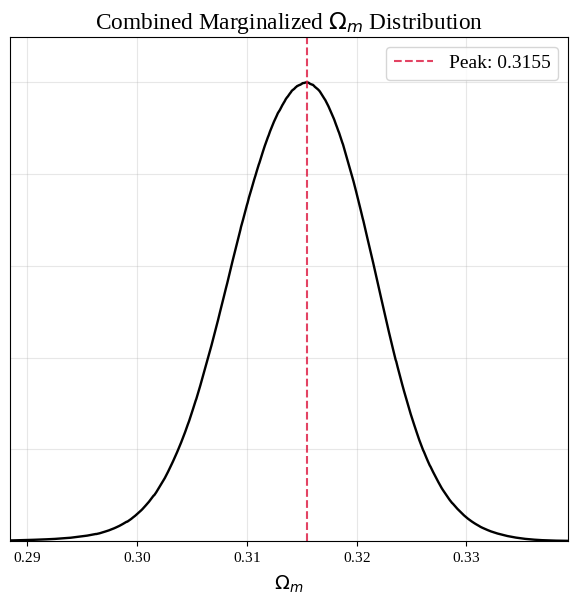

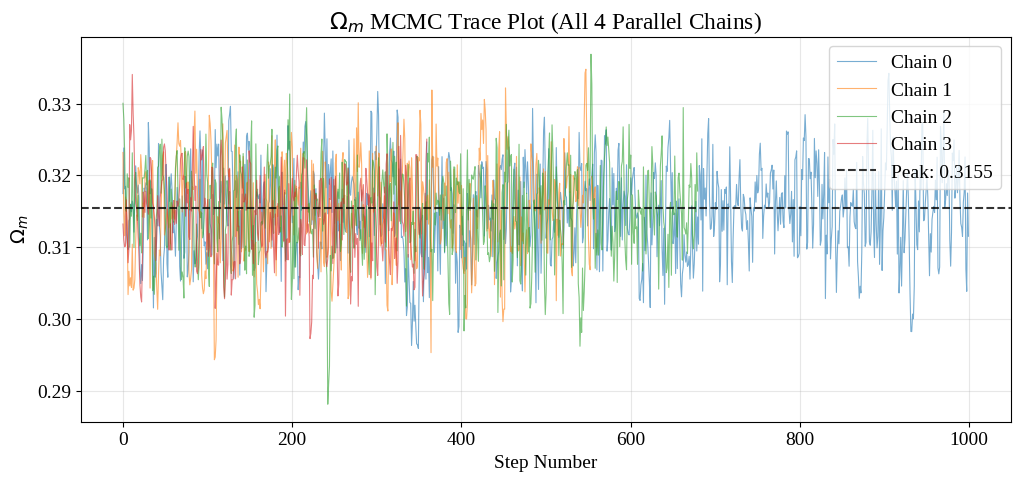

In [17]:
# plot results for emulated_flat_LCDM_bin1_omega_m_likelihood
print("Results for omega_m emulated flat LCDM bin1 MCMC:")
print("Runtime: 15 min 48 sec")
print("[mcmc] Reached maximum number of accepted steps allowed (1000). Stopping.")
print("")

chain_dir = os.path.expanduser('~/DESIxSO/chains/emulated_flat_LCDM_bin1_omega_m_likelihood')

all_samples = []
all_weights = []
all_loglikes = []

# loop through 4 raw task text files explicitly
for i in range(4):
    chain_path = os.path.join(chain_dir, f'chain_task_{i}.txt')
    if os.path.exists(chain_path):
        data = np.loadtxt(chain_path)
        
        # Apply your 20% burn-in manually to each individual chain
        burn = int(0.2 * len(data))
        
        all_weights.append(data[burn:, 0])
        all_loglikes.append(data[burn:, 1])
        all_samples.append(data[burn:, 2]) # Index 2 tracks Omega_m

# combine and create the MCSamples object
samples = MCSamples(
    samples=np.concatenate(all_samples),
    weights=np.concatenate(all_weights),
    loglikes=np.concatenate(all_loglikes),
    names=['Omega_m'],
    labels=[r'\Omega_m'],
    settings={'ignore_rows': 0.0}
)

# get the 1D density estimator for Omega_m and find its peak location
density1D = samples.get1DDensity('Omega_m')
omega_m_peak = density1D.x[np.argmax(density1D.P)]

print(f"The peak of the Omega_m distribution is at: {omega_m_peak:.4f}")

# combined Marginalized Distribution Plot with Peak Line
g1 = plots.get_subplot_plotter(width_inch=6)
g1.plot_1d(samples, 'Omega_m', LineWidth=2, color='darkblue')
plt.axvline(x=omega_m_peak, color='crimson', linestyle='--', alpha=0.8, label=f'Peak: {omega_m_peak:.4f}')
plt.title(r'Combined Marginalized $\Omega_m$ Distribution')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
g1.export('plots/MCMC_runs/traces_and_dists/emulated_flat_LCDM_bin1_omega_m_triangle_plot_(incomplete).pdf')
plt.show()

# plot traces
plt.figure(figsize=(12, 5))
for i in range(4):
    chain_path = os.path.join(chain_dir, f'chain_task_{i}.txt')
    if os.path.exists(chain_path):
        chain_data = np.loadtxt(chain_path)
        plt.plot(chain_data[:, 2], alpha=0.6, linewidth=0.8, label=f'Chain {i}')
plt.axhline(y=omega_m_peak, color='black', linestyle='--', alpha=0.8, label=f'Peak: {omega_m_peak:.4f}')
plt.xlabel('Step Number')
plt.ylabel(r'$\Omega_m$')
plt.title(r'$\Omega_m$ MCMC Trace Plot (All 4 Parallel Chains)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.savefig('plots/MCMC_runs/traces_and_dists/emulated_flat_LCDM_bin1_omega_m_traces_(incomplete).png', dpi=300, bbox_inches='tight')
plt.show()

Results for 1-bin emulated lensing ratios flat_LCDM MCMC sampling over omega_m and A_s:
[mcmc] The run has converged!
[mcmc] Sampling complete after 1920 accepted steps.
Runtime: 23 min 52 sec

The peak of the Omega_m distribution is at: 0.3120
The peak of the A_s distribution is at: 1.7863e-09


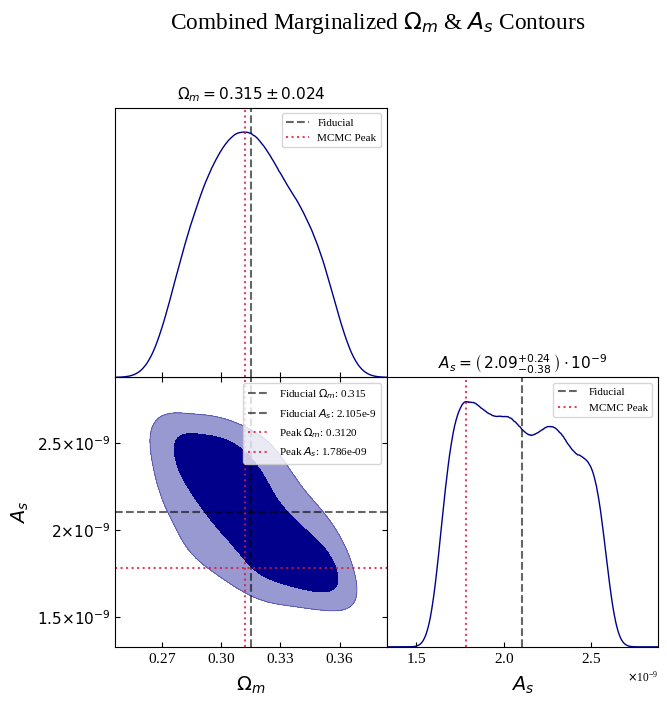

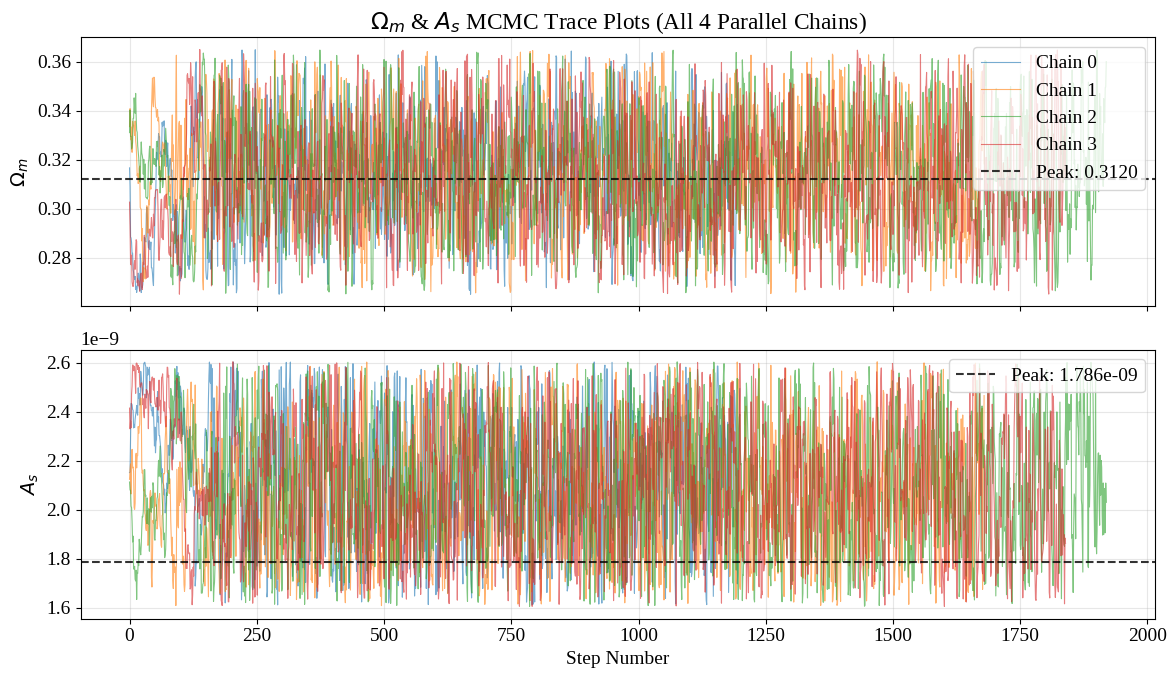

In [18]:
# plot results for emulated_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_likelihood
print("Results for 1-bin emulated lensing ratios flat_LCDM MCMC sampling over omega_m and A_s:")
print("[mcmc] The run has converged!")
print("[mcmc] Sampling complete after 1920 accepted steps.")
print("Runtime: 23 min 52 sec")
print("")
print("There's a slight preference for lower A_s."
print("-- I wonder if this is a high-l non-linearity effect, or if it has to do with the ratios not being perfectly agnostic.")
print("It's a pretty similar graph to the one we got pre-reordering with n_ell = 3000 instead of 5000.")
print("In the previous graph, there was still a preference for lower A_s, but there was a peak around the fiducial value, probably because all the chains started there.")
print("")
      
chain_dir = os.path.expanduser('~/DESIxSO/chains/emulated_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_likelihood')
all_weights = []
all_loglikes = []
all_omega_m = []
all_A_s = []

# loop through the 4 raw MPI task text files explicitly
for i in range(4):
    chain_path = os.path.join(chain_dir, f'chain_task_{i}.txt')
    if os.path.exists(chain_path):
        data = np.loadtxt(chain_path)
        
        # apply your 20% burn-in manually to each individual chain
        burn = int(0.2 * len(data))
        
        all_weights.append(data[burn:, 0])
        all_loglikes.append(data[burn:, 1])
        all_omega_m.append(data[burn:, 2])  # Index 2 tracks Omega_m
        all_A_s.append(data[burn:, 3])      # Index 3 tracks A_s

# combine the separated tracks into an (N, 2) array for MCSamples
combined_samples = np.column_stack((
    np.concatenate(all_omega_m),
    np.concatenate(all_A_s)
))

# combine and create the 2D MCSamples object
samples = MCSamples(
    samples=combined_samples,
    weights=np.concatenate(all_weights),
    loglikes=np.concatenate(all_loglikes),
    names=['Omega_m', 'A_s'],
    labels=[r'\Omega_m', r'A_s'],
    settings={'ignore_rows': 0.0}
)

# find 1D peak positions for annotations
density1D_om = samples.get1DDensity('Omega_m')
omega_m_peak = density1D_om.x[np.argmax(density1D_om.P)]

density1D_as = samples.get1DDensity('A_s')
A_s_peak = density1D_as.x[np.argmax(density1D_as.P)]

print(f"The peak of the Omega_m distribution is at: {omega_m_peak:.4f}")
print(f"The peak of the A_s distribution is at: {A_s_peak:.4e}")

g1 = plots.get_subplot_plotter(width_inch=7)
g1.triangle_plot(
    [samples], 
    params=['Omega_m', 'A_s'], 
    filled=True, 
    contour_colors=['darkblue'],
    title_limit=1,
)
                
# Add crosshairs for the true fiducial values and the MCMC peaks
if len(g1.subplots) > 1:
    if g1.subplots[0, 0] is not None:
        g1.subplots[0, 0].axvline(x=0.315, color='black', linestyle='--', alpha=0.6, label='Fiducial')
        g1.subplots[0, 0].axvline(x=omega_m_peak, color='crimson', linestyle=':', alpha=0.8, label='MCMC Peak')
        g1.subplots[0, 0].legend(loc='upper right', fontsize=8)
    if g1.subplots[1, 0] is not None:
        # True Fiducial Crosshairs (Dashed Black Bullseye)
        g1.subplots[1, 0].axvline(x=0.315, color='black', linestyle='--', alpha=0.6, label='Fiducial $\Omega_m$: 0.315')
        g1.subplots[1, 0].axhline(y=2.105e-9, color='black', linestyle='--', alpha=0.6, label='Fiducial $A_s$: 2.105e-9')        
        # MCMC Peak Crosshairs (Dotted Crimson)
        g1.subplots[1, 0].axvline(x=omega_m_peak, color='crimson', linestyle=':', alpha=0.8, label=f'Peak $\Omega_m$: {omega_m_peak:.4f}')
        g1.subplots[1, 0].axhline(y=A_s_peak, color='crimson', linestyle=':', alpha=0.8, label=f'Peak $A_s$: {A_s_peak:.3e}')
        g1.subplots[1, 0].legend(loc='upper right', fontsize=8)
    if g1.subplots[1, 1] is not None:
        g1.subplots[1, 1].axvline(x=2.105e-9, color='black', linestyle='--', alpha=0.6, label='Fiducial')
        g1.subplots[1, 1].axvline(x=A_s_peak, color='crimson', linestyle=':', alpha=0.8, label='MCMC Peak')
        g1.subplots[1, 1].legend(loc='upper right', fontsize=8)
        
g1.export('plots/MCMC_runs/traces_and_dists/emulated_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_triangle_plot.pdf')
plt.suptitle(r'Combined Marginalized $\Omega_m$ & $A_s$ Contours', y=1.02)
plt.show()

# traces
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for i in range(4):
    chain_path = os.path.join(chain_dir, f'chain_task_{i}.txt')
    if os.path.exists(chain_path):
        chain_data = np.loadtxt(chain_path)
        
        # Panel 1: Omega_m trace
        axes[0].plot(chain_data[:, 2], alpha=0.6, linewidth=0.8, label=f'Chain {i}')
        # Panel 2: A_s trace
        axes[1].plot(chain_data[:, 3], alpha=0.6, linewidth=0.8)

# Add benchmark lines to traces
axes[0].axhline(y=omega_m_peak, color='black', linestyle='--', alpha=0.8, label=f'Peak: {omega_m_peak:.4f}')
axes[0].set_ylabel(r'$\Omega_m$')
axes[0].set_title(r'$\Omega_m$ & $A_s$ MCMC Trace Plots (All 4 Parallel Chains)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].axhline(y=A_s_peak, color='black', linestyle='--', alpha=0.8, label=f'Peak: {A_s_peak:.3e}')
axes[1].set_xlabel('Step Number')
axes[1].set_ylabel(r'$A_s$')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.savefig('plots/MCMC_runs/traces_and_dists/emulated_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_traces.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

Results for low-l (1500) 1-bin emulated lensing ratios flat_LCDM MCMC sampling over omega_m and A_s:
Runtime: 16 min 34 sec.
[mcmc] The run has converged!
[mcmc] Sampling complete after 2800 accepted steps.
There still seems a slight low-A_s bias. I also wonder if those peaks are just the starting points of the chains.

The peak of the Omega_m distribution is at: 0.3061
The peak of the A_s distribution is at: 1.9805e-09


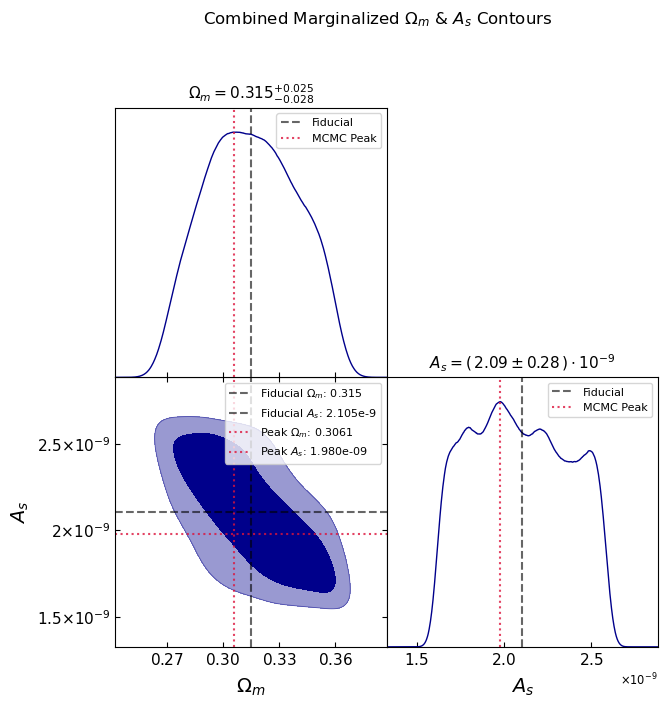

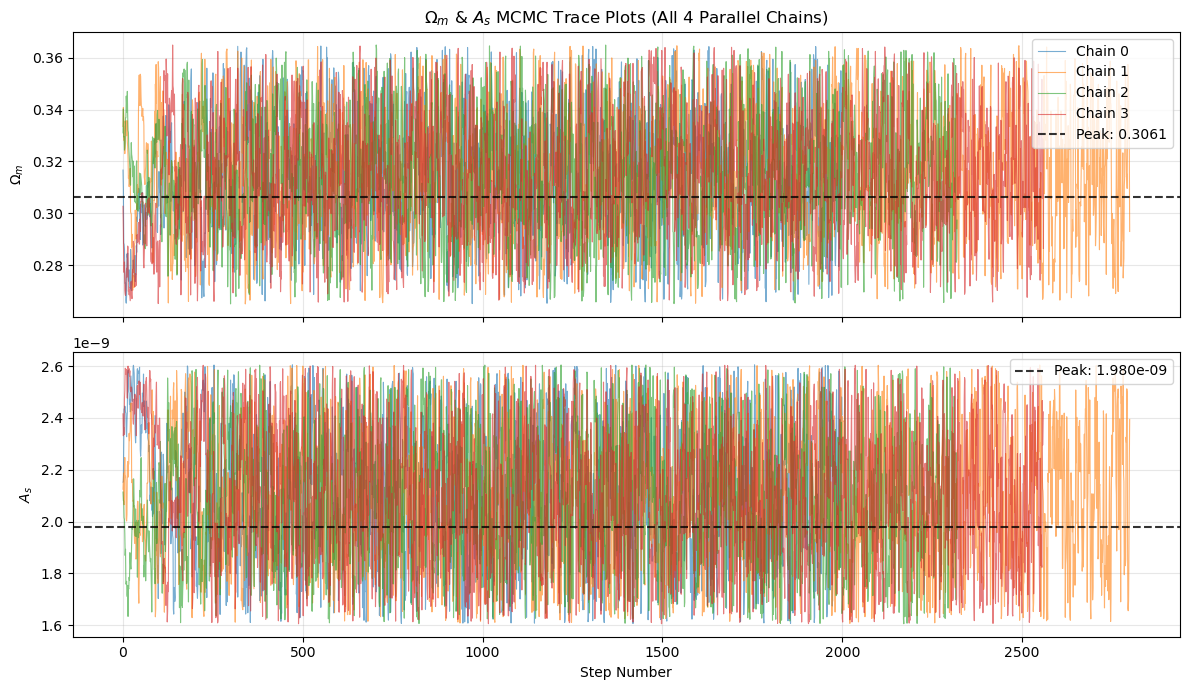

In [7]:
# plot results for emulated_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_likelihood
print("Results for low-l (1500) 1-bin emulated lensing ratios flat_LCDM MCMC sampling over omega_m and A_s:")
print("Runtime: 16 min 34 sec.")
print("[mcmc] The run has converged!")
print("[mcmc] Sampling complete after 2800 accepted steps.")
print("There still seems a slight low-A_s bias. I also wonder if those peaks are just the starting points of the chains.")
print("")

chain_dir = os.path.expanduser('~/DESIxSO/chains/emulated_low_l_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_likelihood')
all_weights = []
all_loglikes = []
all_omega_m = []
all_A_s = []

# loop through the 4 raw MPI task text files explicitly
for i in range(4):
    chain_path = os.path.join(chain_dir, f'chain_task_{i}.txt')
    if os.path.exists(chain_path):
        data = np.loadtxt(chain_path)
        
        # apply your 20% burn-in manually to each individual chain
        burn = int(0.2 * len(data))
        
        all_weights.append(data[burn:, 0])
        all_loglikes.append(data[burn:, 1])
        all_omega_m.append(data[burn:, 2])  # Index 2 tracks Omega_m
        all_A_s.append(data[burn:, 3])      # Index 3 tracks A_s

# combine the separated tracks into an (N, 2) array for MCSamples
combined_samples = np.column_stack((
    np.concatenate(all_omega_m),
    np.concatenate(all_A_s)
))

# combine and create the 2D MCSamples object
samples = MCSamples(
    samples=combined_samples,
    weights=np.concatenate(all_weights),
    loglikes=np.concatenate(all_loglikes),
    names=['Omega_m', 'A_s'],
    labels=[r'\Omega_m', r'A_s'],
    settings={'ignore_rows': 0.0}
)

# find 1D peak positions for annotations
density1D_om = samples.get1DDensity('Omega_m')
omega_m_peak = density1D_om.x[np.argmax(density1D_om.P)]

density1D_as = samples.get1DDensity('A_s')
A_s_peak = density1D_as.x[np.argmax(density1D_as.P)]

print(f"The peak of the Omega_m distribution is at: {omega_m_peak:.4f}")
print(f"The peak of the A_s distribution is at: {A_s_peak:.4e}")

g1 = plots.get_subplot_plotter(width_inch=7)
g1.triangle_plot(
    [samples], 
    params=['Omega_m', 'A_s'], 
    filled=True, 
    contour_colors=['darkblue'],
    title_limit=1,
)
                
# Add crosshairs for the true fiducial values and the MCMC peaks
if len(g1.subplots) > 1:
    if g1.subplots[0, 0] is not None:
        g1.subplots[0, 0].axvline(x=0.315, color='black', linestyle='--', alpha=0.6, label='Fiducial')
        g1.subplots[0, 0].axvline(x=omega_m_peak, color='crimson', linestyle=':', alpha=0.8, label='MCMC Peak')
        g1.subplots[0, 0].legend(loc='upper right', fontsize=8)
    if g1.subplots[1, 0] is not None:
        # True Fiducial Crosshairs (Dashed Black Bullseye)
        g1.subplots[1, 0].axvline(x=0.315, color='black', linestyle='--', alpha=0.6, label='Fiducial $\Omega_m$: 0.315')
        g1.subplots[1, 0].axhline(y=2.105e-9, color='black', linestyle='--', alpha=0.6, label='Fiducial $A_s$: 2.105e-9')        
        # MCMC Peak Crosshairs (Dotted Crimson)
        g1.subplots[1, 0].axvline(x=omega_m_peak, color='crimson', linestyle=':', alpha=0.8, label=f'Peak $\Omega_m$: {omega_m_peak:.4f}')
        g1.subplots[1, 0].axhline(y=A_s_peak, color='crimson', linestyle=':', alpha=0.8, label=f'Peak $A_s$: {A_s_peak:.3e}')
        g1.subplots[1, 0].legend(loc='upper right', fontsize=8)
    if g1.subplots[1, 1] is not None:
        g1.subplots[1, 1].axvline(x=2.105e-9, color='black', linestyle='--', alpha=0.6, label='Fiducial')
        g1.subplots[1, 1].axvline(x=A_s_peak, color='crimson', linestyle=':', alpha=0.8, label='MCMC Peak')
        g1.subplots[1, 1].legend(loc='upper right', fontsize=8)
        
g1.export('plots/MCMC_runs/traces_and_dists/emulated_low_l_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_triangle_plot.pdf')
plt.suptitle(r'Combined Marginalized $\Omega_m$ & $A_s$ Contours', y=1.02)
plt.show()

# traces
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for i in range(4):
    chain_path = os.path.join(chain_dir, f'chain_task_{i}.txt')
    if os.path.exists(chain_path):
        chain_data = np.loadtxt(chain_path)
        
        # Panel 1: Omega_m trace
        axes[0].plot(chain_data[:, 2], alpha=0.6, linewidth=0.8, label=f'Chain {i}')
        # Panel 2: A_s trace
        axes[1].plot(chain_data[:, 3], alpha=0.6, linewidth=0.8)

# Add benchmark lines to traces
axes[0].axhline(y=omega_m_peak, color='black', linestyle='--', alpha=0.8, label=f'Peak: {omega_m_peak:.4f}')
axes[0].set_ylabel(r'$\Omega_m$')
axes[0].set_title(r'$\Omega_m$ & $A_s$ MCMC Trace Plots (All 4 Parallel Chains)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].axhline(y=A_s_peak, color='black', linestyle='--', alpha=0.8, label=f'Peak: {A_s_peak:.3e}')
axes[1].set_xlabel('Step Number')
axes[1].set_ylabel(r'$A_s$')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.savefig('plots/MCMC_runs/traces_and_dists/emulated_low_l_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_traces.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

Results for 10 chain 1-bin emulated lensing ratios flat_LCDM MCMC sampling over omega_m and A_s:
Runtime: ~30 min -- cut off.
Ref was removed, so the A_s starting points were totally random within the uniform prior.

The peak of the Omega_m distribution is at: 0.3091
The peak of the A_s distribution is at: 1.9711e-09


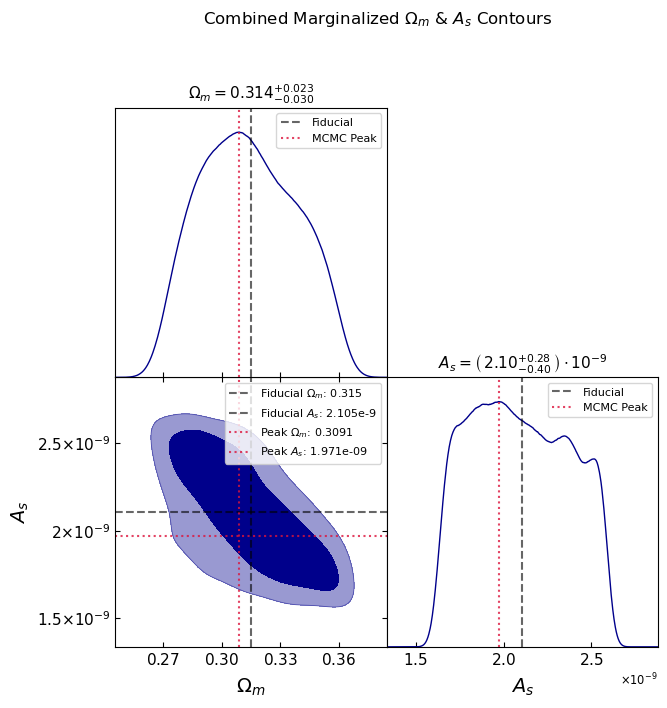

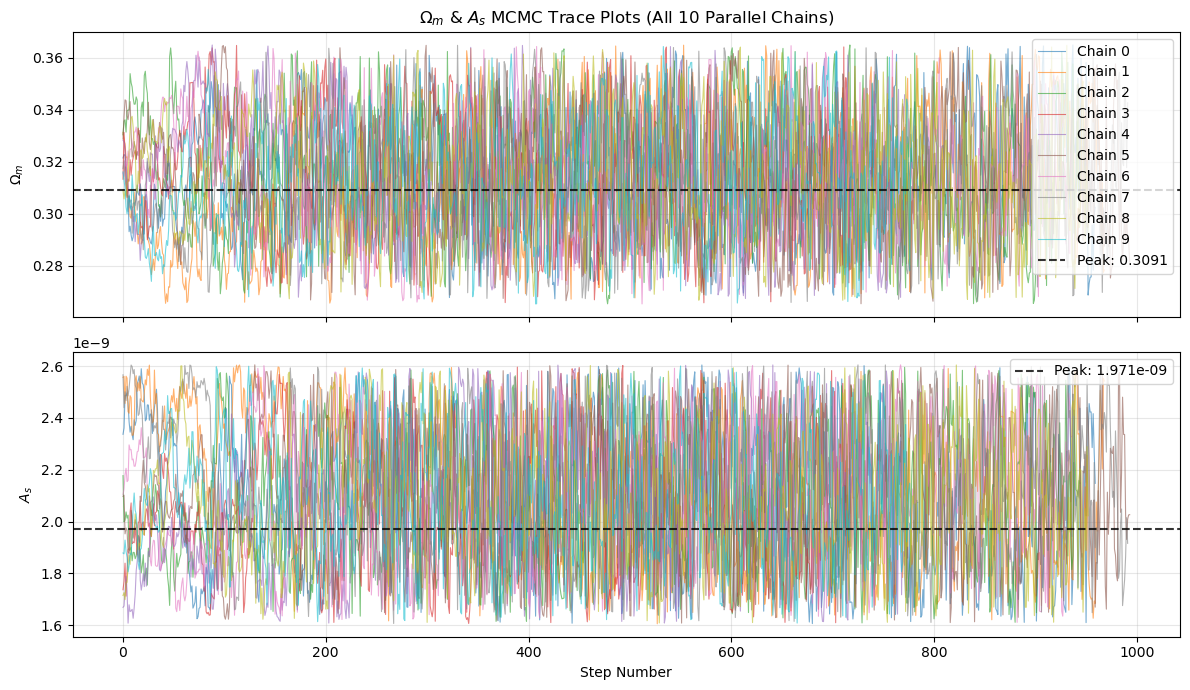

In [9]:
# plot results for 10 chain emulated_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_likelihood
print("Results for 10 chain 1-bin emulated lensing ratios flat_LCDM MCMC sampling over omega_m and A_s:")
print("Runtime: ~30 min -- cut off.")
print("Ref was removed, so the A_s starting points were totally random within the uniform prior.")
print("")

chain_dir = os.path.expanduser('~/DESIxSO/chains/emulated_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_10c_likelihood')
all_weights = []
all_loglikes = []
all_omega_m = []
all_A_s = []

# loop through the 10 raw MPI task text files explicitly
for i in range(10):
    chain_path = os.path.join(chain_dir, f'chain_task_{i}.txt')
    if os.path.exists(chain_path):
        data = np.loadtxt(chain_path)
        
        # apply your 20% burn-in manually to each individual chain
        burn = int(0.2 * len(data))
        
        all_weights.append(data[burn:, 0])
        all_loglikes.append(data[burn:, 1])
        all_omega_m.append(data[burn:, 2])  # Index 2 tracks Omega_m
        all_A_s.append(data[burn:, 3])      # Index 3 tracks A_s

# combine the separated tracks into an (N, 2) array for MCSamples
combined_samples = np.column_stack((
    np.concatenate(all_omega_m),
    np.concatenate(all_A_s)
))

# combine and create the 2D MCSamples object
samples = MCSamples(
    samples=combined_samples,
    weights=np.concatenate(all_weights),
    loglikes=np.concatenate(all_loglikes),
    names=['Omega_m', 'A_s'],
    labels=[r'\Omega_m', r'A_s'],
    settings={'ignore_rows': 0.0}
)

# find 1D peak positions for annotations
density1D_om = samples.get1DDensity('Omega_m')
omega_m_peak = density1D_om.x[np.argmax(density1D_om.P)]

density1D_as = samples.get1DDensity('A_s')
A_s_peak = density1D_as.x[np.argmax(density1D_as.P)]

print(f"The peak of the Omega_m distribution is at: {omega_m_peak:.4f}")
print(f"The peak of the A_s distribution is at: {A_s_peak:.4e}")

g1 = plots.get_subplot_plotter(width_inch=7)
g1.triangle_plot(
    [samples], 
    params=['Omega_m', 'A_s'], 
    filled=True, 
    contour_colors=['darkblue'],
    title_limit=1,
)
                
# Add crosshairs for the true fiducial values and the MCMC peaks
if len(g1.subplots) > 1:
    if g1.subplots[0, 0] is not None:
        g1.subplots[0, 0].axvline(x=0.315, color='black', linestyle='--', alpha=0.6, label='Fiducial')
        g1.subplots[0, 0].axvline(x=omega_m_peak, color='crimson', linestyle=':', alpha=0.8, label='MCMC Peak')
        g1.subplots[0, 0].legend(loc='upper right', fontsize=8)
    if g1.subplots[1, 0] is not None:
        # True Fiducial Crosshairs (Dashed Black Bullseye)
        g1.subplots[1, 0].axvline(x=0.315, color='black', linestyle='--', alpha=0.6, label='Fiducial $\Omega_m$: 0.315')
        g1.subplots[1, 0].axhline(y=2.105e-9, color='black', linestyle='--', alpha=0.6, label='Fiducial $A_s$: 2.105e-9')        
        # MCMC Peak Crosshairs (Dotted Crimson)
        g1.subplots[1, 0].axvline(x=omega_m_peak, color='crimson', linestyle=':', alpha=0.8, label=f'Peak $\Omega_m$: {omega_m_peak:.4f}')
        g1.subplots[1, 0].axhline(y=A_s_peak, color='crimson', linestyle=':', alpha=0.8, label=f'Peak $A_s$: {A_s_peak:.3e}')
        g1.subplots[1, 0].legend(loc='upper right', fontsize=8)
    if g1.subplots[1, 1] is not None:
        g1.subplots[1, 1].axvline(x=2.105e-9, color='black', linestyle='--', alpha=0.6, label='Fiducial')
        g1.subplots[1, 1].axvline(x=A_s_peak, color='crimson', linestyle=':', alpha=0.8, label='MCMC Peak')
        g1.subplots[1, 1].legend(loc='upper right', fontsize=8)
        
g1.export('plots/MCMC_runs/traces_and_dists/emulated_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_10c_triangle_plot_(incomplete).pdf')
plt.suptitle(r'Combined Marginalized $\Omega_m$ & $A_s$ Contours', y=1.02)
plt.show()

# traces
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for i in range(10):
    chain_path = os.path.join(chain_dir, f'chain_task_{i}.txt')
    if os.path.exists(chain_path):
        chain_data = np.loadtxt(chain_path)
        
        # Panel 1: Omega_m trace
        axes[0].plot(chain_data[:, 2], alpha=0.6, linewidth=0.8, label=f'Chain {i}')
        # Panel 2: A_s trace
        axes[1].plot(chain_data[:, 3], alpha=0.6, linewidth=0.8)

# Add benchmark lines to traces
axes[0].axhline(y=omega_m_peak, color='black', linestyle='--', alpha=0.8, label=f'Peak: {omega_m_peak:.4f}')
axes[0].set_ylabel(r'$\Omega_m$')
axes[0].set_title(r'$\Omega_m$ & $A_s$ MCMC Trace Plots (All 10 Parallel Chains)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].axhline(y=A_s_peak, color='black', linestyle='--', alpha=0.8, label=f'Peak: {A_s_peak:.3e}')
axes[1].set_xlabel('Step Number')
axes[1].set_ylabel(r'$A_s$')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.savefig('plots/MCMC_runs/traces_and_dists/emulated_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_10c_traces_(incomplete).png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

Results for 1-bin emulated MCMC sampling over omega_m and A_s:
Runtime: ~ 40 min
[mcmc] Learn + convergence test @ 2240 samples accepted.
[mcmc]  - Acceptance rate: 0.437
[mcmc]  - Convergence of means: R-1 = 0.015206 after 1792 accepted steps
[mcmc] Progress @ 2026-06-11 12:36:59 : 5008 steps taken, and 2241 accepted.
^Csrun: interrupt (one more within 1 sec to abort

The peak of the Omega_m distribution is at: 0.3079
The peak of the A_s distribution is at: 2.1160e-09


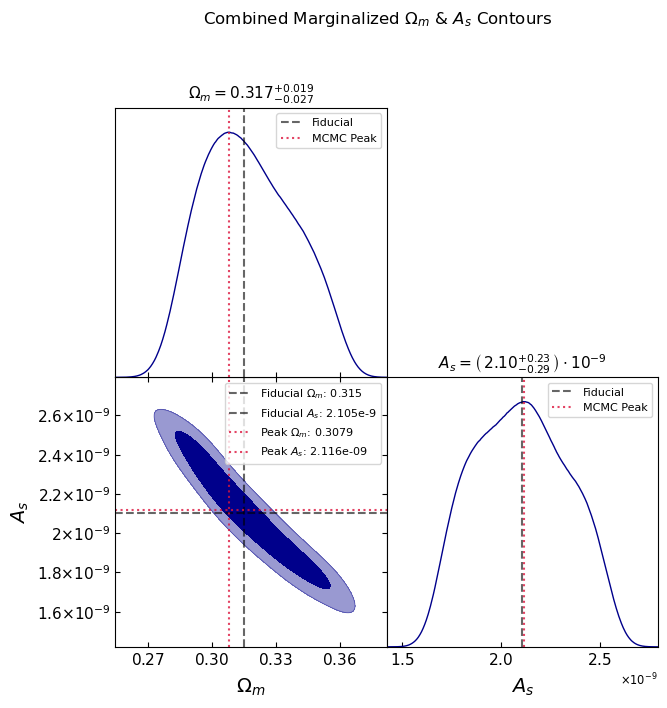

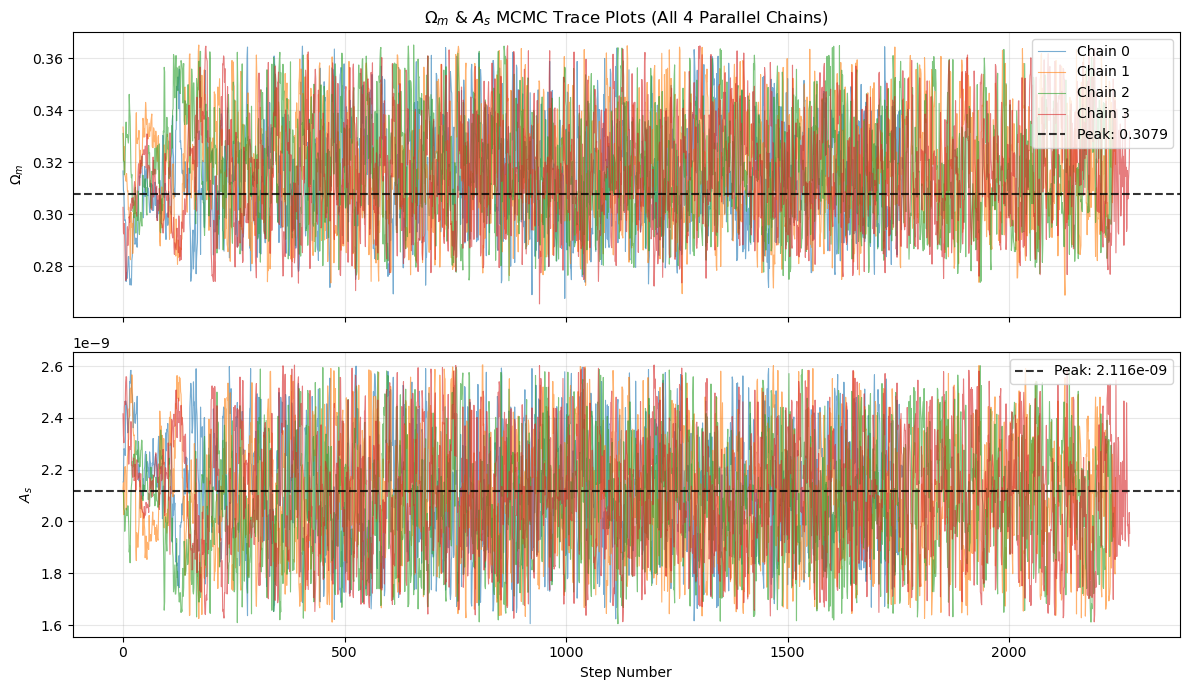

In [6]:
# plot results for emulated_flat_LCDM_bin1_omega_m_A_s_likelihood
print("Results for 1-bin emulated MCMC sampling over omega_m and A_s:")
print("Runtime: ~ 40 min")
print("[mcmc] Learn + convergence test @ 2240 samples accepted.")
print("[mcmc]  - Acceptance rate: 0.437")
print("[mcmc]  - Convergence of means: R-1 = 0.015206 after 1792 accepted steps")
print("[mcmc] Progress @ 2026-06-11 12:36:59 : 5008 steps taken, and 2241 accepted.")
print("^Csrun: interrupt (one more within 1 sec to abort")
print("")

chain_dir = os.path.expanduser('~/DESIxSO/chains/emulated_flat_LCDM_bin1_omega_m_A_s_likelihood')
all_weights = []
all_loglikes = []
all_omega_m = []
all_A_s = []

# loop through the 4 raw MPI task text files explicitly
for i in range(4):
    chain_path = os.path.join(chain_dir, f'chain_task_{i}.txt')
    if os.path.exists(chain_path):
        data = np.loadtxt(chain_path)
        
        # apply your 20% burn-in manually to each individual chain
        burn = int(0.2 * len(data))
        
        all_weights.append(data[burn:, 0])
        all_loglikes.append(data[burn:, 1])
        all_omega_m.append(data[burn:, 2])  # Index 2 tracks Omega_m
        all_A_s.append(data[burn:, 3])      # Index 3 tracks A_s

# combine the separated tracks into an (N, 2) array for MCSamples
combined_samples = np.column_stack((
    np.concatenate(all_omega_m),
    np.concatenate(all_A_s)
))

# combine and create the 2D MCSamples object
samples = MCSamples(
    samples=combined_samples,
    weights=np.concatenate(all_weights),
    loglikes=np.concatenate(all_loglikes),
    names=['Omega_m', 'A_s'],
    labels=[r'\Omega_m', r'A_s'],
    settings={'ignore_rows': 0.0}
)

# find 1D peak positions for annotations
density1D_om = samples.get1DDensity('Omega_m')
omega_m_peak = density1D_om.x[np.argmax(density1D_om.P)]

density1D_as = samples.get1DDensity('A_s')
A_s_peak = density1D_as.x[np.argmax(density1D_as.P)]

print(f"The peak of the Omega_m distribution is at: {omega_m_peak:.4f}")
print(f"The peak of the A_s distribution is at: {A_s_peak:.4e}")

g1 = plots.get_subplot_plotter(width_inch=7)
g1.triangle_plot(
    [samples], 
    params=['Omega_m', 'A_s'], 
    filled=True, 
    contour_colors=['darkblue'],
    title_limit=1,
)
                
# Add crosshairs for the true fiducial values and the MCMC peaks
if len(g1.subplots) > 1:
    if g1.subplots[0, 0] is not None:
        g1.subplots[0, 0].axvline(x=0.315, color='black', linestyle='--', alpha=0.6, label='Fiducial')
        g1.subplots[0, 0].axvline(x=omega_m_peak, color='crimson', linestyle=':', alpha=0.8, label='MCMC Peak')
        g1.subplots[0, 0].legend(loc='upper right', fontsize=8)
    if g1.subplots[1, 0] is not None:
        # True Fiducial Crosshairs (Dashed Black Bullseye)
        g1.subplots[1, 0].axvline(x=0.315, color='black', linestyle='--', alpha=0.6, label='Fiducial $\Omega_m$: 0.315')
        g1.subplots[1, 0].axhline(y=2.105e-9, color='black', linestyle='--', alpha=0.6, label='Fiducial $A_s$: 2.105e-9')        
        # MCMC Peak Crosshairs (Dotted Crimson)
        g1.subplots[1, 0].axvline(x=omega_m_peak, color='crimson', linestyle=':', alpha=0.8, label=f'Peak $\Omega_m$: {omega_m_peak:.4f}')
        g1.subplots[1, 0].axhline(y=A_s_peak, color='crimson', linestyle=':', alpha=0.8, label=f'Peak $A_s$: {A_s_peak:.3e}')
        g1.subplots[1, 0].legend(loc='upper right', fontsize=8)
    if g1.subplots[1, 1] is not None:
        g1.subplots[1, 1].axvline(x=2.105e-9, color='black', linestyle='--', alpha=0.6, label='Fiducial')
        g1.subplots[1, 1].axvline(x=A_s_peak, color='crimson', linestyle=':', alpha=0.8, label='MCMC Peak')
        g1.subplots[1, 1].legend(loc='upper right', fontsize=8)
        
g1.export('plots/MCMC_runs/traces_and_dists/emulated_flat_LCDM_bin1_omega_m_A_s_triangle_plot_(incomplete).pdf')
plt.suptitle(r'Combined Marginalized $\Omega_m$ & $A_s$ Contours', y=1.02)
plt.show()

# traces
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for i in range(4):
    chain_path = os.path.join(chain_dir, f'chain_task_{i}.txt')
    if os.path.exists(chain_path):
        chain_data = np.loadtxt(chain_path)
        
        # Panel 1: Omega_m trace
        axes[0].plot(chain_data[:, 2], alpha=0.6, linewidth=0.8, label=f'Chain {i}')
        # Panel 2: A_s trace
        axes[1].plot(chain_data[:, 3], alpha=0.6, linewidth=0.8)

# Add benchmark lines to traces
axes[0].axhline(y=omega_m_peak, color='black', linestyle='--', alpha=0.8, label=f'Peak: {omega_m_peak:.4f}')
axes[0].set_ylabel(r'$\Omega_m$')
axes[0].set_title(r'$\Omega_m$ & $A_s$ MCMC Trace Plots (All 4 Parallel Chains)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].axhline(y=A_s_peak, color='black', linestyle='--', alpha=0.8, label=f'Peak: {A_s_peak:.3e}')
axes[1].set_xlabel('Step Number')
axes[1].set_ylabel(r'$A_s$')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.savefig('plots/MCMC_runs/traces_and_dists/emulated_flat_LCDM_bin1_omega_m_A_s_traces_(incomplete).png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

### DESI DRII - DESIxSO waw0 Comparison

In [ ]:
# first run -- incomplete, runtime ~ 110 min

[mcmc] Learn + convergence test @ 1200 samples accepted.
[mcmc]  - Acceptance rate: 0.432
[mcmc]  - Convergence of means: R-1 = 0.169616 after 960 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Progress @ 2026-06-11 18:29:30 : 2875 steps taken, and 1371 accepted.
[mcmc] Progress @ 2026-06-11 18:30:00 : 2795 steps taken, and 1368 accepted.
[mcmc] Progress @ 2026-06-11 18:30:17 : 2875 steps taken, and 1393 accepted.
[mcmc] Progress @ 2026-06-11 18:30:23 : 2587 steps taken, and 1210 accepted.
[mcmc] Progress @ 2026-06-11 18:30:31 : 2905 steps taken, and 1385 accepted.
[mcmc] Progress @ 2026-06-11 18:31:00 : 2841 steps taken, and 1383 accepted.
[mcmc] Progress @ 2026-06-11 18:31:18 : 2912 steps taken, and 1408 accepted.
[mcmc] Progress @ 2026-06-11 18:31:25 : 2616 steps taken, and 1226 accepted.
[mcmc] Progress @ 2026-06-11 18:31:33 : 2937 steps taken, and 1401 accepted.
[mcmc] Progress @ 2026-06-11 18:32:01 : 2871 steps taken, and 1396 accepted.
[mcmc] Progress @ 2026-06-11 18:32:18 : 2951 steps taken, and 1422 accepted.
[mcmc] Progress @ 2026-06-11 18:32:26 : 2655 steps taken, and 1240 accepted.
[mcmc] Progress @ 2026-06-11 18:32:34 : 2964 steps taken, and 1420 accepted.
[mcmc] Progress @ 2026-06-11 18:33:03 : 2901 steps taken, and 1408 accepted.
[mcmc] Progress @ 2026-06-11 18:33:18 : 2988 steps taken, and 1436 accepted.
[mcmc] Progress @ 2026-06-11 18:33:27 : 2691 steps taken, and 1257 accepted.
[mcmc] Progress @ 2026-06-11 18:33:36 : 3001 steps taken, and 1436 accepted.
[mcmc] Learn + convergence test @ 1440 samples accepted.
[mcmc]  - Acceptance rate: 0.441
[mcmc]  - Convergence of means: R-1 = 0.062485 after 1152 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Learn + convergence test @ 1440 samples accepted.
[mcmc]  - Acceptance rate: 0.445
[mcmc]  - Convergence of means: R-1 = 0.068776 after 1152 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Progress @ 2026-06-11 18:34:03 : 2937 steps taken, and 1423 accepted.
[mcmc] Progress @ 2026-06-11 18:34:18 : 3018 steps taken, and 1450 accepted.
[mcmc] Progress @ 2026-06-11 18:34:28 : 2721 steps taken, and 1268 accepted.
[mcmc] Progress @ 2026-06-11 18:34:38 : 3032 steps taken, and 1454 accepted.
[mcmc] Progress @ 2026-06-11 18:35:04 : 2977 steps taken, and 1436 accepted.
[mcmc] Progress @ 2026-06-11 18:35:18 : 3045 steps taken, and 1465 accepted.
[mcmc] Learn + convergence test @ 1440 samples accepted.
[mcmc]  - Acceptance rate: 0.449
[mcmc]  - Convergence of means: R-1 = 0.115005 after 1152 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Progress @ 2026-06-11 18:35:30 : 2761 steps taken, and 1278 accepted.
[mcmc] Progress @ 2026-06-11 18:35:40 : 3058 steps taken, and 1470 accepted.
[mcmc] Progress @ 2026-06-11 18:36:04 : 3020 steps taken, and 1446 accepted.
[mcmc] Progress @ 2026-06-11 18:36:19 : 3072 steps taken, and 1477 accepted.
[mcmc] Progress @ 2026-06-11 18:36:31 : 2788 steps taken, and 1290 accepted.
[mcmc] Progress @ 2026-06-11 18:36:42 : 3090 steps taken, and 1486 accepted.
[mcmc] Progress @ 2026-06-11 18:37:05 : 3058 steps taken, and 1459 accepted.
[mcmc] Progress @ 2026-06-11 18:37:19 : 3108 steps taken, and 1492 accepted.
[mcmc] Progress @ 2026-06-11 18:37:33 : 2822 steps taken, and 1305 accepted.
[mcmc] Progress @ 2026-06-11 18:37:44 : 3126 steps taken, and 1501 accepted.
[mcmc] Progress @ 2026-06-11 18:38:06 : 3094 steps taken, and 1476 accepted.
[mcmc] Progress @ 2026-06-11 18:38:19 : 3141 steps taken, and 1505 accepted.
[mcmc] Progress @ 2026-06-11 18:38:34 : 2857 steps taken, and 1318 accepted.
[mcmc] Learn + convergence test @ 1320 samples accepted.
[mcmc]  - Acceptance rate: 0.424
[mcmc]  - Convergence of means: R-1 = 0.116927 after 1056 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Progress @ 2026-06-11 18:38:46 : 3155 steps taken, and 1513 accepted.
^Csrun: interrupt (one more within 1 sec to abort)
srun: StepId=54324822.0 tasks 0-3: running
^Csrun: sending Ctrl-C to StepId=54324822.0
srun: forcing job termination
^Csrun: sending Ctrl-C to StepId=54324822.0
^C^C^Csrun: Job step aborted: Waiting up to 32 seconds for job step to finish.
srun: job abort in progress
srun: sending Ctrl-C to StepId=54324822.0
[2026-06-12T01:38:51.933] error: *** STEP 54324822.0 ON nid004209 CANCELLED AT 2026-06-12T01:38:51 DUE to SIGNAL Killed ***
^C^Csrun: sending Ctrl-C to StepId=54324822.0
srun: Terminating StepId=54324822.0
srun: job abort in progress
^Csrun: sending Ctrl-C to StepId=54324822.0
^Csrun: sending Ctrl-C to StepId=54324822.0
^Csrun: sending Ctrl-C to StepId=54324822.0

real    105m29.542s
user    0m0.058s
sys     0m0.078s
(cosmo311) lialubit@nid004209:~/DESIxSO> 

Results for source bin1 all lens bins emulated lensing ratios waw0 MCMC sampling over omega_m, wa, and w0:
Runtime: XX min XX sec.
INCOMPLETE

The peak of the Omega_m distribution is at: 0.3158
The peak of the wa distribution is at:      -1.5796
The peak of the w0 distribution is at:      -0.2999


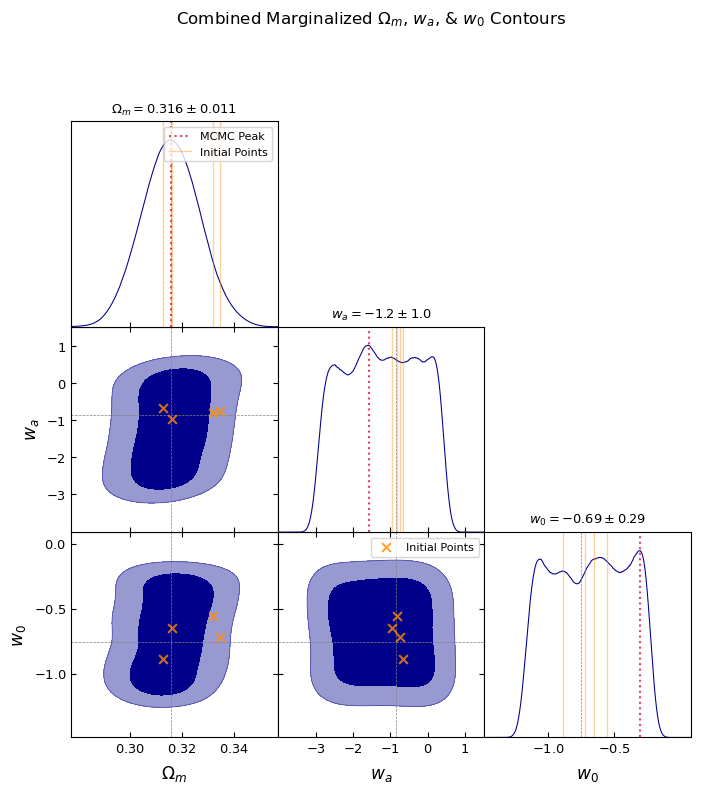

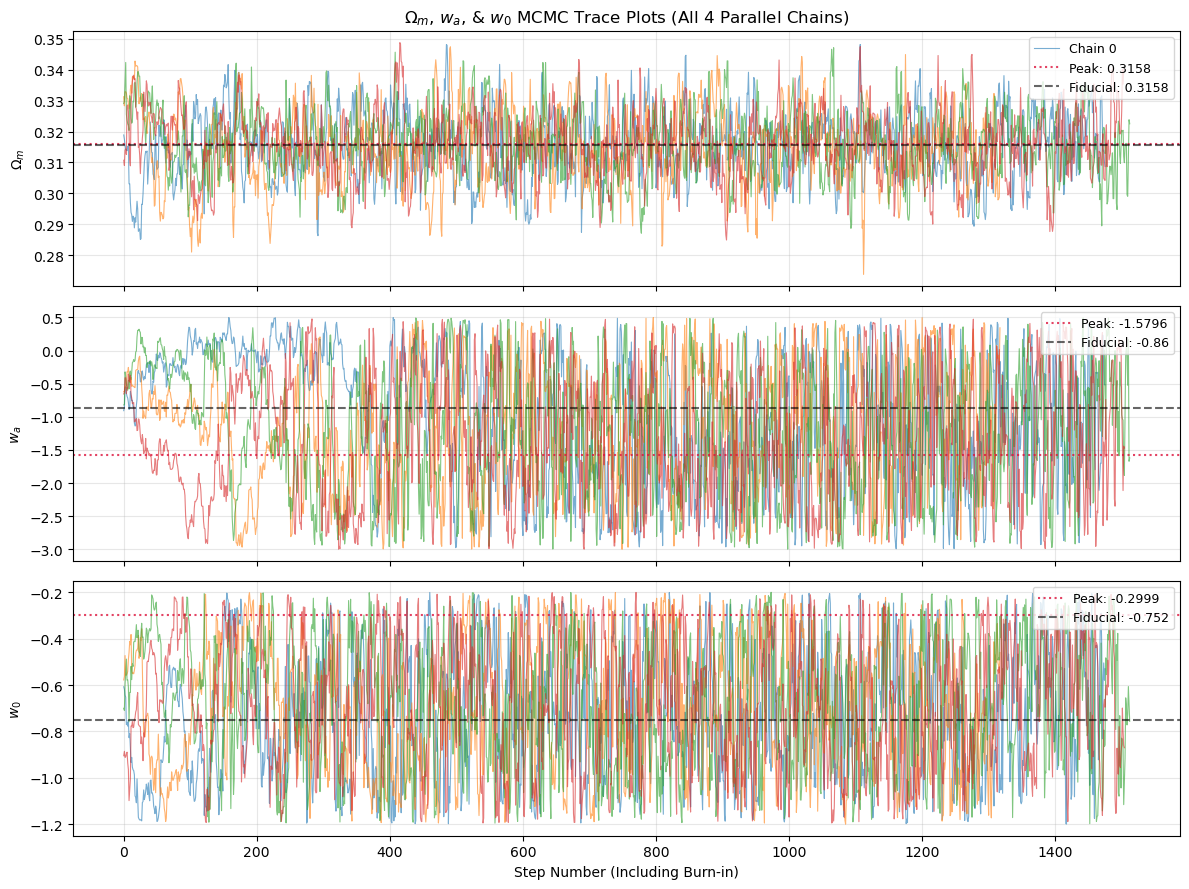

In [4]:
# plot results for emulated_lensing_ratios_waw0_source_bin1_all_lens_bins_wa_w0_omega_m_likelihood
print("Results for source bin1 all lens bins emulated lensing ratios waw0 MCMC sampling over omega_m, wa, and w0:")
print("Runtime: XX min XX sec.")
print("INCOMPLETE")
print("")

chain_dir = os.path.expanduser('~/DESIxSO/chains/emulated_lensing_ratios_waw0_source_bin1_all_lens_bins_wa_w0_omega_m_likelihood_incomplete')
all_weights = []
all_loglikes = []
all_omega_m = []
all_wa = []
all_w0 = []

# Fiducial values requested
fiducial_vals = {'Omega_m': 0.3158, 'wa': -0.86, 'w0': -0.752}

# loop through the 4 raw MPI task text files explicitly
for i in range(4):
    chain_path = os.path.join(chain_dir, f'chain_task_{i}.txt')
    if os.path.exists(chain_path):
        data = np.loadtxt(chain_path)
        
        # apply your 20% burn-in manually to each individual chain
        burn = int(0.2 * len(data))
        
        all_weights.append(data[burn:, 0])
        all_loglikes.append(data[burn:, 1])
        all_omega_m.append(data[burn:, 2])  # Index 2 tracks Omega_m
        all_wa.append(data[burn:, 3])       # Index 3 tracks wa
        all_w0.append(data[burn:, 4])       # Index 4 tracks w0

# combine the separated tracks into an (N, 3) array for MCSamples
combined_samples = np.column_stack((
    np.concatenate(all_omega_m),
    np.concatenate(all_wa),
    np.concatenate(all_w0)
))

# combine and create the 3D MCSamples object
samples = MCSamples(
    samples=combined_samples,
    weights=np.concatenate(all_weights),
    loglikes=np.concatenate(all_loglikes),
    names=['Omega_m', 'wa', 'w0'],
    labels=[r'\Omega_m', r'w_a', r'w_0'],
    settings={'ignore_rows': 0.0}
)

# find 1D peak positions for annotations
peaks = {}
for param in ['Omega_m', 'wa', 'w0']:
    density1D = samples.get1DDensity(param)
    peaks[param] = density1D.x[np.argmax(density1D.P)]

print(f"The peak of the Omega_m distribution is at: {peaks['Omega_m']:.4f}")
print(f"The peak of the wa distribution is at:      {peaks['wa']:.4f}")
print(f"The peak of the w0 distribution is at:      {peaks['w0']:.4f}")

# --- TRIANGLE CONTOUR PLOT ---

# Define your 4 initial MPI task starting points
initial_points = [
    {'Omega_m': 0.3346741, 'wa': -0.7495742, 'w0': -0.7179913},
    {'Omega_m': 0.3321019, 'wa': -0.8142583, 'w0': -0.5527484},
    {'Omega_m': 0.3126217, 'wa': -0.6630192, 'w0': -0.8847971},
    {'Omega_m': 0.3161738, 'wa': -0.9667531, 'w0': -0.6477198}
]

g1 = plots.get_subplot_plotter(width_inch=8)
g1.triangle_plot(
    [samples], 
    params=['Omega_m', 'wa', 'w0'], 
    filled=True, 
    contour_colors=['darkblue'],
    title_limit=1,
    markers=fiducial_vals # Dashed black crosshairs for truth
)

# Overlay the MCMC Peak lines AND the initial points onto the GetDist grid
for param_idx, param in enumerate(['Omega_m', 'wa', 'w0']):
    # 1D Diagonal Plots: Add vertical markers for the starting points
    ax_diag = g1.subplots[param_idx, param_idx]
    if ax_diag is not None:
        ax_diag.axvline(x=peaks[param], color='crimson', linestyle=':', alpha=0.8, label='MCMC Peak')
        
        # Add a light line for each chain's initial guess
        for idx, pt in enumerate(initial_points):
            ax_diag.axvline(x=pt[param], color='darkorange', linestyle='-', alpha=0.4, 
                            linewidth=1, label='Initial Points' if (param_idx == 0 and idx == 0) else "")
            
        if param_idx == 0:  
            ax_diag.legend(loc='upper right', fontsize=8)

# 2D Lower Triangle Plots: Scatter the exact initial coordinates
# GetDist layout maps row and column indexing systematically
# Row 1, Col 0 -> (wa vs Omega_m)
if g1.subplots[1, 0] is not None:
    ax = g1.subplots[1, 0]
    for pt in initial_points:
        ax.scatter(pt['Omega_m'], pt['wa'], color='darkorange', marker='x', s=40, zorder=5, alpha=0.8)

# Row 2, Col 0 -> (w0 vs Omega_m)
if g1.subplots[2, 0] is not None:
    ax = g1.subplots[2, 0]
    for pt in initial_points:
        ax.scatter(pt['Omega_m'], pt['w0'], color='darkorange', marker='x', s=40, zorder=5, alpha=0.8)

# Row 2, Col 1 -> (w0 vs wa)
if g1.subplots[2, 1] is not None:
    ax = g1.subplots[2, 1]
    for idx, pt in enumerate(initial_points):
        # Add a label to just one scatter element so it cleans up the legend formatting
        lbl = 'Initial Points' if idx == 0 else ""
        ax.scatter(pt['wa'], pt['w0'], color='darkorange', marker='x', s=40, zorder=5, alpha=0.8, label=lbl)
    ax.legend(loc='upper right', fontsize=8)

g1.export('plots/MCMC_runs/traces_and_dists/emulated_lensing_ratios_waw0_source_bin1_all_lens_bins_wa_w0_omega_m_triangle_plot_(incomplete).pdf')
plt.suptitle(r'Combined Marginalized $\Omega_m$, $w_a$, & $w_0$ Contours', y=1.02)
plt.show()

# --- TRACE PLOTS ---
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for i in range(4):
    chain_path = os.path.join(chain_dir, f'chain_task_{i}.txt')
    if os.path.exists(chain_path):
        chain_data = np.loadtxt(chain_path)
        
        # Panel 1: Omega_m trace
        axes[0].plot(chain_data[:, 2], alpha=0.6, linewidth=0.8, label=f'Chain {i}' if i==0 else "")
        # Panel 2: wa trace
        axes[1].plot(chain_data[:, 3], alpha=0.6, linewidth=0.8)
        # Panel 3: w0 trace
        axes[2].plot(chain_data[:, 4], alpha=0.6, linewidth=0.8)

# Add benchmarks and labels to traces
axes[0].axhline(y=peaks['Omega_m'], color='crimson', linestyle=':', alpha=0.8, label=f'Peak: {peaks["Omega_m"]:.4f}')
axes[0].axhline(y=fiducial_vals['Omega_m'], color='black', linestyle='--', alpha=0.6, label=f'Fiducial: {fiducial_vals["Omega_m"]}')
axes[0].set_ylabel(r'$\Omega_m$')
axes[0].set_title(r'$\Omega_m$, $w_a$, & $w_0$ MCMC Trace Plots (All 4 Parallel Chains)')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].axhline(y=peaks['wa'], color='crimson', linestyle=':', alpha=0.8, label=f'Peak: {peaks["wa"]:.4f}')
axes[1].axhline(y=fiducial_vals['wa'], color='black', linestyle='--', alpha=0.6, label=f'Fiducial: {fiducial_vals["wa"]}')
axes[1].set_ylabel(r'$w_a$')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(True, alpha=0.3)

axes[2].axhline(y=peaks['w0'], color='crimson', linestyle=':', alpha=0.8, label=f'Peak: {peaks["w0"]:.4f}')
axes[2].axhline(y=fiducial_vals['w0'], color='black', linestyle='--', alpha=0.6, label=f'Fiducial: {fiducial_vals["w0"]}')
axes[2].set_xlabel('Step Number (Including Burn-in)')
axes[2].set_ylabel(r'$w_0$')
axes[2].legend(loc='upper right', fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.savefig('plots/MCMC_runs/traces_and_dists/emulated_lensing_ratios_waw0_source_bin1_all_lens_bins_wa_w0_omega_m_traces_(incomplete).png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

Loading DESI + CMB...
Loading DESI + CMB + DESY5...
Loading DESI + CMB + Pantheon+...
Loading DESI + CMB + Union3...


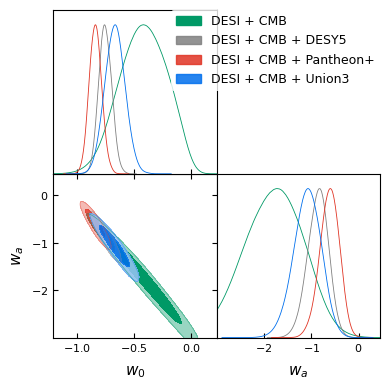

In [7]:
# plot DESI DRII contours

# The absolute NERSC path where the DESI chains live
DESI_DIR = "/global/cfs/cdirs/desi/public/papers/y3/bao-cosmo-params/cobaya/base_w_wa"

# Mapping the exact folder names from NERSC to readable legend labels
datasets = {
    "DESI + CMB": "desi-bao-all_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing",
    "DESI + CMB + DESY5": "desi-bao-all_desy5sn_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing",
    "DESI + CMB + Pantheon+": "desi-bao-all_pantheonplus_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing",
    "DESI + CMB + Union3": "desi-bao-all_union3_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing"
}

# Load the samples straight from CFS
samples = {}
for label, folder_name in datasets.items():
    # 'chain' is the root prefix for chain.1.txt, chain.2.txt, etc.
    chain_root = os.path.join(DESI_DIR, folder_name, "chain")
    
    print(f"Loading {label}...")
    samples[label] = loadMCSamples(chain_root, settings={'ignore_rows': 0.3})

# Initialize the plotter for a beautiful inline Jupyter notebook display
g = plots.get_subplot_plotter()

# Customize plot settings to mimic official papers
g.settings.num_plot_contours = 2  # 68% and 95% intervals
g.settings.figure_legend_frame = False

# Plot the 2D contour overlay for dark energy parameters w and wa
g.triangle_plot(
    list(samples.values()), 
    params=['w', 'wa'], 
    legend_labels=list(samples.keys()),
    filled=True
)

In [13]:
import os

# Your exact directory from the error message
target_dir = '/global/homes/l/lialubit/DESIxSO/chains/emulated_lensing_ratios_waw0_source_bin1_all_lens_bins_wa_w0_omega_m_likelihood_incomplete/'

# The parameter column mapping GetDist needs
param_content = """omega_m\t\\Omega_m
w0\tw_0
wa\tw_a
minuslogprior\tminuslogprior
minuslogprior__0\tminuslogprior__0
chi2\t\\chi^2
chi2__SO_x_DESI_Likelihood_w_emulator\t\\chi^2_{\\mathrm{model}}
"""

# Write it for both prefixes you have in that folder
with open(os.path.join(target_dir, "cosmo_run.paramnames"), "w") as f:
    f.write(param_content)

with open(os.path.join(target_dir, "chain_task.paramnames"), "w") as f:
    f.write(param_content)

print("Fix applied! You can now re-run your GetDist overlay cell.")

Fix applied! You can now re-run your GetDist overlay cell.


Loading DESI + CMB...
Loading DESI + CMB + DESY5...
Loading DESI + CMB + Pantheon+...
Loading DESI + CMB + Union3...
Loading custom lensing ratio chains...
Generating contour plot...


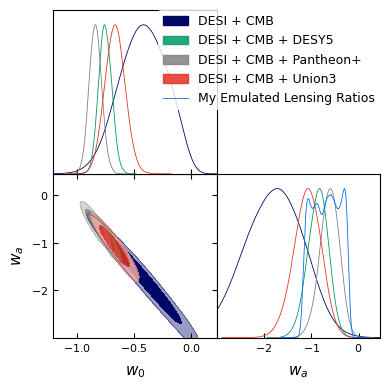

Cell processing finished. Custom parameter names successfully restored back to 'w0' in memory.


In [14]:
# plot DESI DRII contours on top of my contours

# ==========================================
# 1. DEFINE PATHS & LABELS
# ==========================================
# The absolute NERSC path where the public DESI Y3 chains live
DESI_DIR = "/global/cfs/cdirs/desi/public/papers/y3/bao-cosmo-params/cobaya/base_w_wa"

# Mapping the exact folder names from NERSC to your legend labels
datasets = {
    "DESI + CMB": "desi-bao-all_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing",
    "DESI + CMB + DESY5": "desi-bao-all_desy5sn_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing",
    "DESI + CMB + Pantheon+": "desi-bao-all_pantheonplus_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing",
    "DESI + CMB + Union3": "desi-bao-all_union3_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing"
}

# Path to your personal emulated lensing ratio chains
my_chain_dir = os.path.expanduser('~/DESIxSO/chains/emulated_lensing_ratios_waw0_source_bin1_all_lens_bins_wa_w0_omega_m_likelihood_incomplete')

# ==========================================
# 2. LOAD SAMPLES
# ==========================================
samples = {}

# Load official DESI chains (these use 'w' and 'wa' natively)
for label, folder_name in datasets.items():
    # Changed "chain_task" to "chain" to match the official DESI file naming
    chain_root = os.path.join(DESI_DIR, folder_name, "chain") 
    print(f"Loading {label}...")
    samples[label] = loadMCSamples(chain_root, settings={'ignore_rows': 0.3})
    
# Load your custom lensing chains
print("Loading custom lensing ratio chains...")
my_chain_root = os.path.join(my_chain_dir, "chain_task") 
my_samples = mcsamples.loadMCSamples(my_chain_root, settings={'ignore_rows': 0.3})

# ==========================================
# 3. TEMPORARY PARAMETER ALIGNMENT
# ==========================================
# Force the internal statistics to update, then map 'w0' -> 'w'
my_samples.updateBaseStatistics()
my_samples.paramNames.parWithName('w0').name = 'w'
my_samples.paramNames.parWithName('w').label = 'w_0'  # Keeps the LaTeX format pretty

# Inject your renamed sample into the plotting pool
samples["My Emulated Lensing Ratios"] = my_samples

# ==========================================
# 4. PLOT CONTUORS
# ==========================================
print("Generating contour plot...")
g = plots.get_subplot_plotter()
g.settings.num_plot_contours = 2           # 68% and 95% confidence levels
g.settings.figure_legend_frame = False     # Clean legend look

# Overlay the 2D contours for dark energy parameters
g.triangle_plot(
    list(samples.values()), 
    params=['w', 'wa'], 
    legend_labels=list(samples.keys()),
    filled=True
)

# Optional: Add a dashed line marker at the cosmological constant benchmark (w0=-1, wa=0)
# plt.axvline(-1.0, color='gray', linestyle='--', alpha=0.7)
# plt.axhline(0.0, color='gray', linestyle='--', alpha=0.7)

plt.show()

# ==========================================
# 5. RESTORE ORIGINAL STATE (CLEANUP)
# ==========================================
# Safely rename 'w' back to 'w0' so subsequent notebook cells aren't affected
my_samples.paramNames.parWithName('w').name = 'w0'
my_samples.paramNames.parWithName('w0').label = 'w_0'
my_samples.updateBaseStatistics()

print("Cell processing finished. Custom parameter names successfully restored back to 'w0' in memory.")

In [ ]:
# Submitted batch job 54330579 -- 6 hour run

In [ ]:
# the following chi2 values use the pre-reordering functions and n_ell = 3000
# they should be accurate still, just a touch out-dated

[model] *WARNING* Ignored blocks/options: ['sampler', 'output']
Initializing SO_x_DESI_Likelihood...
  Loading lens shot noise from: data/DESI_shot_noise_bin1.npy
  Loading source shape noise from: data/DESI_shape_noise_bin1.npy
  Loading CMB noise from: data/SO_CMB_noise.npy
  Loaded lens data from data/DESI_lens_data_bin1.npy
  Loaded source data from: data/HSC_dist_0_3_bin1.npy
  Loading observed data vector from: cobaya_data/emulated_single_bin_data_vector.npy
  Loading covariance matrix from: cobaya_data/emulated_single_bin_covariance_matrix.npy
[('g1', 'g1'), ('g1', 'l1'), ('g1', 'phi'), ('l1', 'l1'), ('l1', 'phi'), ('phi', 'phi')]
SO_x_DESI_Likelihood initialized successfully.
Starting grid scan...
[jax._src.xla_bridge] Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
--- Debugging Chi2 Evaluation ---
Omega_m evaluated: 0.2000 (Omega_c: 0.1550)
Total Chi2: 260.2268
--- Debugging Chi2 Eval

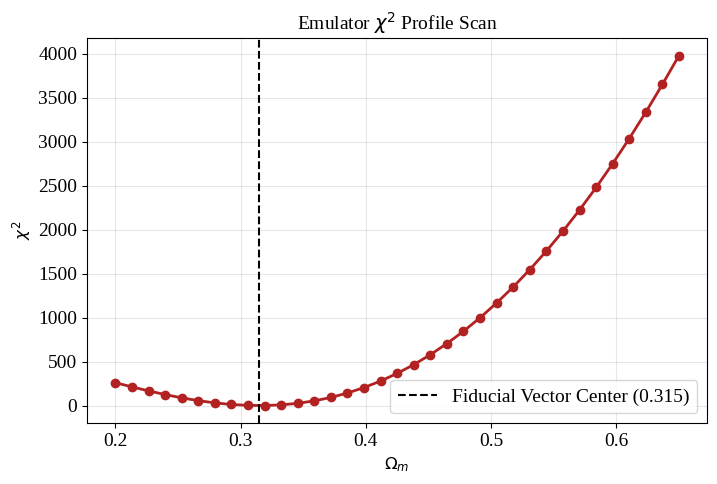

In [8]:
# get chi2 values for omega_m using emulated likelihood

info = "yaml/emulated_bin1_omega_m_likelihood.yaml"
model = get_model(info)
like_object = model.likelihood["functions_and_classes.SO_x_DESI_Likelihood_w_emulator"]

# define omega_m grid
omega_m_grid = np.linspace(0.20, 0.65, 35)
chi2_values = []

# 4. Loop through the grid and evaluate the chi2
print("Starting grid scan...")
for om in omega_m_grid:
    # pass the target parameter along with your fiducial values
    # profile_chi2 function will automatically compute Omega_c = Omega_m - Omega_b inside
    chi2 = like_object.profile_chi2(
        Omega_m=om,
        Omega_b=0.045,
        h=0.674,
        A_s=2.105e-9,
        n_s=0.96,
        w0=-1.0,
        wa=0.0,
        Omega_k=0.0
    )
    chi2_values.append(chi2)

# plot
plt.figure(figsize=(8, 5))
plt.plot(omega_m_grid, chi2_values, marker='o', color='firebrick', lw=2)
plt.axvline(0.315, color='black', linestyle='--', label='Fiducial Vector Center (0.315)')
plt.xlabel(r"$\Omega_m$", fontsize=12)
plt.ylabel(r"$\chi^2$", fontsize=12)
plt.title(r"Emulator $\chi^2$ Profile Scan", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

[model] *WARNING* Ignored blocks/options: ['sampler', 'output']
Initializing SO_x_DESI_Likelihood...
  Loading lens shot noise from: data/DESI_shot_noise_bin1.npy
  Loading source shape noise from: data/DESI_shape_noise_bin1.npy
  Loading CMB noise from: data/SO_CMB_noise.npy
  Loaded lens data from data/DESI_lens_data_bin1.npy
  Loaded source data from: data/HSC_dist_0_3_bin1.npy
  Loading observed data vector from: cobaya_data/emulated_single_bin_data_vector_abridged.npy
  Loading covariance matrix from: cobaya_data/emulated_single_bin_covariance_matrix_abridged.npy
SO_x_DESI_Likelihood initialized successfully.
Starting 2D grid scan...
[jax._src.xla_bridge] Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
--- Debugging Chi2 Evaluation ---
Omega_m evaluated: 0.2600 (Omega_c: 0.2150)
Total Chi2: 12.5961
--- Debugging Chi2 Evaluation ---
Omega_m evaluated: 0.2653 (Omega_c: 0.2203)
Total Chi2: 11

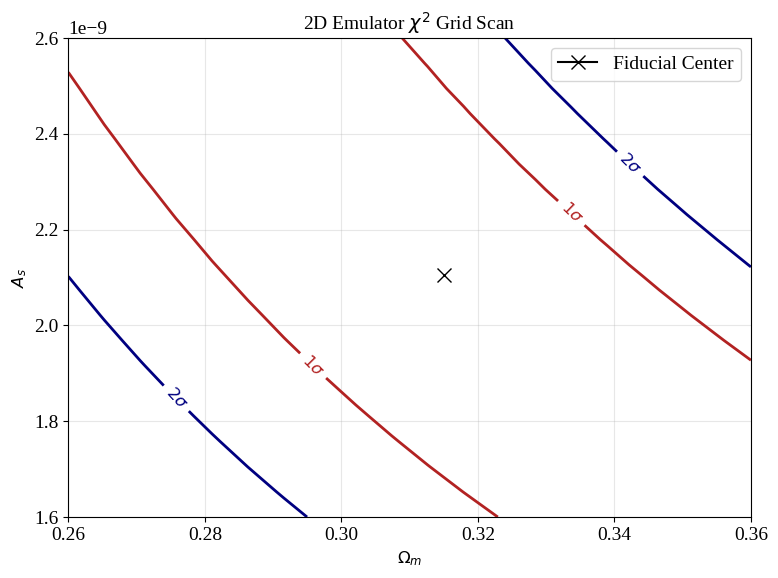

In [13]:
# plot chi2 for emulated abridge likelihood

# 1. Initialize the model and likelihood object
info = "yaml/emulated_abridged_bin1_omega_m_A_s_likelihood.yaml"
model = get_model(info)
like_object = model.likelihood["functions_and_classes.SO_x_DESI_Likelihood_w_emulator"]

# 2. Define grids for BOTH parameters
omega_m_grid = np.linspace(0.26, 0.36, 20)
A_s_grid = np.linspace(1.6e-9, 2.6e-9, 20)

# Create empty matrix to hold chi2 values
chi2_matrix = np.zeros((len(A_s_grid), len(omega_m_grid)))

# Create a counter
step = 0
total_steps = len(A_s_grid) * len(omega_m_grid)

print("Starting 2D grid scan...")
for i, as_val in enumerate(A_s_grid):
    for j, om in enumerate(omega_m_grid):
        step += 1
        if step % 20 == 0:  # Prints an update every 20 points
            print(f"Evaluating step {step}/{total_steps}...")
            
        chi2 = like_object.profile_chi2(
            Omega_m=om,
            Omega_b=0.045,
            h=0.674,
            A_s=as_val,
            n_s=0.96,
            w0=-1.0,
            wa=0.0,
            Omega_k=0.0
        )
        chi2_matrix[i, j] = chi2

# 4. Process the Chi2 surface for plotting
min_chi2 = np.min(chi2_matrix)
delta_chi2 = chi2_matrix - min_chi2  # Delta Chi2 relative to best-fit

# 5. Plot the 2D confidence contours
plt.figure(figsize=(8, 6))

# Standard 2D Gaussian confidence intervals: 1-sigma (Delta Chi2 = 2.30), 2-sigma (Delta Chi2 = 6.18)
contour = plt.contour(omega_m_grid, A_s_grid, delta_chi2, levels=[2.30, 6.18], colors=['firebrick', 'navy'], linewidths=2)
plt.clabel(contour, inline=True, fmt={2.30: r'$1\sigma$', 6.18: r'$2\sigma$'}, fontsize=12)

# Mark the fiducial center
plt.plot(0.315, 2.105e-9, marker='x', color='black', markersize=10, label='Fiducial Center')

plt.xlabel(r"$\Omega_m$", fontsize=12)
plt.ylabel(r"$A_s$", fontsize=12)
plt.title(r"2D Emulator $\chi^2$ Grid Scan", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

[model] *WARNING* Ignored blocks/options: ['sampler', 'output']
Initializing SO_x_DESI_Likelihood...
  Loading lens shot noise from: data/DESI_shot_noise_bin1.npy
  Loading source shape noise from: data/DESI_shape_noise_bin1.npy
  Loading CMB noise from: data/SO_CMB_noise.npy
  Loaded lens data from data/DESI_lens_data_bin1.npy
  Loaded source data from: data/HSC_dist_0_3_bin1.npy
  Loading observed data vector from: cobaya_data/emulated_single_bin_data_vector.npy
[jax._src.xla_bridge] Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
[jax._src.xla_bridge] *WARNING* An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
  Loading covariance matrix from: cobaya_data/emulated_single_bin_covariance_matrix.npy
SO_x_DESI_Likelihood initialized successfully.
Starting grid scan...
--- Debugging Chi2 Evaluation ---
Omega_m evaluated: 0.2000 (Omega_c

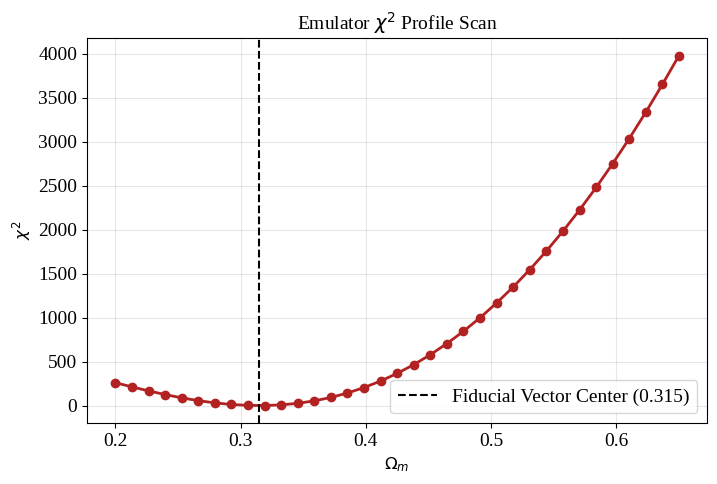

In [14]:
# get chi2 values for omega_m using emulated likelihood

info = "yaml/emulated_bin1_omega_m_likelihood_w_JAX.yaml"
model = get_model(info)
like_object = model.likelihood["functions_and_classes.SO_x_DESI_Likelihood_w_emulator_and_JAX"]

# define omega_m grid
omega_m_grid = np.linspace(0.20, 0.65, 35)
chi2_values = []

# 4. Loop through the grid and evaluate the chi2
print("Starting grid scan...")
for om in omega_m_grid:
    # pass the target parameter along with your fiducial values
    # profile_chi2 function will automatically compute Omega_c = Omega_m - Omega_b inside
    chi2 = like_object.profile_chi2(
        Omega_m=om,
        Omega_b=0.045,
        h=0.674,
        A_s=2.105e-9,
        n_s=0.96,
        w0=-1.0,
        wa=0.0,
        Omega_k=0.0
    )
    chi2_values.append(chi2)

# plot
plt.figure(figsize=(8, 5))
plt.plot(omega_m_grid, chi2_values, marker='o', color='firebrick', lw=2)
plt.axvline(0.315, color='black', linestyle='--', label='Fiducial Vector Center (0.315)')
plt.xlabel(r"$\Omega_m$", fontsize=12)
plt.ylabel(r"$\chi^2$", fontsize=12)
plt.title(r"Emulator $\chi^2$ Profile Scan", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
# Recreation of Pratt Results
# reference: https://arxiv.org/pdf/1810.02212
# sigma_epsilone = 0.26
# For the purposes of these forecasts, we adopt the best-fit ΛCDM cosmological 
# model from the analysis ofTT,TE,EE+lowP+lensing+ext datasets in Ade et al. (2016).

# We do LSST + CMB-S4 since that's one of two that is graphed, and I didn't want to deal with separate populations of lens bins

# Source Bins: We assume that LSST is used to measure shapes of source galaxies,
# with a source density of 25 galaxies per sq. arcmin and redshift range from z = 1.0 to z = 1.6.
# Lens Bins:  We assume that the LSST tracer galaxy sample is divided into 10 bins 
# between z = 0.2 and z = 0.7, with number density of 100 galaxies per square degree for each bin.
# CMB Lensing: The CMB lensing map is assumed to come from a Stage 4 (CMB-S4) like experiment
# we adopt the minimum variance CMB lensing noise curve from Schaan et al.
# multiplicative shear bias from LSST can be calibrated to σ(m) = 0.001

# Prior: geometrical Planck prior, curved LCDM, sample over omega_k, omega_m, w
#  marginalize over h and Ωb as these appear in the geometrical Planck prior

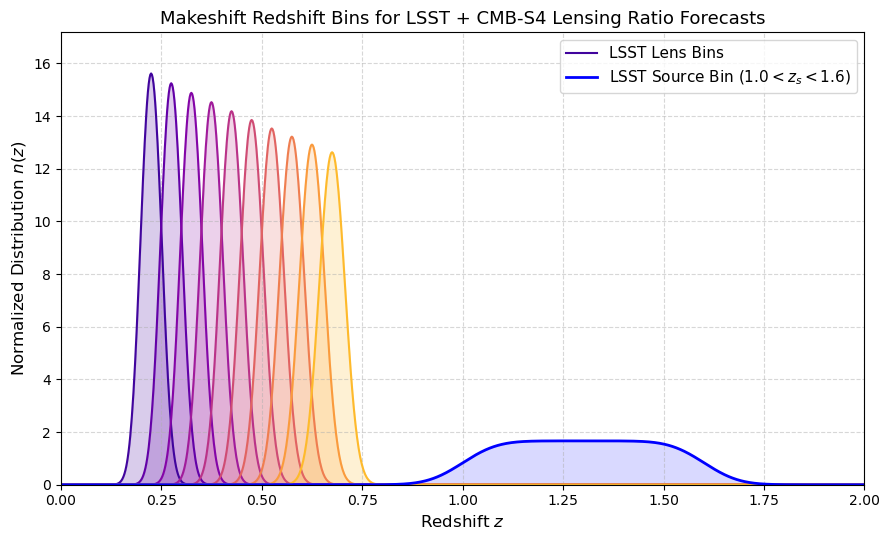

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# create lens and source bins to be used for Pratt check
# LSST + CMB-S4

# define redshift grid
z = np.linspace(0.0, 2.0, 1000)
dz = z[1] - z[0]

# build the 10 photometric lens bins (0.2 < z < 0.7) with equal number of galaxies
lens_edges = np.linspace(0.2, 0.7, 11)
lens_bins = []

# assume a redMaGiC-like photo-z scatter profile: \sigma_z = 0.0166 * (1 + z)
# "Such densities are comparable to what is currently achieved with DES redMaGiC"
# "the DES Y1 redMaGiC photo-zs have a scatter of σz = 0.0166(1 + z)"
for i in range(10):
    z_min, z_max = lens_edges[i], lens_edges[i+1]
    z_mid = (z_min + z_max) / 2.0
    
    # initialize nominal window
    top_hat = np.zeros_like(z)
    top_hat[(z >= z_min) & (z <= z_max)] = 1.0
    
    # Calculate pixel-level Gaussian smoothing representing photo-z scatter
    sigma = 0.0166 * (1 + z_mid)
    sigma_pix = sigma / dz
    
    # Convolve to get the realistic underlying true n(z) distribution
    nz_lens = gaussian_filter1d(top_hat, sigma_pix)
    
    # Normalize the distribution
    if np.sum(nz_lens) > 0:
        nz_lens /= np.sum(nz_lens) * dz
    lens_bins.append(nz_lens)

# build the single source bin (1.0 < z < 1.6)
source_min, source_max = 1.0, 1.6
source_mid = (source_min + source_max) / 2.0

top_hat_source = np.zeros_like(z)
top_hat_source[(z >= source_min) & (z <= source_max)] = 1.0

# LSST expected source sample photo-z scatter seems to be ~ \sigma_z = 0.03 * (1 + z)
# https://arxiv.org/pdf/2510.07370
sigma_src = 0.03 * (1 + source_mid)
sigma_src_pix = sigma_src / dz
nz_source = gaussian_filter1d(top_hat_source, sigma_src_pix)
nz_source /= np.sum(nz_source) * dz

# make into arrays
Pratt_lens_data = np.column_stack([z] + lens_bins)
Pratt_source_data = np.column_stack((z, nz_source))

# plot
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = plt.cm.plasma(np.linspace(0.1, 0.85, 10))
z_plot = Pratt_lens_data[:, 0]

for i in range(10):
    nz_plot = Pratt_lens_data[:, i + 1]
    lbl = 'LSST Lens Bins' if i == 0 else ""
    ax.plot(z_plot, nz_plot, color=colors[i], lw=1.5, label=lbl)
    ax.fill_between(z_plot, nz_plot, color=colors[i], alpha=0.2)

ax.plot(Pratt_source_data[:, 0], Pratt_source_data[:, 1], color='blue', lw=2, label='LSST Source Bin ($1.0 < z_s < 1.6$)')
ax.fill_between(Pratt_source_data[:, 0], Pratt_source_data[:, 1], color='blue', alpha=0.15)

ax.set_xlabel('Redshift $z$', fontsize=12)
ax.set_ylabel('Normalized Distribution $n(z)$', fontsize=12)
ax.set_title('Makeshift Redshift Bins for LSST + CMB-S4 Lensing Ratio Forecasts', fontsize=13)
ax.set_xlim(0.0, 2.0)
ax.set_ylim(0.0, max(np.max(lens_bins) * 1.1, np.max(nz_source) * 1.1))
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig('lsst_cmbs4_bins.png', dpi=300)
plt.show()

In [ ]:
# noise

Pratt_shot_noise = 
Pratt_shape_noise = 
Pratt_CMB_noise = 

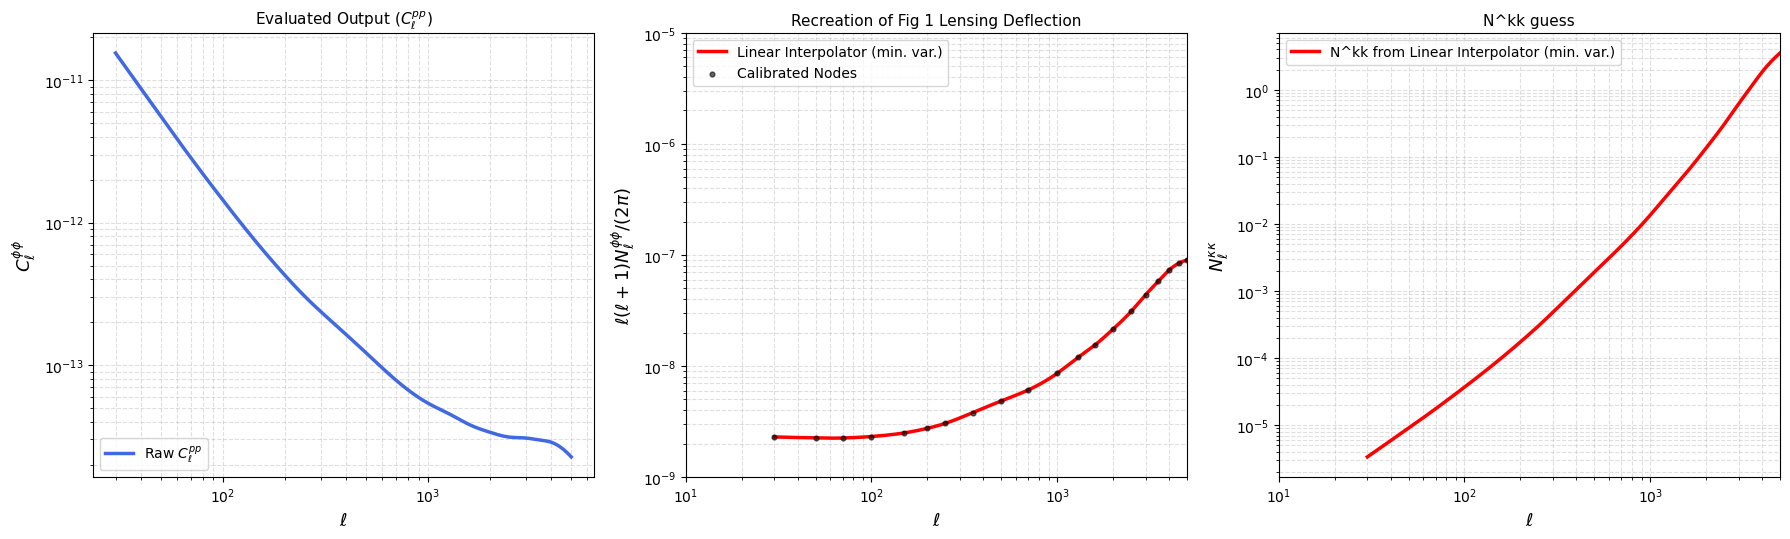

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import CubicSpline, interp1d

# 1. High-precision nodes capturing the flat start, the mid-range bump, and the steep end
ell_nodes = np.array([
    30, 50, 70, 100, 150, 200, 250, 350, 500, 700, 1000, 
    1300, 1600, 2000, 2500, 3000, 3500, 4000, 4500, 5000
])
scaled_nodes = np.array([
    2.30e-9,  # l=30 (start)
    2.25e-9,  # Shallow dip
    2.25e-9,  
    2.32e-9,  # l=100
    2.50e-9,  # Gradual rise starts
    2.75e-9,  # l=200
    3.05e-9,  # Entering the shoulder/bump region
    3.80e-9,  
    4.85e-9,  # Slows down slightly right before l=500
    6.10e-9,  # l=700
    8.60e-9,  # l=1000 (Passes just under the 10^-8 line)
    1.20e-8,  
    1.55e-8,  
    2.15e-8,  # Undergoes the steep upward turn past l=2000
    3.10e-8,  
    4.40e-8,  # l=3000
    5.80e-8,  
    7.30e-8,  
    8.40e-8,  
    9.00e-8   # Terminates under the 10^-7 line at l=5000
])

# 2. Generate a dense baseline path
# This populates intermediate steps to ensure raw linear interpolation behaves smoothly in logspace
cs_helper = CubicSpline(np.log10(ell_nodes), np.log10(scaled_nodes))
ell_base = np.logspace(np.log10(30), np.log10(5000), 500)
scaled_base = 10**cs_helper(np.log10(ell_base))

# De-scale the baseline values back to raw Cl^pp parameters:
# Cl^pp = (scaled_value * 2pi) / (l*(l+1))
cl_pp_base = scaled_base * (2 * np.pi) / (ell_base * (ell_base + 1))

# 3. Instantiate the pure LINEAR interpolator for raw Cl^pp coordinates
cl_pp_linear_interpolator = interp1d(ell_base, cl_pp_base, kind='linear', fill_value='extrapolate')

# 4. Define the target evaluation array (representing the input array)
ell_array = np.logspace(np.log10(30), np.log10(5000), 1000)

# 5. Apply the linear interpolator to the evaluation array
cl_pp_evaluated = cl_pp_linear_interpolator(ell_array)

# Re-scale back for plotting coordinates: l(l+1)C_l^pp / 2pi
scaled_evaluated = ell_array * (ell_array + 1) * cl_pp_evaluated / (2 * np.pi)

n_kk_evaluated = (np.pi / 2) * ell_array * (ell_array + 1) * scaled_evaluated

# =====================================================================
# 6. Plotting Execution (Rendered via Logarithmic Scale Geometry)
# =====================================================================
# Expanded subplot grid to 1 row, 3 columns to cleanly fit the new curve
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.5))

# Left Panel: Pure Evaluated Raw Cl^pp
ax1.plot(ell_array, cl_pp_evaluated, color='royalblue', lw=2.5, label=r'Raw $C_\ell^{pp}$')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel(r'$\ell$', fontsize=13)
ax1.set_ylabel(r'$C_\ell^{\phi\phi}$', fontsize=13)
ax1.set_title(r'Evaluated Output ($C_\ell^{pp}$)', fontsize=11)
ax1.grid(True, which='both', linestyle='--', alpha=0.4)
ax1.legend(loc='lower left')

# Middle Panel: Exact Mirror of Figure 1 Coordinates from arXiv:1607.01761
ax2.plot(ell_array, scaled_evaluated, color='red', lw=2.5, label='Linear Interpolator (min. var.)')
ax2.scatter(ell_nodes, scaled_nodes, color='black', s=12, zorder=3, alpha=0.6, label='Calibrated Nodes')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim(10, 5000)
ax2.set_ylim(1e-9, 1e-5)
ax2.set_xlabel(r'$\ell$', fontsize=13)
ax2.set_ylabel(r'$\ell(\ell + 1) N_\ell^{\phi\phi} / (2\pi)$', fontsize=13)
ax2.set_title('Recreation of Fig 1 Lensing Deflection', fontsize=11)
ax2.grid(True, which='both', linestyle='--', alpha=0.4)
ax2.legend(loc='upper left')

# Right Panel: N^kk_l
ax3.plot(ell_array, n_kk_evaluated, color='red', lw=2.5, label='N^kk from Linear Interpolator (min. var.)')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_xlim(10, 5000)
ax3.set_xlabel(r'$\ell$', fontsize=13)
ax3.set_ylabel(r'$N_\ell^{\kappa\kappa}$', fontsize=13)
ax3.set_title('N^kk guess', fontsize=11)
ax3.grid(True, which='both', linestyle='--', alpha=0.4)
ax3.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# how do I get from this to N^kk_l?
# what is the shot and shape noise?
# what are the priors?

In [ ]:
# calculate and save fiducial data vector and covariance matrix for Pratt LSST + CMB-S4

# ensure output directory exists
os.makedirs('cobaya_data', exist_ok=True)

print("Calculating fiducial data vector and covariance matrix for Pratt LSST + CMB-S4 reconstruction")

# cosmology params
omega_b_h2 = 0.02230 +- 0.00014
omega_c_h2 = 0.1188 +- 0.0010
ln_10_10_A_s = 3.064 +- 0.023
n_s = 0.9667 +- 0.0040
h = 0.6774 +- 0.0046
omega_m = 0.3089 +- 0.0062

# I'll use the main value of all of these and ignore the error bars
fiducial_cosmology = ccl.Cosmology(
    Omega_c=XXXX,
    Omega_b=XXXX,
    h=XXXX,
    A_s=XXXX,
    n_s=XXXX,
    w0=XXXX,
    wa=XXXX,
    Omega_k=XXXX,
    transfer_function='boltzmann_camb'
)

# extract other parameters directly, or hardcode them if they are constant for this generation step
f_sky = 0.44 # this is taken from the paper they reference -- not sure if its the value they use
n_ell = 3000 # they cut off under 30 also
binsize = 50 # might increase this to speed up analysis if it takes too long
magnification_bias_lenses = None # not given...
desired_spectra = ['GL', 'CG']

# build covariance and spectra dictionary
cov_obj, fiducial_spectra_dict, f_map = \
    build_covariance_from_data(
        fiducial_cosmology,
        Pratt_lens_data,
        Pratt_source_data,
        f_sky=f_sky,
        n_ell=n_ell,
        binsize=binsize,
        shot_noise_lens=Pratt_shot_noise,
        shape_noise_source=Pratt_shape_noise,
        cmb_noise_phi=Pratt_CMB_noise, 
        magnification_bias_lenses=magnification_bias_lenses,
        desired_spectra=desired_spectra,
        linear_emulator=lin_emu,
        boost_emulator=boost_emu
    )

# extract and flatten the fiducial data vector
observed_data_vector = np.array([])
num_binned_ells = int(np.ceil(n_ell / binsize))

for pair in f_map.pairs:
    unbinned_cls = fiducial_spectra_dict[pair]
    binned_cls_for_pair = []
    for i in range(0, n_ell, binsize):
        end_idx = min(i + binsize, len(unbinned_cls))
        if i < end_idx:
            binned_cls_for_pair.append(np.mean(unbinned_cls[i:end_idx]))
        else:
            binned_cls_for_pair.append(0.0)
    while len(binned_cls_for_pair) < num_binned_ells:
        binned_cls_for_pair.append(0.0)
    observed_data_vector = np.concatenate((observed_data_vector, binned_cls_for_pair))

# get the covariance matrix
covariance_matrix = cov_obj.matrix

# Save to files
data_vector_filename = 'cobaya_data/Pratt_LSST_CMB_S4_data_vector.npy'
covariance_filename = 'cobaya_data/Pratt_LSST_CMB_S4_covariance_matrix.npy'

np.save(data_vector_filename, observed_data_vector)
np.save(covariance_filename, covariance_matrix)

print(f"Fiducial data vector saved to: {data_vector_filename}")
print(f"Covariance matrix saved to: {covariance_filename}")

#plot_covariance_matrix(cov_obj, fiducial_spectra_dict, f_map, binsize=50, desired_spectra=['CG', 'GL'])
#plot_correlation_matrix(cov_obj, fiducial_spectra_dict, f_map, binsize=50, desired_spectra=['CG', 'GL'])

In [ ]:
# chi2 analysis -- quick comparison w/Pratt

info = "yaml/Pratt_LSST_CMB_S4_likelihood.yaml"
model = get_model(info)
like_object = model.likelihood["functions_and_classes.SO_x_DESI_Likelihood_w_emulator"]

# 2. Define grids for BOTH parameters
Omega_m_grid = np.linspace()
Omega_k_grid = np.linspace()
w_grid = np.linspace()

# Create empty matrix to hold chi2 values
chi2_matrix = np.zeros((len(Omega_m_grid), len(Omega_k_grid), len(w_grid)))

# create a counter
step = 0
total_steps = len(Omega_m_grid) * len(Omega_k_grid) * len(w_grid)

print("Starting 3D grid scan...")
for i, om in enumerate(Omega_m_grid):
    for j, ok in enumerate(Omega_k_grid):
        for k, w in enumerate(w_grid): 
            step += 1
            if step % 20 == 0:  # Prints an update every 20 points
                print(f"Evaluating step {step}/{total_steps}...")
                
            chi2 = like_object.profile_chi2(
                Omega_m=om,
                Omega_b=XXXX,
                h=XXXX,
                A_s=XXXX,
                n_s=XXXX,
                w0=XXXX,
                wa=XXXXX,
                Omega_k=ok
            )
            chi2_matrix[i, j, k] = chi2

# process the chi2 surface for plotting
min_chi2 = np.min(chi2_matrix)
delta_chi2 = chi2_matrix - min_chi2  # Delta Chi2 relative to best-fit

#### MODIFY
# 5. Plot the 2D confidence contours
plt.figure(figsize=(8, 6))

# Standard 2D Gaussian confidence intervals: 1-sigma (Delta Chi2 = 2.30), 2-sigma (Delta Chi2 = 6.18)
contour = plt.contour(omega_m_grid, A_s_grid, delta_chi2, levels=[2.30, 6.18], colors=['firebrick', 'navy'], linewidths=2)
plt.clabel(contour, inline=True, fmt={2.30: r'$1\sigma$', 6.18: r'$2\sigma$'}, fontsize=12)

# Mark the fiducial center
plt.plot(0.315, 2.105e-9, marker='x', color='black', markersize=10, label='Fiducial Center')

plt.xlabel(r"$\Omega_m$", fontsize=12)
plt.ylabel(r"$A_s$", fontsize=12)
plt.title(r"2D Emulator $\chi^2$ Grid Scan", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()